# Bitcoin Transaction Fee Estimation Pipeline

## Overview
This notebook implements the two-stage estimation pipeline for Bitcoin transaction fees, following the methodology in Section 5 of the paper "A Model and Estimation of the Bitcoin Transaction Fee."

**Goal**: Estimate the decomposition in Equation (5):
```
log(fee) = log(c_it) + log(W'(p_it, s_t)) + log(Weight) + const + ε
            ↑              ↑
        preferences    delay technology
```

## Pipeline Architecture
1. **Stage 1**: Delay Technology Estimation (Random Forest with monotonicity enforcement)
   - Cross-fitting via GroupKFold by epoch
   - Isotonic regression to enforce monotonicity in priority
   - Finite difference local slope computation

2. **Stage 2**: Hurdle Fee Model
   - **Extensive margin**: Logistic regression for P(fee > ε)
   - **Intensive margin**: Ridge regression on log-fee among fee-payers
   - Smearing correction for level predictions

**Key principle**: Priority → delay gradient → fee via impatience (VCG-consistent)

In [1]:
# =============================================================================
# Section 1: Imports and Configuration
# =============================================================================
import os
import gc
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
from dataclasses import dataclass, field
from typing import Optional, List, Tuple, Dict, Any
from scipy import stats
from scipy.interpolate import interp1d, BSpline
from scipy.optimize import minimize, lsq_linear

# Sklearn imports
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge, LinearRegression
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import SplineTransformer
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("Libraries imported successfully")
print(f"Pandas: {pd.__version__}, NumPy: {np.__version__}")

Libraries imported successfully
Pandas: 2.3.3, NumPy: 2.4.0


In [2]:
# =============================================================================
# Section 1.2: Configuration Dataclass
# =============================================================================
@dataclass
class EstimationConfig:
    """Configuration for the two-stage fee estimation pipeline."""
    
    # Database settings
    db_path: str = '/home/armin/datalake/data-samples/11-24-2025-15m-data-lake.db'
    annotation_path: str = '/home/armin/datalake/data-samples/tx-annotations-15m-2-7-2026.pkl'
    block_limit: Optional[int] = 100  # None
    
    # Epoch parameters
    # epoch_mode: 'block', 'fixed_size', or 'time' (recommended for delay estimation)
    # Time-based epochs allow priority to predict delay (txs compete across multiple blocks)
    epoch_mode: str = 'time'  # Time-based is needed for priority→delay relationship
    blocks_per_epoch: int = 2  # Blocks per epoch (for epoch_mode='block')
    target_epoch_size: int = 1000  # Txs per epoch (for epoch_mode='fixed_size')
    epoch_duration_minutes: int = 30  # Minutes per epoch (for epoch_mode='time') - ~3 blocks
    
    # Stage 1 parameters (Delay Technology)
    n_folds: int = 5  # Cross-validation folds for cross-fitting
    rf_n_estimators: int = 200  # Trees in Random Forest
    rf_max_depth: int = 15  # Max tree depth
    rf_min_samples_leaf: int = 20  # Minimum samples per leaf
    
    # Slope computation parameters
    slope_delta: float = 0.55  # Δ for finite difference (Eq. 11)
    slope_trim: float = 0.05  # Boundary trimming for percentiles
    p_grid_size: int = 51  # Number of grid points for monotonization
    
    # Stage 2 parameters (Hurdle Model)
    fee_threshold_sat_vb: float = 0.1  # ε threshold for hurdle model (sat/vB)
    
    # Impatience proxy parameters (kept for exploratory analysis)
    respend_truncation_blocks: int = 14  # Max blocks for impatience calc (~1 day)
    epsilon: float = 1e-6  # Small constant for numerical stability
    
    # Max block weight (Bitcoin consensus)
    max_block_weight: int = 4_000_000
    
# Create default configuration
config = EstimationConfig()

print("Configuration created:")
print(f"  Database: {config.db_path}")
print(f"  Block limit: {config.block_limit}")
print(f"  Epoch mode: {config.epoch_mode}", end="")
if config.epoch_mode == 'block':
    print(f" ({config.blocks_per_epoch} block(s) per epoch)")
elif config.epoch_mode == 'fixed_size':
    print(f" (~{config.target_epoch_size} txs each)")
else:
    print(f" ({config.epoch_duration_minutes} min each)")
print(f"  Cross-fitting folds: {config.n_folds}")
print(f"  Finite difference delta: {config.slope_delta}")
print(f"  Fee threshold: {config.fee_threshold_sat_vb} sat/vB")

Configuration created:
  Database: /home/armin/datalake/data-samples/11-24-2025-15m-data-lake.db
  Block limit: 100
  Epoch mode: time (30 min each)
  Cross-fitting folds: 5
  Finite difference delta: 0.55
  Fee threshold: 0.1 sat/vB


---
## Section 2: Data Loading

In [3]:
# =============================================================================
# Section 2.1: Data Loading Functions (with corrected weights from mempool.space)
# =============================================================================

# Path to mempool.space corrected weight data
MEMPOOL_SPACE_DB = '/home/kristian/notebooks/mempool_space_data.db'


def get_valid_blocks_from_mempool_space() -> List[str]:
    """Get list of block hashes that have corrected weight data."""
    conn = sqlite3.connect(MEMPOOL_SPACE_DB)
    blocks = pd.read_sql_query(
        "SELECT DISTINCT block_hash FROM transactions", conn
    )['block_hash'].tolist()
    conn.close()
    return blocks


def load_corrected_weights() -> pd.DataFrame:
    """Load corrected weight/size/fee data from mempool.space database."""
    conn = sqlite3.connect(MEMPOOL_SPACE_DB)
    df = pd.read_sql_query("""
        SELECT 
            txid,
            weight as weight_corrected,
            size as size_corrected,
            vsize as vsize_corrected,
            fee as fee_corrected,
            fee_rate as fee_rate_corrected
        FROM transactions
    """, conn)
    conn.close()
    return df


def load_data_from_sqlite(db_path: str, block_limit: Optional[int] = None) -> pd.DataFrame:
    """
    Load transaction data from SQLite database.
    Only loads blocks that have corrected weight data from mempool.space.
    Merges corrected weight/size/fee values.
    
    Args:
        db_path: Path to SQLite database
        block_limit: Number of blocks to sample (None for all available)
        
    Returns:
        DataFrame with transaction data including corrected weights
    """
    print("=" * 60)
    print("Loading data from SQLite (with corrected weights)")
    print("=" * 60)
    
    # Get blocks that have corrected weight data
    valid_blocks = get_valid_blocks_from_mempool_space()
    print(f"Blocks with corrected weight data: {len(valid_blocks)}")
    
    conn = sqlite3.connect(db_path)
    
    # Get total count
    total_count = pd.read_sql_query(
        "SELECT COUNT(*) as count FROM mempool_transactions", conn
    )['count'].iloc[0]
    print(f"Total transactions in source database: {total_count:,}")
    
    # Filter to only valid blocks, with optional temporal balancing
    if block_limit and block_limit < len(valid_blocks):
        print(f"\nSampling {block_limit} blocks from {len(valid_blocks)} available...")
        
        # Get hour bins for temporal balancing
        placeholders = ','.join(['?' for _ in valid_blocks])
        all_blocks_query = f"""
            SELECT DISTINCT 
                conf_block_hash,
                strftime('%Y-%m-%d %H', mined_at) as hour_bin
            FROM mempool_transactions
            WHERE conf_block_hash IN ({placeholders})
              AND mined_at IS NOT NULL
        """
        all_blocks_df = pd.read_sql_query(all_blocks_query, conn, params=valid_blocks)
        print(f"Found {len(all_blocks_df):,} blocks with timestamps")
        
        # Temporally balanced sampling
        all_blocks_df = all_blocks_df.sample(frac=1, random_state=42)
        all_blocks_df['rank_in_hour'] = all_blocks_df.groupby('hour_bin').cumcount()
        
        n_hours = all_blocks_df['hour_bin'].nunique()
        blocks_per_hour = max(1, block_limit // n_hours)
        
        sampled_df = all_blocks_df[all_blocks_df['rank_in_hour'] < blocks_per_hour]
        
        if len(sampled_df) < block_limit:
            remaining = all_blocks_df[all_blocks_df['rank_in_hour'] >= blocks_per_hour]
            sampled_df = pd.concat([sampled_df, remaining.head(block_limit - len(sampled_df))])
        
        sampled_blocks = sampled_df['conf_block_hash'].head(block_limit).tolist()
        print(f"Sampled {len(sampled_blocks)} blocks with temporal balancing")
    else:
        sampled_blocks = valid_blocks
        print(f"Using all {len(sampled_blocks)} available blocks")
    
    # Load transactions from sampled blocks
    placeholders = ','.join(['?' for _ in sampled_blocks])
    query = f"""
        SELECT 
            tx_id,
            conf_block_hash,
            found_at,
            mined_at,
            fee_rate as fee_rate_original,
            waittime,
            weight as weight_original,
            size as size_original,
            min_respend_blocks,
            child_txid,
            rbf_fee_total,
            mempool_tx_count,
            mempool_size,
            total_output_amount,
            absolute_fee as absolute_fee_original
        FROM mempool_transactions 
        WHERE conf_block_hash IN ({placeholders})
    """
    
    print("Loading transactions from source database...")
    df = pd.read_sql_query(query, conn, params=sampled_blocks)
    conn.close()
    
    print(f"Loaded {len(df):,} transactions from source")
    
    # Load and merge corrected weights
    print("\nMerging corrected weight data from mempool.space...")
    corrected_df = load_corrected_weights()
    print(f"Corrected weight data available for {len(corrected_df):,} transactions")
    
    # Merge corrected data
    df = df.merge(
        corrected_df,
        left_on='tx_id',
        right_on='txid',
        how='left'
    )
    
    # Use corrected values where available, fall back to original
    df['weight'] = df['weight_corrected'].fillna(df['weight_original'])
    df['size'] = df['size_corrected'].fillna(df['size_original'])
    df['fee_rate'] = df['fee_rate_corrected'].fillna(df['fee_rate_original'])
    df['absolute_fee'] = df['fee_corrected'].fillna(df['absolute_fee_original'])
    
    # Compute vsize from weight (vsize = weight / 4, this is how fee_rate is calculated)
    # Use corrected vsize where available, otherwise compute from weight
    df['vsize'] = df['vsize_corrected'].fillna(df['weight'] / 4)
    
    # Track which rows have corrected data
    df['has_corrected_weight'] = df['weight_corrected'].notna()
    
    # Clean up merge columns
    df = df.drop(columns=['txid', 'weight_corrected', 'size_corrected', 
                          'vsize_corrected', 'fee_corrected', 'fee_rate_corrected'])
    
    # Summary
    corrected_count = df['has_corrected_weight'].sum()
    print(f"\n✓ Loaded {len(df):,} transactions")
    print(f"  - With corrected weights: {corrected_count:,} ({100*corrected_count/len(df):.1f}%)")
    print(f"  - Using original weights: {len(df) - corrected_count:,}")
    print(f"Columns: {list(df.columns)}")
    
    return df


def load_and_merge_annotations(df: pd.DataFrame, annotation_path: str) -> pd.DataFrame:
    """
    Load transaction annotations and merge with main DataFrame.
    
    Annotations provide structural labels (normal, consolidation, coinjoin, 
    datacarrying), tag flags (op_return, inscription), and input/output counts.
    These serve as controls for transaction type and improved impatience proxies.
    
    Args:
        df: Transaction DataFrame with tx_id column
        annotation_path: Path to annotations pickle file
        
    Returns:
        DataFrame with annotation columns merged in
    """
    print("\n" + "=" * 60)
    print("Loading Transaction Annotations")
    print("=" * 60)
    
    annot = pd.read_pickle(annotation_path)
    print(f"Loaded {len(annot):,} annotations")
    
    # Filter out error annotations
    n_errors = (annot['label'] == 'error').sum()
    if n_errors > 0:
        annot = annot[annot['label'] != 'error'].copy()
        print(f"  Removed {n_errors:,} error annotations")
    
    # Extract tag flags from tags list
    annot['has_op_return'] = annot['tags'].apply(lambda t: int('op_return' in t))
    annot['has_inscription'] = annot['tags'].apply(lambda t: int('inscription' in t))
    
    # Select columns to merge
    annot_cols = ['tx_id', 'label', 'n_in', 'n_out', 'has_op_return', 'has_inscription']
    annot_merge = annot[annot_cols].copy()
    
    # Merge with main DataFrame
    n_before = len(df)
    df = df.merge(annot_merge, on='tx_id', how='left')
    
    # Report merge coverage
    n_matched = df['label'].notna().sum()
    print(f"\n✓ Annotations merged")
    print(f"  Matched: {n_matched:,} / {n_before:,} ({100*n_matched/n_before:.1f}%)")
    
    # Fill missing annotations with defaults
    df['label'] = df['label'].fillna('unknown')
    df['n_in'] = df['n_in'].fillna(1).astype(int)
    df['n_out'] = df['n_out'].fillna(2).astype(int)
    df['has_op_return'] = df['has_op_return'].fillna(0).astype(int)
    df['has_inscription'] = df['has_inscription'].fillna(0).astype(int)
    
    # Label distribution
    print(f"\n  Label distribution:")
    for lbl, cnt in df['label'].value_counts().items():
        print(f"    {lbl}: {cnt:,} ({100*cnt/len(df):.1f}%)")
    
    return df


def check_data_quality(df: pd.DataFrame) -> pd.DataFrame:
    """
    Check data quality and perform basic cleaning.
    
    Args:
        df: Raw transaction DataFrame
        
    Returns:
        Cleaned DataFrame
    """
    print("\n" + "=" * 60)
    print("Data Quality Check")
    print("=" * 60)
    
    # Check missing values
    print("\nMissing Values Summary:")
    missing = df.isnull().sum()
    print(missing[missing > 0])
    
    # Weight correction summary
    if 'has_corrected_weight' in df.columns:
        print("\n--- Weight Correction Summary ---")
        corrected = df['has_corrected_weight'].sum()
        print(f"Transactions with corrected weights: {corrected:,} ({100*corrected/len(df):.1f}%)")
        
        if 'weight_original' in df.columns:
            # Compare original vs corrected for those with corrections
            corrected_df = df[df['has_corrected_weight']].copy()
            if len(corrected_df) > 0:
                weight_diff = corrected_df['weight'] - corrected_df['weight_original']
                print(f"Mean weight correction: +{weight_diff.mean():.1f} WU ({100*weight_diff.mean()/corrected_df['weight_original'].mean():.1f}%)")
    
    # Basic statistics
    print(f"\nBasic Statistics (using corrected weights):")
    print(df[['fee_rate', 'waittime', 'weight', 'mempool_tx_count']].describe())
    
    # Remove rows with missing critical values
    critical_cols = ['fee_rate', 'waittime', 'weight', 'mempool_tx_count']
    df_clean = df.dropna(subset=critical_cols).copy()
    
    print(f"\n✓ Clean dataset: {len(df_clean):,} transactions ({len(df_clean)/len(df)*100:.1f}% retained)")
    
    return df_clean

def load_block_state_features() -> pd.DataFrame:
    """Load per-block state features from mempool_space_data.db.
    
    These features are computed by scripts/compute_block_state_features.py
    and include fee-rate percentiles, block weight, inter-block timing,
    and EMA features.
    
    Returns:
        DataFrame indexed by block_hash, or empty DataFrame if table missing.
    """
    conn = sqlite3.connect(MEMPOOL_SPACE_DB)
    
    # Check if table exists
    tables = [r[0] for r in conn.execute(
        "SELECT name FROM sqlite_master WHERE type='table'"
    ).fetchall()]
    
    if 'block_state_features' not in tables:
        print("WARNING: block_state_features table not found in mempool_space_data.db")
        print("  Run: python scripts/compute_block_state_features.py")
        conn.close()
        return pd.DataFrame()
    
    df = pd.read_sql_query("SELECT * FROM block_state_features", conn)
    conn.close()
    
    print(f"Loaded block state features for {len(df):,} blocks")
    return df


In [4]:
# =============================================================================
# Section 2.2: Load Data
# =============================================================================
# Load data from database
df_raw = load_data_from_sqlite(config.db_path, config.block_limit)

# Merge transaction annotations (labels, structural features, tag flags)
df_raw = load_and_merge_annotations(df_raw, config.annotation_path)

# Merge block-level state features (from scripts/compute_block_state_features.py)
block_features = load_block_state_features()
if len(block_features) > 0:
    n_before = len(df_raw)
    df_raw = df_raw.merge(
        block_features,
        left_on='conf_block_hash',
        right_on='block_hash',
        how='left'
    )
    # Drop duplicate block_hash column (we keep conf_block_hash)
    if 'block_hash' in df_raw.columns:
        df_raw = df_raw.drop(columns=['block_hash'])
    matched = df_raw['block_median_feerate'].notna().sum()
    print(f"Block state features merged: {matched:,} / {n_before:,} matched")
else:
    print("Skipping block state features (not available)")

# Check data quality and clean
df = check_data_quality(df_raw)

# Free memory
del df_raw
gc.collect()

print(f"\nDataset ready with {len(df):,} transactions")


Loading data from SQLite (with corrected weights)
Blocks with corrected weight data: 5965
Total transactions in source database: 14,984,540

Sampling 100 blocks from 5965 available...
Found 5,988 blocks with timestamps
Sampled 100 blocks with temporal balancing
Loading transactions from source database...
Loaded 252,680 transactions from source

Merging corrected weight data from mempool.space...
Corrected weight data available for 19,065,494 transactions

✓ Loaded 252,680 transactions
  - With corrected weights: 252,680 (100.0%)
  - Using original weights: 0
Columns: ['tx_id', 'conf_block_hash', 'found_at', 'mined_at', 'fee_rate_original', 'waittime', 'weight_original', 'size_original', 'min_respend_blocks', 'child_txid', 'rbf_fee_total', 'mempool_tx_count', 'mempool_size', 'total_output_amount', 'absolute_fee_original', 'weight', 'size', 'fee_rate', 'absolute_fee', 'vsize', 'has_corrected_weight']

Loading Transaction Annotations
Loaded 14,984,540 annotations
  Removed 2 error annota

---
## Section 2.3: CPFP Package Collapsing

**Key insight**: Miners evaluate CPFP packages as a unit, not individual transactions. When a parent has 0 sat/vB and its child has 20 sat/vB, miners compute the combined (package) fee rate as:

```
package_fee_rate = (parent_fee + child_fee) / (parent_vsize + child_vsize)
```

We use `absolute_fee` and `size` (=vsize) columns for accurate calculation matching miner behavior.

This section:
1. Identifies CPFP parent-child pairs (parent has `child_txid`)
2. Fetches child transaction data from the database
3. Computes package fee rate for CPFP pairs
4. Collapses each pair into a single observation using package metrics
5. Removes child transactions (now part of the package observation)

In [5]:
# =============================================================================
# Section 2.3: CPFP Package Collapsing Functions
# =============================================================================

def fetch_child_transaction_data(db_path: str, child_txids: List[str]) -> pd.DataFrame:
    """
    Fetch fee and weight data for child transactions.
    Uses corrected data from mempool.space where available.
    
    Args:
        db_path: Path to SQLite database
        child_txids: List of child transaction IDs to fetch
        
    Returns:
        DataFrame with child transaction data including corrected weight/vsize/fee
    """
    if not child_txids:
        return pd.DataFrame(columns=['tx_id', 'fee_rate', 'weight', 'vsize', 'absolute_fee', 'size', 'waittime'])
    
    chunk_size = 900
    
    # First, get corrected data from mempool.space database
    corrected_conn = sqlite3.connect(MEMPOOL_SPACE_DB)
    corrected_list = []
    
    for i in range(0, len(child_txids), chunk_size):
        chunk = child_txids[i:i + chunk_size]
        placeholders = ','.join(['?' for _ in chunk])
        
        query = f"""
            SELECT 
                txid as tx_id,
                weight as weight_corrected,
                vsize as vsize_corrected,
                fee as fee_corrected,
                fee_rate as fee_rate_corrected,
                size as size_corrected
            FROM transactions 
            WHERE txid IN ({placeholders})
        """
        chunk_df = pd.read_sql_query(query, corrected_conn, params=chunk)
        corrected_list.append(chunk_df)
    
    corrected_conn.close()
    corrected_df = pd.concat(corrected_list, ignore_index=True) if corrected_list else pd.DataFrame()
    
    # Get original data from source database
    conn = sqlite3.connect(db_path)
    children_list = []
    
    for i in range(0, len(child_txids), chunk_size):
        chunk = child_txids[i:i + chunk_size]
        placeholders = ','.join(['?' for _ in chunk])
        
        query = f"""
            SELECT 
                tx_id,
                fee_rate as fee_rate_original,
                weight as weight_original,
                absolute_fee as absolute_fee_original,
                size as size_original,
                waittime
            FROM mempool_transactions 
            WHERE tx_id IN ({placeholders})
        """
        
        chunk_df = pd.read_sql_query(query, conn, params=chunk)
        children_list.append(chunk_df)
    
    conn.close()
    
    if not children_list:
        return pd.DataFrame(columns=['tx_id', 'fee_rate', 'weight', 'vsize', 'absolute_fee', 'size', 'waittime'])
    
    children_df = pd.concat(children_list, ignore_index=True)
    
    # Merge corrected data
    if len(corrected_df) > 0:
        children_df = children_df.merge(corrected_df, on='tx_id', how='left')
        
        # Use corrected values where available
        children_df['weight'] = children_df['weight_corrected'].fillna(children_df['weight_original'])
        children_df['size'] = children_df['size_corrected'].fillna(children_df['size_original'])
        children_df['fee_rate'] = children_df['fee_rate_corrected'].fillna(children_df['fee_rate_original'])
        children_df['absolute_fee'] = children_df['fee_corrected'].fillna(children_df['absolute_fee_original'])
        children_df['vsize'] = children_df['vsize_corrected'].fillna(children_df['weight'] / 4)
        
        # Clean up
        drop_cols = [c for c in children_df.columns if c.endswith('_corrected') or c.endswith('_original')]
        children_df = children_df.drop(columns=drop_cols, errors='ignore')
    else:
        # No corrected data - compute vsize from weight
        children_df['weight'] = children_df['weight_original']
        children_df['size'] = children_df['size_original']
        children_df['fee_rate'] = children_df['fee_rate_original']
        children_df['absolute_fee'] = children_df['absolute_fee_original']
        children_df['vsize'] = children_df['weight'] / 4
        drop_cols = [c for c in children_df.columns if c.endswith('_original')]
        children_df = children_df.drop(columns=drop_cols, errors='ignore')
    
    return children_df


def collapse_cpfp_packages(df: pd.DataFrame, db_path: str) -> pd.DataFrame:
    """
    Collapse CPFP parent-child pairs into single package observations.
    
    Miners evaluate CPFP packages as a unit. Package fee rate is computed
    as miners do - total fees divided by total virtual size:
    - package_fee_rate = (parent_fee + child_fee) / (parent_vsize + child_vsize)
    
    This function:
    1. Identifies parents (transactions with child_txid)
    2. Fetches child transaction data
    3. Computes package fee rate
    4. Updates parent rows with package metrics
    5. Removes child rows from the dataset
    
    Args:
        df: Transaction DataFrame with child_txid column
        db_path: Path to database for fetching child data
        
    Returns:
        DataFrame with CPFP pairs collapsed to single observations
    """
    print("=" * 60)
    print("CPFP PACKAGE COLLAPSING")
    print("=" * 60)
    
    # Identify CPFP parents
    cpfp_mask = df['child_txid'].notna() & (df['child_txid'] != '')
    n_parents = cpfp_mask.sum()
    
    print(f"\nCPFP Parents found: {n_parents:,} ({n_parents/len(df)*100:.2f}%)")
    
    if n_parents == 0:
        print("No CPFP transactions to collapse.")
        return df
    
    # Get unique child txids
    child_txids = df.loc[cpfp_mask, 'child_txid'].unique().tolist()
    print(f"Unique child transactions: {len(child_txids):,}")
    
    # Fetch child transaction data
    print("Fetching child transaction data from database...")
    children_df = fetch_child_transaction_data(db_path, child_txids)
    print(f"  Found {len(children_df):,} child transactions in database")
    
    if len(children_df) == 0:
        print("WARNING: No child transactions found in database. Skipping collapse.")
        return df
    
    # Calculate absolute_fee for parents if missing (fee_rate * weight / 4)
    if 'absolute_fee' not in df.columns or df['absolute_fee'].isna().any():
        df['absolute_fee'] = df['absolute_fee'].fillna(df['fee_rate'] * df['weight'] / 4)
    
    # Same for children
    if children_df['absolute_fee'].isna().any():
        children_df['absolute_fee'] = children_df['absolute_fee'].fillna(
            children_df['fee_rate'] * children_df['weight'] / 4
        )
    
    # Create lookup dict for child data (use vsize for fee_rate calculation)
    child_data = children_df.set_index('tx_id')[['fee_rate', 'weight', 'vsize', 'absolute_fee', 'size']].to_dict('index')
    
    # Statistics before collapse
    parent_fee_rates = df.loc[cpfp_mask, 'fee_rate']
    print(f"\nBefore collapse:")
    print(f"  Parent fee rates: mean={parent_fee_rates.mean():.2f}, median={parent_fee_rates.median():.2f}")
    print(f"  Zero-fee parents: {(parent_fee_rates == 0).sum():,}")
    
    # Calculate package metrics for each CPFP parent
    print("\nCalculating package fee rates using vsize...")
    
    package_fee_rates = []
    package_weights = []
    package_vsizes = []
    matched_count = 0
    unmatched_count = 0
    
    for idx in df[cpfp_mask].index:
        child_txid = df.loc[idx, 'child_txid']
        parent_fee = df.loc[idx, 'absolute_fee']
        parent_vsize = df.loc[idx, 'vsize']  # Use vsize for fee rate calculation
        parent_weight = df.loc[idx, 'weight']
        
        if child_txid in child_data:
            child_info = child_data[child_txid]
            child_fee = child_info['absolute_fee']
            child_vsize = child_info['vsize']  # Use vsize for fee rate calculation
            child_weight = child_info['weight']
            
            # Package fee rate = total_fee / total_vsize (what miners compute)
            total_fee = parent_fee + child_fee
            total_vsize = parent_vsize + child_vsize
            total_weight = parent_weight + child_weight
            package_fee_rate = total_fee / total_vsize  # sat/vB (correct formula)
            
            package_fee_rates.append(package_fee_rate)
            package_weights.append(total_weight)
            package_vsizes.append(total_vsize)
            matched_count += 1
        else:
            # Child not found - keep original values
            package_fee_rates.append(df.loc[idx, 'fee_rate'])
            package_weights.append(df.loc[idx, 'weight'])
            package_vsizes.append(df.loc[idx, 'vsize'])
            unmatched_count += 1
    
    print(f"  Matched parent-child pairs: {matched_count:,}")
    print(f"  Unmatched (child not in DB): {unmatched_count:,}")
    
    # Store original values for reference
    df.loc[cpfp_mask, 'original_fee_rate'] = df.loc[cpfp_mask, 'fee_rate']
    df.loc[cpfp_mask, 'original_weight'] = df.loc[cpfp_mask, 'weight']
    df.loc[cpfp_mask, 'original_vsize'] = df.loc[cpfp_mask, 'vsize']
    
    # Update parent rows with package metrics
    df.loc[cpfp_mask, 'fee_rate'] = package_fee_rates
    df.loc[cpfp_mask, 'weight'] = package_weights
    df.loc[cpfp_mask, 'vsize'] = package_vsizes
    df.loc[cpfp_mask, 'is_cpfp_package'] = 1
    
    # Mark non-CPFP transactions
    df.loc[~cpfp_mask, 'is_cpfp_package'] = 0
    
    # Statistics after package calculation
    new_fee_rates = df.loc[cpfp_mask, 'fee_rate']
    print(f"\nAfter package calculation:")
    print(f"  Package fee rates: mean={new_fee_rates.mean():.2f}, median={new_fee_rates.median():.2f}")
    print(f"  Zero-fee packages: {(new_fee_rates == 0).sum():,}")
    
    # Find and remove child transactions from the dataset
    # These are now part of their parent's package observation
    print("\nRemoving child transactions from dataset...")
    child_txid_set = set(child_txids)
    is_child = df['tx_id'].isin(child_txid_set)
    n_children_in_data = is_child.sum()
    print(f"  Children found in dataset: {n_children_in_data:,}")
    
    # Remove children
    df_collapsed = df[~is_child].copy()
    
    print(f"\n" + "=" * 60)
    print("CPFP COLLAPSE SUMMARY")
    print("=" * 60)
    print(f"  Original transactions: {len(df):,}")
    print(f"  CPFP packages created: {matched_count:,}")
    print(f"  Children removed: {n_children_in_data:,}")
    print(f"  Final transactions: {len(df_collapsed):,}")
    print(f"  Reduction: {len(df) - len(df_collapsed):,} ({(len(df) - len(df_collapsed))/len(df)*100:.2f}%)")
    
    return df_collapsed

In [6]:
# =============================================================================
# Section 2.4: Execute CPFP Collapse
# =============================================================================
# Collapse CPFP parent-child pairs into single package observations
# This reflects how miners actually evaluate transactions

df = collapse_cpfp_packages(df, config.db_path)

# Verify the collapse
print(f"\nDataset after CPFP collapse: {len(df):,} transactions")
print(f"  CPFP packages: {df['is_cpfp_package'].sum():,}")
print(f"  Non-CPFP transactions: {(df['is_cpfp_package'] == 0).sum():,}")

CPFP PACKAGE COLLAPSING

CPFP Parents found: 66,668 (26.38%)
Unique child transactions: 63,856
Fetching child transaction data from database...
  Found 63,142 child transactions in database

Before collapse:
  Parent fee rates: mean=1.77, median=1.00
  Zero-fee parents: 47

Calculating package fee rates using vsize...
  Matched parent-child pairs: 65,946
  Unmatched (child not in DB): 722

After package calculation:
  Package fee rates: mean=2.06, median=1.00
  Zero-fee packages: 0

Removing child transactions from dataset...
  Children found in dataset: 60,951

CPFP COLLAPSE SUMMARY
  Original transactions: 252,678
  CPFP packages created: 65,946
  Children removed: 60,951
  Final transactions: 191,727
  Reduction: 60,951 (24.12%)

Dataset after CPFP collapse: 191,727 transactions
  CPFP packages: 22,002.0
  Non-CPFP transactions: 169,725


---
## Section 3: Feature Engineering

This section prepares the features required for the two-stage model:
- Epoch assignment (30-minute windows)
- Tie-aware fee-rate percentiles (Eq. 8) - now using package fee rate for CPFP pairs
- Impatience proxy (ι = 1/min_respend_blocks)
- Blockspace utilization
- RBF indicator and CPFP package flag

In [7]:
# =============================================================================
# Section 3.1: Epoch Assignment
# =============================================================================

def assign_epochs(df: pd.DataFrame, epoch_mode: str = 'block', 
                  blocks_per_epoch: int = 3, target_epoch_size: int = 1000,
                  epoch_duration_minutes: int = 30,
                  min_epoch_fullness: float = 0.25) -> pd.DataFrame:
    """
    Assign transactions to epochs for cross-fitting and percentile computation.
    
    Three modes:
    
    1. 'block' (recommended): Each epoch = blocks_per_epoch consecutive blocks.
       Most economically aligned - priority is about competing for block space.
       Percentile computed among transactions that landed in the same block(s).
       
    2. 'fixed_size': Each epoch has ~target_epoch_size transactions.
       Ensures consistent epoch sizes with any sampling strategy.
       
    3. 'time': Traditional time-based windows (epoch_duration_minutes).
       Only works well with complete temporal coverage.
    
    Args:
        df: Transaction DataFrame
        epoch_mode: 'block', 'fixed_size', or 'time'
        blocks_per_epoch: Blocks per epoch (only for epoch_mode='block')
        target_epoch_size: Target txs per epoch (only for epoch_mode='fixed_size')
        epoch_duration_minutes: Minutes per epoch (only for epoch_mode='time')
        min_epoch_fullness: Minimum fraction of median epoch size to keep (default 0.25).
            Epochs smaller than median * min_epoch_fullness are dropped.
        
    Returns:
        DataFrame with epoch_id column
    """
    print("Assigning epochs...")
    
    # Convert datetime columns
    df['found_at'] = pd.to_datetime(df['found_at'])
    df['mined_at'] = pd.to_datetime(df['mined_at'])
    
    if epoch_mode == 'block':
        # BLOCK-BASED EPOCHS: Most economically aligned
        # Priority is about competing for the next block
        print(f"  Mode: Block-based epochs ({blocks_per_epoch} block(s) per epoch)")
        
        # Get unique blocks sorted by mining time
        block_times = df.groupby('conf_block_hash')['mined_at'].min().sort_values()
        unique_blocks = block_times.index.tolist()
        n_blocks = len(unique_blocks)
        
        # Assign block sequence numbers
        block_to_seq = {block: i for i, block in enumerate(unique_blocks)}
        df['block_seq'] = df['conf_block_hash'].map(block_to_seq)
        
        # Group blocks into epochs
        df['epoch_id'] = df['block_seq'] // blocks_per_epoch
        
        n_epochs = df['epoch_id'].nunique()
        print(f"✓ Created {n_epochs} block-based epochs from {n_blocks} blocks")
        
    elif epoch_mode == 'fixed_size':
        # FIXED-SIZE EPOCHS: Consistent sizes regardless of sampling
        print(f"  Mode: Fixed-size epochs (~{target_epoch_size} txs each)")
        
        # Sort by found_at time
        df = df.sort_values('found_at').copy()
        
        # Assign epoch IDs based on position
        n_transactions = len(df)
        n_epochs = max(1, n_transactions // target_epoch_size)
        
        df['epoch_id'] = np.arange(n_transactions) // target_epoch_size
        df['epoch_id'] = df['epoch_id'].clip(upper=n_epochs - 1)
        
        print(f"✓ Created {df['epoch_id'].nunique()} fixed-size epochs")
        
    elif epoch_mode == 'time':
        # TIME-BASED EPOCHS: Traditional approach
        print(f"  Mode: Time-based epochs ({epoch_duration_minutes} min each)")
        
        df['found_at_ts'] = df['found_at'].astype('int64') // 10**9
        
        start_time = df['found_at_ts'].min()
        end_time = df['found_at_ts'].max()
        epoch_seconds = epoch_duration_minutes * 60
        num_epochs = int(np.ceil((end_time - start_time) / epoch_seconds)) + 1
        
        bins = np.linspace(start_time, start_time + (num_epochs * epoch_seconds), num_epochs + 1)
        df['epoch_id'] = pd.cut(df['found_at_ts'], bins=bins, labels=False, include_lowest=True)
        
        print(f"✓ Created {df['epoch_id'].nunique()} time-based epochs")
    else:
        raise ValueError(f"Unknown epoch_mode: {epoch_mode}. Use 'block', 'fixed_size', or 'time'.")
    
    # Epoch statistics
    epoch_counts = df.groupby('epoch_id').size()
    n_epochs = df['epoch_id'].nunique()
    
    print(f"\n  Epoch Statistics:")
    print(f"    Total epochs: {n_epochs}")
    print(f"    Transactions per Epoch:")
    print(f"      Min:    {epoch_counts.min():,.0f}")
    print(f"      25%:    {epoch_counts.quantile(0.25):,.0f}")
    print(f"      Median: {epoch_counts.median():,.0f}")
    print(f"      Mean:   {epoch_counts.mean():,.0f}")
    print(f"      75%:    {epoch_counts.quantile(0.75):,.0f}")
    print(f"      Max:    {epoch_counts.max():,.0f}")
    
    # Filter sparse / partial epochs
    median_size = epoch_counts.median()
    fullness_threshold = max(20, int(median_size * min_epoch_fullness))
    sparse_mask = epoch_counts < fullness_threshold
    n_sparse = sparse_mask.sum()
    n_txs_dropped = epoch_counts[sparse_mask].sum()

    print(f"\n  Fullness filter (min {min_epoch_fullness:.0%} of median = {fullness_threshold} txs):")
    if n_sparse > 0:
        print(f"    Dropping {n_sparse} sparse epoch(s) ({n_txs_dropped:,} txs)")
        if n_sparse <= 10:
            for eid, cnt in epoch_counts[sparse_mask].items():
                print(f"      epoch {eid}: {cnt} txs ({cnt/median_size:.0%} of median)")
    else:
        print(f"    ✓ All epochs above threshold")

    full_epoch_ids = epoch_counts[~sparse_mask].index
    df = df[df['epoch_id'].isin(full_epoch_ids)]
    n_after = df['epoch_id'].nunique()
    print(f"    Kept {n_after} full epochs ({len(df):,} txs)")

    # Block-specific stats
    if epoch_mode == 'block':
        blocks_per = df.groupby('epoch_id')['conf_block_hash'].nunique()
        print(f"\n  Blocks per Epoch:")
        print(f"    Min:    {blocks_per.min():.0f}")
        print(f"    Median: {blocks_per.median():.0f}")
        print(f"    Max:    {blocks_per.max():.0f}")
    
    return df


def compute_fee_rate_percentile(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute tie-aware fee-rate percentile within each epoch (Eq. 8).
    
    Formula: p_it = (#{j: r_jt < r_it} + 0.5 * #{j: r_jt = r_it}) / N_t
    
    This defines priority where higher p_it = higher priority (higher fee rate).
    Uses midrank method for ties, staying strictly inside (0, 1).
    
    Args:
        df: Transaction DataFrame with epoch_id
        
    Returns:
        DataFrame with fee_rate_percentile column (higher = higher priority)
    """
    print("Computing tie-aware fee-rate percentiles...")
    
    def tie_aware_percentile(group):
        """
        Compute percentile using exact VCG formula.
        
        p_it = (#{j: r_j < r_it} + 0.5 * #{j: r_j = r_it}) / N
        
        Higher fee_rate → higher percentile → higher priority
        """
        r = group['fee_rate'].to_numpy()
        N = len(group)
        
        if N == 0:
            return pd.Series(dtype=float)
        if N == 1:
            return pd.Series([0.5], index=group.index)
        
        # Count occurrences of each unique fee rate
        vc = pd.Series(r).value_counts().sort_index()
        
        # Cumulative count of values strictly less than each value
        cum_less = vc.cumsum().shift(1, fill_value=0)
        
        # Map each fee rate to its "strictly less than" count
        less = pd.Series(r).map(cum_less).to_numpy()
        
        # Map each fee rate to its count (ties including self)
        eq = pd.Series(r).map(vc).to_numpy()
        
        # Compute percentile: (less + 0.5 * eq) / N
        # Higher fee rate → more values less than it → higher percentile
        p = (less + 0.5 * eq) / N
        
        return pd.Series(p, index=group.index)
    
    # Apply per epoch
    df['fee_rate_percentile'] = df.groupby('epoch_id', group_keys=False).apply(tie_aware_percentile)
    
    # Handle any edge cases
    df['fee_rate_percentile'] = df['fee_rate_percentile'].fillna(0.5)
    df['fee_rate_percentile'] = df['fee_rate_percentile'].clip(0.001, 0.999)
    
    print(f"✓ Percentiles computed: range [{df['fee_rate_percentile'].min():.4f}, {df['fee_rate_percentile'].max():.4f}]")
    print(f"  Mean: {df['fee_rate_percentile'].mean():.4f}, Median: {df['fee_rate_percentile'].median():.4f}")
    
    return df

In [8]:
# =============================================================================
# Section 3.2: Impatience and Blockspace Features
# =============================================================================

def compute_impatience_proxy(df: pd.DataFrame, truncation_blocks: int, epsilon: float) -> pd.DataFrame:
    """
    Compute impatience proxy ι = 1 / (min_respend_blocks + ε).
    
    Higher values indicate more impatient users (faster re-spend of outputs).
    
    Args:
        df: Transaction DataFrame
        truncation_blocks: Maximum blocks to consider (truncate larger values)
        epsilon: Small constant to avoid division by zero
        
    Returns:
        DataFrame with impatience column
    """
    print("Computing impatience proxy...")
    
    # Handle missing/negative values
    df['min_respend_blocks'] = df['min_respend_blocks'].fillna(-1)
    valid_respend = df['min_respend_blocks'] >= 0
    
    # Truncate at max blocks
    respend_truncated = df['min_respend_blocks'].clip(upper=truncation_blocks)
    
    # Compute impatience proxy
    df['impatience'] = np.nan
    df.loc[valid_respend, 'impatience'] = 1 / (respend_truncated.loc[valid_respend] + epsilon)
    
    # Fill missing with median (for transactions without respend data)
    median_impatience = df.loc[valid_respend, 'impatience'].median()
    df['impatience'] = df['impatience'].fillna(median_impatience)
    
    print(f"✓ Impatience proxy computed")
    print(f"  Valid respend data: {valid_respend.sum():,} ({valid_respend.mean()*100:.1f}%)")
    print(f"  Mean ι: {df['impatience'].mean():.6f}")
    print(f"  Median ι: {df['impatience'].median():.6f}")
    
    return df


def compute_blockspace_utilization(df: pd.DataFrame, max_block_weight: int) -> pd.DataFrame:
    """
    Compute blockspace utilization as cumulative weight / max block weight.
    
    Args:
        df: Transaction DataFrame
        max_block_weight: Maximum block weight (typically 4,000,000)
        
    Returns:
        DataFrame with blockspace_utilization column
    """
    print("Computing blockspace utilization...")
    
    # Sort by block and entry time
    df = df.sort_values(['conf_block_hash', 'found_at']).copy()
    
    # Compute cumulative weight within each block
    df['cumulative_weight'] = df.groupby('conf_block_hash')['weight'].cumsum()
    
    # Compute blockspace utilization
    df['blockspace_utilization'] = (df['cumulative_weight'] / max_block_weight).clip(0, 1)
    
    print(f"✓ Blockspace utilization computed")
    print(f"  Mean: {df['blockspace_utilization'].mean():.3f}")
    print(f"  Range: [{df['blockspace_utilization'].min():.3f}, {df['blockspace_utilization'].max():.3f}]")
    
    return df


def create_derived_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create derived features for the model.
    
    Args:
        df: Transaction DataFrame
        
    Returns:
        DataFrame with derived features
    """
    print("Creating derived features...")
    
    # Log transforms (note: weight may be package weight for CPFP)
    df['log_weight'] = np.log1p(df['weight'])
    df['log_waittime'] = np.log1p(df['waittime'])
    df['log_fee_rate'] = np.log1p(df['fee_rate'])  # Package fee rate for CPFP
    df['log_congestion'] = np.log1p(df['mempool_tx_count'])
    df['log_size'] = np.log1p(df['mempool_size'])
    df['log_total_output'] = np.log1p(df['total_output_amount'])
    
    # Block-level state features (from compute_block_state_features.py)
    if 'block_median_feerate' in df.columns:
        df['log_block_median_feerate'] = np.log1p(df['block_median_feerate'])
        df['log_block_p90_feerate'] = np.log1p(df['block_p90_feerate'])
        df['log_ema_feerate_3block'] = np.log1p(df['ema_feerate_3block'])
        df['log_time_since_last_block'] = np.log1p(df['time_since_last_block'].clip(lower=0))
        df['log_tx_arrival_rate_10m'] = np.log1p(df['tx_arrival_rate_10m'].fillna(0))
        print(f"  Block state features: log_ema_feerate_3block, log_time_since_last_block, etc.")
    
    # Binary flags
    df['has_rbf'] = (df['rbf_fee_total'].notna() & (df['rbf_fee_total'] > 0)).astype(int)
    
    # is_cpfp_package was set during CPFP collapse (Section 2.3)
    # Ensure it exists and is properly typed
    if 'is_cpfp_package' not in df.columns:
        # Fallback if collapse wasn't run (e.g., synthetic data)
        df['is_cpfp_package'] = df['child_txid'].notna().astype(int)
    df['is_cpfp_package'] = df['is_cpfp_package'].fillna(0).astype(int)
    
    # Log impatience (for Stage 2)
    df['log_impatience'] = np.log(df['impatience'].clip(lower=1e-10))
    
    # -------------------------------------------------------------------------
    # Temporal features (from broadcast time)
    # -------------------------------------------------------------------------
    # Use cyclical encoding so hour 23 is close to hour 0, and Sunday close to Monday
    if 'found_at' in df.columns:
        found_dt = pd.to_datetime(df['found_at'])
        
        # Hour of day (0-23) — cyclical encoding
        hour = found_dt.dt.hour
        df['hour_sin'] = np.sin(2 * np.pi * hour / 24)
        df['hour_cos'] = np.cos(2 * np.pi * hour / 24)
        
        # Day of week (0=Monday, 6=Sunday) — cyclical encoding
        dow = found_dt.dt.dayofweek
        df['dow_sin'] = np.sin(2 * np.pi * dow / 7)
        df['dow_cos'] = np.cos(2 * np.pi * dow / 7)
        
        # Weekend flag
        df['is_weekend'] = dow.isin([5, 6]).astype(int)
        
        print(f"  Temporal features: hour_sin/cos, dow_sin/cos, is_weekend")
    
    # -------------------------------------------------------------------------
    # Structural features from annotations
    # -------------------------------------------------------------------------
    if 'n_in' in df.columns:
        df['log_n_in'] = np.log1p(df['n_in'])
        df['log_n_out'] = np.log1p(df['n_out'])
        print(f"  Structural features: log_n_in (median={df['n_in'].median():.0f}), log_n_out (median={df['n_out'].median():.0f})")
    
    # Transaction type dummies from annotation labels
    if 'label' in df.columns:
        # Create binary flags for each non-reference label
        # 'normal' is the reference category (most common)
        df['is_consolidation'] = (df['label'] == 'consolidation').astype(int)
        df['is_coinjoin'] = (df['label'] == 'coinjoin').astype(int)
        df['is_datacarrying'] = (df['label'] == 'datacarrying').astype(int)
        
        print(f"  Label dummies: is_consolidation ({df['is_consolidation'].sum():,}), "
              f"is_coinjoin ({df['is_coinjoin'].sum():,}), "
              f"is_datacarrying ({df['is_datacarrying'].sum():,})")
    
    # Tag flags (already integers from annotation merge)
    if 'has_op_return' in df.columns:
        print(f"  Tag flags: has_op_return ({df['has_op_return'].sum():,}), "
              f"has_inscription ({df['has_inscription'].sum():,})")
    
    print(f"\n✓ Derived features created")
    print(f"  RBF transactions: {df['has_rbf'].sum():,} ({df['has_rbf'].mean()*100:.2f}%)")
    print(f"  CPFP packages: {df['is_cpfp_package'].sum():,} ({df['is_cpfp_package'].mean()*100:.2f}%)")
    
    return df


In [9]:
# =============================================================================
# Section 3.3: Main Feature Preparation Pipeline
# =============================================================================

def prepare_features(df: pd.DataFrame, config: EstimationConfig) -> pd.DataFrame:
    """
    Main pipeline to prepare all features.
    
    Args:
        df: Raw transaction DataFrame
        config: EstimationConfig object
        
    Returns:
        DataFrame with all prepared features
    """
    print("\n" + "=" * 60)
    print("FEATURE PREPARATION PIPELINE")
    print("=" * 60)
    
    # Step 1: Assign epochs
    df = assign_epochs(df, 
                       epoch_mode=config.epoch_mode,
                       blocks_per_epoch=config.blocks_per_epoch,
                       target_epoch_size=config.target_epoch_size,
                       epoch_duration_minutes=config.epoch_duration_minutes)
    
    # Step 2: Compute fee-rate percentile
    df = compute_fee_rate_percentile(df)
    
    # Step 3: Compute impatience proxy
    df = compute_impatience_proxy(df, config.respend_truncation_blocks, config.epsilon)
    
    # Step 4: Compute blockspace utilization
    df = compute_blockspace_utilization(df, config.max_block_weight)
    
    # Step 5: Create derived features
    df = create_derived_features(df)
    
    # Summary
    print("\n" + "=" * 60)
    print("FEATURE PREPARATION COMPLETE")
    print("=" * 60)
    
    feature_cols = [
        'epoch_id', 'fee_rate_percentile', 'impatience', 'blockspace_utilization',
        'log_weight', 'log_congestion', 'has_rbf', 'is_cpfp_package', 'log_impatience',
        'log_fee_rate', 'log_waittime', 'log_size',
        # Temporal features
        'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend',
        # Structural / annotation features
        'log_n_in', 'log_n_out', 'is_consolidation', 'is_coinjoin', 'is_datacarrying',
        'has_op_return', 'has_inscription',
        # Block state features
        'log_ema_feerate_3block', 'log_time_since_last_block',
        'log_block_median_feerate', 'log_block_p90_feerate', 'log_tx_arrival_rate_10m',
    ]
    
    print(f"\nFeatures prepared:")
    for col in feature_cols:
        if col in df.columns:
            print(f"  {col}: {df[col].notna().sum():,} non-null")
    
    return df


In [10]:
# =============================================================================
# Section 3.4: Execute Feature Preparation
# =============================================================================
df = prepare_features(df, config)

# Display sample
print("\nSample of prepared data:")
print(df[['tx_id', 'epoch_id', 'fee_rate_percentile', 'impatience', 
          'blockspace_utilization', 'has_rbf', 'is_cpfp_package']].head(10))


FEATURE PREPARATION PIPELINE
Assigning epochs...
  Mode: Time-based epochs (30 min each)
✓ Created 348 time-based epochs

  Epoch Statistics:
    Total epochs: 348
    Transactions per Epoch:
      Min:    1
      25%:    7
      Median: 126
      Mean:   551
      75%:    866
      Max:    4,173

  Fullness filter (min 25% of median = 31 txs):
    Dropping 127 sparse epoch(s) (825 txs)
    Kept 221 full epochs (190,902 txs)
Computing tie-aware fee-rate percentiles...
✓ Percentiles computed: range [0.0010, 0.9990]
  Mean: 0.5000, Median: 0.5043
Computing impatience proxy...
✓ Impatience proxy computed
  Valid respend data: 190,902 (100.0%)
  Mean ι: 39528.425111
  Median ι: 0.090909
Computing blockspace utilization...
✓ Blockspace utilization computed
  Mean: 0.442
  Range: [0.000, 1.000]
Creating derived features...
  Block state features: log_ema_feerate_3block, log_time_since_last_block, etc.
  Temporal features: hour_sin/cos, dow_sin/cos, is_weekend
  Structural features: log_n_in

---
## Section 4: Stage 1 - Delay Technology Estimation

Estimate the delay technology W(p, s) = E[delay | percentile, state] following Section 5.3:

**Model**: Random Forest for wait time prediction
- Cross-fitting via GroupKFold by epoch (prevents data leakage)
- Monotonicity enforced via IsotonicRegression
- Local slopes computed via finite differences

In [11]:
# =============================================================================
# Section 4.1: DelayTechnologyEstimator Class (VCG-style)
# =============================================================================

class DelayTechnologyEstimator:
    """
    Stage 1: Estimate delay technology W(p, s) following VCG notebook approach.
    
    Key changes from original:
    1. Simple train/test split (no cross-fitting - simpler and works better)
    2. Direct prediction for all transactions
    3. Binned slope estimation (more stable than per-observation finite diff)
    
    Attributes:
        config: EstimationConfig object
        model: Fitted RandomForestRegressor
    """
    
    # Feature columns for delay model
    # Note: Using raw s_t (mempool count), not log-transformed
    # is_cpfp_package indicates if this observation represents a collapsed CPFP package
    # Temporal features help capture daily/weekly patterns in confirmation delay
    # Structural features (n_in, n_out) affect block inclusion decisions
    FEATURES = [
        'fee_rate_percentile', 'mempool_tx_count',
        #'has_rbf', 'is_cpfp_package',
        # Temporal features (delay varies by time of day and day of week)
        #'hour_cos', 'is_weekend',
        # Structural features from annotations
        #'log_n_in', 'log_n_out',
        #'is_consolidation', 'is_coinjoin', 'is_datacarrying',
    ]
    TARGET = 'log_waittime'
    
    def __init__(self, config: EstimationConfig):
        """Initialize the estimator with configuration."""
        self.config = config
        self.model = None
        self._is_fitted = False
        self._valid_indices = None
    
    def fit(self, df: pd.DataFrame) -> 'DelayTechnologyEstimator':
        """
        Fit the delay technology model (simple approach like VCG notebook).
        
        Args:
            df: Prepared DataFrame with all features
            
        Returns:
            self
        """
        print("\n" + "=" * 60)
        print("STAGE 1: Fitting Delay Technology Model (VCG-style)")
        print("=" * 60)
        
        # Check for missing columns
        missing_cols = [c for c in self.FEATURES + [self.TARGET] if c not in df.columns]
        if missing_cols:
            raise ValueError(f"Missing columns: {missing_cols}")
        
        # Filter to valid observations
        valid_mask = df[self.FEATURES + [self.TARGET]].notna().all(axis=1)
        df_valid = df[valid_mask].copy()
        self._valid_indices = df_valid.index
        
        print(f"Training on {len(df_valid):,} valid observations")
        print(f"Features: {self.FEATURES}")
        print(f"Target: {self.TARGET}")
        
        # Prepare X and y
        X = df_valid[self.FEATURES].values
        y = df_valid[self.TARGET].values
        
        # Simple train/test split (like VCG notebook)
        from sklearn.model_selection import train_test_split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
        
        print(f"\nTrain/test split: {len(X_train):,} / {len(X_test):,}")
        
        # Train Random Forest
        print("Training Random Forest...")
        self.model = RandomForestRegressor(
            n_estimators=self.config.rf_n_estimators,
            max_depth=self.config.rf_max_depth,
            min_samples_leaf=self.config.rf_min_samples_leaf,
            random_state=42,
            n_jobs=-1
        )
        self.model.fit(X_train, y_train)
        
        # Evaluate
        y_pred_train = self.model.predict(X_train)
        y_pred_test = self.model.predict(X_test)
        
        r2_train = r2_score(y_train, y_pred_train)
        r2_test = r2_score(y_test, y_pred_test)
        rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
        
        print(f"\n✓ Model trained successfully")
        print(f"  Train R²: {r2_train:.4f}")
        print(f"  Test R²:  {r2_test:.4f}")
        print(f"  Test RMSE: {rmse_test:.4f}")
        
        # Feature importance
        print(f"\nFeature Importance:")
        importance = sorted(zip(self.FEATURES, self.model.feature_importances_), 
                          key=lambda x: -x[1])
        for feat, imp in importance:
            print(f"  {feat:25s}: {imp:.4f}")
        
        self._is_fitted = True
        self._r2_test = r2_test
        
        return self
    
    def predict_W_hat(self, df: pd.DataFrame) -> np.ndarray:
        """
        Predict delay (W_hat) for all transactions.
        
        Args:
            df: DataFrame with features
            
        Returns:
            Array of log-delay predictions
        """
        if not self._is_fitted:
            raise RuntimeError("Model must be fitted before prediction")
        
        df_valid = df.loc[self._valid_indices]
        X = df_valid[self.FEATURES].values
        
        # Direct prediction (no epoch aggregation!)
        W_hat = self.model.predict(X)
        
        return W_hat
    
    def compute_binned_slopes(self, df: pd.DataFrame, W_hat: np.ndarray, 
                              n_bins: int = 20) -> np.ndarray:
        """
        Compute delay gradient via binned slope estimation (VCG approach).
        
        This is more stable than per-observation finite differences:
        1. Bin transactions by fee_rate_percentile
        2. Compute mean W_hat in each bin
        3. Compute slope via discrete differences
        4. Map slopes back to observations
        
        Args:
            df: DataFrame with features
            W_hat: Predicted delay values
            n_bins: Number of bins for discretizing priority
            
        Returns:
            Array of slope values (Wprime_hat)
        """
        print(f"\nComputing delay gradient via binned slope estimation ({n_bins} bins)...")
        
        df_valid = df.loc[self._valid_indices].copy()
        df_valid['W_hat'] = W_hat
        
        # Create bins
        p_bins = np.linspace(0, 1, n_bins + 1)
        bin_width = p_bins[1] - p_bins[0]
        
        # Bin the data by priority percentile
        df_valid['p_bin'] = pd.cut(df_valid['fee_rate_percentile'], 
                                   bins=p_bins, labels=False, include_lowest=True)
        
        # Compute mean W_hat in each bin
        bin_means = df_valid.groupby('p_bin')['W_hat'].mean()
        
        # Fill missing bins with interpolated values
        bin_means = bin_means.reindex(range(n_bins)).interpolate(method='linear')
        bin_means = bin_means.fillna(method='bfill').fillna(method='ffill')
        
        # Compute slopes via discrete differences
        # dW/dp = (W_{i+1} - W_i) / bin_width
        slopes = np.diff(bin_means.values) / bin_width
        
        # Map slopes back to observations
        # Each observation gets the slope of its bin
        slope_dict = {i: slopes[i] if i < len(slopes) else slopes[-1] 
                     for i in range(n_bins)}
        Wprime_hat = df_valid['p_bin'].map(slope_dict).values
        
        # Handle edge cases
        Wprime_hat = np.where(Wprime_hat == 0, 1e-6, Wprime_hat)
        Wprime_hat = np.where(np.isnan(Wprime_hat), 1e-6, Wprime_hat)
        
        print(f"✓ Delay gradient computed")
        print(f"  Mean Wprime: {Wprime_hat.mean():.4f}")
        print(f"  Median Wprime: {np.median(Wprime_hat):.4f}")
        print(f"  Range: [{Wprime_hat.min():.4f}, {Wprime_hat.max():.4f}]")
        print(f"  Note: Negative gradient = higher priority → lower delay (expected)")
        
        return Wprime_hat
    
    @property
    def is_fitted(self) -> bool:
        """Check if model has been fitted."""
        return self._is_fitted

In [12]:
# =============================================================================
# Section 4.2: Monotonicity Enforcement and Local Slope Computation
# =============================================================================

def enforce_monotonicity(p_grid: np.ndarray, predictions: np.ndarray) -> Tuple[np.ndarray, interp1d]:
    """
    Enforce monotonicity in delay predictions using isotonic regression.
    
    W should be decreasing in p (higher priority = lower delay).
    
    Args:
        p_grid: Grid of percentile values
        predictions: Raw predictions at grid points
        
    Returns:
        Tuple of (monotone_predictions, interpolator)
    """
    iso = IsotonicRegression(increasing=False, out_of_bounds='clip')
    monotone_preds = iso.fit_transform(p_grid, predictions)
    interpolator = interp1d(p_grid, monotone_preds, kind='linear', 
                           bounds_error=False, fill_value=(monotone_preds[0], monotone_preds[-1]))
    return monotone_preds, interpolator


def compute_delay_schedule(model, base_features: np.ndarray, p_idx: int, 
                          p_grid: np.ndarray) -> Tuple[np.ndarray, interp1d]:
    """
    Compute monotone delay schedule for a single observation.
    
    Args:
        model: Fitted RandomForest model
        base_features: Feature vector for the observation
        p_idx: Index of the priority (percentile) feature
        p_grid: Grid of percentile values to evaluate
        
    Returns:
        Tuple of (monotone_predictions, interpolator)
    """
    # Create feature matrix for all grid points
    X_grid = np.tile(base_features, (len(p_grid), 1))
    X_grid[:, p_idx] = p_grid
    
    # Get raw predictions
    raw_preds = model.predict(X_grid)
    
    # Enforce monotonicity
    return enforce_monotonicity(p_grid, raw_preds)


def compute_local_slope_finite_diff(interpolator: interp1d, p: float, 
                                    delta: float, trim: float) -> float:
    """
    Compute local slope using finite differences (Eq. 11).
    
    W'(p) = [W(p - Δ) - W(p + Δ)] / (2Δ)
    
    Note: Positive slope because W is decreasing in p.
    
    Args:
        interpolator: Monotone delay interpolator
        p: Percentile value
        delta: Step size for finite difference
        trim: Boundary trimming
        
    Returns:
        Local slope (positive for decreasing W)
    """
    # Clip to valid range
    p_low = max(trim, p - delta)
    p_high = min(1 - trim, p + delta)
    
    # Compute slope (W is decreasing, so W(p_low) > W(p_high))
    # We want positive slope: -dW/dp
    slope = (interpolator(p_low) - interpolator(p_high)) / (p_high - p_low)
    
    # Ensure positive (should be if W is properly decreasing)
    return max(slope, 1e-10)

In [13]:

# =============================================================================
# Section 4.3: W' computation via epoch-median RF schedule
# =============================================================================
#
# Why per-observation partial derivatives fail with a Random Forest:
#   RF predictions are piecewise constant.  Perturbing fee_rate_percentile
#   by ±0.05 rarely crosses a split threshold, so W(p-δ) = W(p+δ) exactly
#   → slope = 0 for ~75% of observations regardless of USE_ISOTONIC.
#
# Fix: for each epoch, hold all non-priority features at the epoch median,
#   sweep a fine priority grid (99 points) through the RF, enforce monotonicity
#   on that schedule, then finite-difference to get W'.
#   This exposes the RF's full priority-delay curve without per-obs piecewise noise.

def compute_slope_finite_diff_per_obs(self, df,
                                      _W_ignored=None,   # kept for call-site compat
                                      delta: float = 0.05,
                                      verbose: bool = True) -> np.ndarray:
    """
    Compute W'(p) via epoch-median RF schedule.

    For each epoch:
      1. Build X_grid: 99 priority levels × epoch-median other features
      2. RF predicts W on this grid  → piecewise-constant schedule
      3. Isotonic regression enforces W decreasing in p
      4. Linear interpolator → finite-difference at each obs's actual priority
    """
    if verbose:
        print(f"\nComputing W' via epoch-median RF schedule (δ={delta})...")

    df_valid = df.loc[self._valid_indices].copy()
    p_values = df_valid['fee_rate_percentile'].values
    p_idx    = self.FEATURES.index('fee_rate_percentile')

    p_grid = np.linspace(0.01, 0.99, 99)
    Wprime = np.zeros(len(p_values))

    unique_epochs = df_valid['epoch_id'].unique()

    for epoch_id in unique_epochs:
        mask       = df_valid['epoch_id'] == epoch_id
        epoch_data = df_valid[mask]

        # Epoch-median background features
        X_base = epoch_data[self.FEATURES].median().values.astype(float)

        # Vary only priority across the grid
        X_grid = np.tile(X_base, (len(p_grid), 1))
        X_grid[:, p_idx] = p_grid

        W_grid = self.model.predict(X_grid)

        # Enforce monotonicity on the grid schedule
        iso      = IsotonicRegression(increasing=False, out_of_bounds='clip')
        W_mono   = iso.fit_transform(p_grid, W_grid)

        interpolator = interp1d(
            p_grid, W_mono, kind='linear',
            bounds_error=False,
            fill_value=(W_mono[0], W_mono[-1]),
        )

        # Finite difference at each observation's actual priority
        p_obs  = p_values[mask.values]
        p_low  = np.clip(p_obs - delta, 0.01, 0.99)
        p_high = np.clip(p_obs + delta, 0.01, 0.99)
        slopes = (interpolator(p_low) - interpolator(p_high)) / (p_high - p_low)
        Wprime[mask.values] = np.maximum(slopes, 1e-6)

    if verbose:
        pct_pos = (Wprime > 1e-5).mean() * 100
        print(f"  Range:    [{Wprime.min():.6f}, {Wprime.max():.6f}]")
        print(f"  Median:   {np.median(Wprime):.6f}")
        print(f"  Mean:     {Wprime.mean():.6f}")
        print(f"  Non-trivial slopes (>1e-5): {pct_pos:.1f}%")

    return Wprime


def predict_delay_monotone_per_obs(self, df, W_hat, verbose=True):
    """Kept for USE_ISOTONIC=True path — isotonic smoothing of W_hat."""
    if verbose:
        print("\nEnforcing monotonicity via per-epoch isotonic regression...")

    df_valid = df.loc[self._valid_indices].copy()
    df_valid['W_hat'] = W_hat
    W_monotone = np.zeros(len(W_hat))

    for epoch_id in df_valid['epoch_id'].unique():
        mask       = df_valid['epoch_id'] == epoch_id
        epoch_data = df_valid[mask]
        p = epoch_data['fee_rate_percentile'].values
        w = epoch_data['W_hat'].values

        if len(p) < 5:
            W_monotone[mask.values] = w
            continue

        sort_idx = np.argsort(p)
        iso      = IsotonicRegression(increasing=False, out_of_bounds='clip')
        w_mono   = iso.fit_transform(p[sort_idx], w[sort_idx])
        W_monotone[mask.values] = w_mono[np.argsort(sort_idx)]

    if verbose:
        print(f"  W range: [{W_monotone.min():.2f}, {W_monotone.max():.2f}]")
    return W_monotone


DelayTechnologyEstimator.compute_slope_finite_diff_per_obs = compute_slope_finite_diff_per_obs
DelayTechnologyEstimator.predict_delay_monotone_per_obs    = predict_delay_monotone_per_obs

print("DelayTechnologyEstimator: W' via epoch-median RF schedule")


DelayTechnologyEstimator: W' via epoch-median RF schedule


In [14]:

# =============================================================================
# Section 4.4: Fit Stage 1 Model
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# TOGGLE: set False to skip isotonic regression and use raw RF predictions
#         directly for finite differences (avoids flat-plateau artefacts that
#         produce the spike at log(W') ≈ -13.8 in the slope distribution)
# ─────────────────────────────────────────────────────────────────────────────
USE_ISOTONIC = False

# Initialize and fit Stage 1 estimator
stage1 = DelayTechnologyEstimator(config)
stage1.fit(df)

# Predict W_hat directly for all transactions
W_hat = stage1.predict_W_hat(df)

# =============================================================================
# Apply Per-Observation Finite Difference (with optional isotonic step)
# =============================================================================
if USE_ISOTONIC:
    print("Enforcing monotonicity via per-epoch isotonic regression...")
    W_for_diff = stage1.predict_delay_monotone_per_obs(df, W_hat)
else:
    print("Skipping isotonic — using raw W_hat for finite differences")
    W_for_diff = W_hat

# Compute local slopes via finite differences
# The slope W'(p) captures the marginal delay cost of priority
Wprime_hat = stage1.compute_slope_finite_diff_per_obs(df, W_for_diff, delta=0.01)

# Add to DataFrame (only for valid indices)
df['W_hat'] = np.nan
df['W_monotone'] = np.nan  # kept for compatibility; equals W_hat when USE_ISOTONIC=False
df['Wprime_hat'] = np.nan
df.loc[stage1._valid_indices, 'W_hat'] = W_hat
df.loc[stage1._valid_indices, 'W_monotone'] = W_for_diff
df.loc[stage1._valid_indices, 'Wprime_hat'] = Wprime_hat

# Compute log of slope for Stage 2
# Note: Wprime is POSITIVE (W'(p) = -dW/dp > 0 since W decreases with p)
df['log_Wprime'] = -np.log1p(np.abs(Wprime_hat))

# =============================================================================
# Stage 1 Performance Statistics
# =============================================================================
print("\n" + "=" * 60)
print("STAGE 1 MODEL PERFORMANCE")
print("=" * 60)

# Get actual vs predicted for valid observations
df_valid = df.loc[stage1._valid_indices].copy()
y_actual = df_valid['log_waittime'].values
y_pred = W_hat

# Compute metrics
r2 = r2_score(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mae = mean_absolute_error(y_actual, y_pred)

# Correlation
corr = np.corrcoef(y_actual, y_pred)[0, 1]

print(f"\n  Prediction Accuracy (log-waittime):")
print(f"    R² Score:    {r2:.4f}")
print(f"    RMSE:        {rmse:.4f}")
print(f"    MAE:         {mae:.4f}")
print(f"    Correlation: {corr:.4f}")

# Residual statistics
residuals = y_actual - y_pred
print(f"\n  Residuals:")
print(f"    Mean:   {residuals.mean():.4f} (should be ~0)")
print(f"    Std:    {residuals.std():.4f}")
print(f"    Median: {np.median(residuals):.4f}")
print(f"    IQR:    [{np.percentile(residuals, 25):.4f}, {np.percentile(residuals, 75):.4f}]")

# Feature importances (from single model)
print(f"\n  Feature Importances (Random Forest):")
importances = stage1.model.feature_importances_
for feat, imp in sorted(zip(stage1.FEATURES, importances), key=lambda x: -x[1]):
    print(f"    {feat:25s}: {imp:.4f}")

# Monotonicity check
print(f"\n  Monotonicity Check ({'after isotonic' if USE_ISOTONIC else 'raw W_hat'}):")
df_valid['W_for_diff'] = df.loc[df_valid.index, 'W_monotone']
df_valid['p_bin'] = pd.cut(df_valid['fee_rate_percentile'], bins=10, labels=False)
mean_W_by_bin = df_valid.groupby('p_bin')['W_for_diff'].mean()
is_monotone = all(mean_W_by_bin.diff().dropna() <= 0.01)
print(f"    W decreasing in priority: {'✓ Yes' if is_monotone else '✗ No (expected with USE_ISOTONIC=False)'}")
print(f"    Mean W by priority decile:")
for i, w in enumerate(mean_W_by_bin):
    print(f"      Decile {i+1}: {w:.3f}")

# Local slope statistics
print(f"\n  Local Slope (W') Statistics:")
print(f"    Min:    {Wprime_hat.min():.6f}")
print(f"    25%:    {np.percentile(Wprime_hat, 25):.6f}")
print(f"    Median: {np.median(Wprime_hat):.6f}")
print(f"    Mean:   {Wprime_hat.mean():.6f}")
print(f"    75%:    {np.percentile(Wprime_hat, 75):.6f}")
print(f"    Max:    {Wprime_hat.max():.6f}")
print(f"    Positive slopes: {(Wprime_hat > 0).sum():,} ({(Wprime_hat > 0).mean()*100:.1f}%)")

# Check raw relationship between priority and waittime
print(f"\n  Raw Priority-Waittime Relationship (data check):")
corr_p_wait = df_valid['fee_rate_percentile'].corr(df_valid['log_waittime'])
print(f"    Correlation(percentile, log_waittime): {corr_p_wait:.4f}")
print(f"    Expected: negative (higher priority = lower wait)")

# Mean waittime by percentile decile
df_valid['p_decile'] = pd.qcut(df_valid['fee_rate_percentile'], 10, labels=False, duplicates='drop')
mean_wait_by_p = df_valid.groupby('p_decile')['log_waittime'].mean()
raw_monotone = all(mean_wait_by_p.diff().dropna() <= 0)
print(f"    Raw waittime decreasing in priority: {'✓ Yes' if raw_monotone else '✗ No'}")
print(f"    Mean log_waittime by priority decile:")
for i, w in enumerate(mean_wait_by_p):
    print(f"      Decile {i+1}: {w:.3f}")

print("\n" + "=" * 60)
print("STAGE 1 OUTPUTS SUMMARY")
print("=" * 60)
print(f"USE_ISOTONIC = {USE_ISOTONIC}")
print(f"W_hat (predicted delay): {df['W_hat'].notna().sum():,} observations")
print(f"Wprime_hat (local slope): {df['Wprime_hat'].notna().sum():,} observations")
print(f"log_Wprime range: [{df['log_Wprime'].min():.2f}, {df['log_Wprime'].max():.2f}]")



STAGE 1: Fitting Delay Technology Model (VCG-style)
Training on 190,902 valid observations
Features: ['fee_rate_percentile', 'mempool_tx_count']
Target: log_waittime

Train/test split: 152,721 / 38,181
Training Random Forest...

✓ Model trained successfully
  Train R²: 0.6418
  Test R²:  0.6192
  Test RMSE: 0.7847

Feature Importance:
  mempool_tx_count         : 0.8455
  fee_rate_percentile      : 0.1545
Skipping isotonic — using raw W_hat for finite differences

Computing W' via epoch-median RF schedule (δ=0.01)...
  Range:    [0.000001, 138.273304]
  Median:   0.000001
  Mean:     0.730949
  Non-trivial slopes (>1e-5): 14.7%

STAGE 1 MODEL PERFORMANCE

  Prediction Accuracy (log-waittime):
    R² Score:    0.6373
    RMSE:        0.7690
    MAE:         0.5520
    Correlation: 0.7988

  Residuals:
    Mean:   -0.0007 (should be ~0)
    Std:    0.7690
    Median: 0.0929
    IQR:    [-0.3343, 0.4515]

  Feature Importances (Random Forest):
    mempool_tx_count         : 0.8455
    fe

STAGE 1: FEATURE IMPORTANCE & MULTICOLLINEARITY DIAGNOSTICS

--- Permutation Importance (test set, 10 repeats) ---
            feature  MDI (Gini)  Permutation (mean)  Permutation (std)
   mempool_tx_count      0.8455              1.1727             0.0038
fee_rate_percentile      0.1545              0.2060             0.0036

✓ No large rank shifts between MDI and permutation importance.


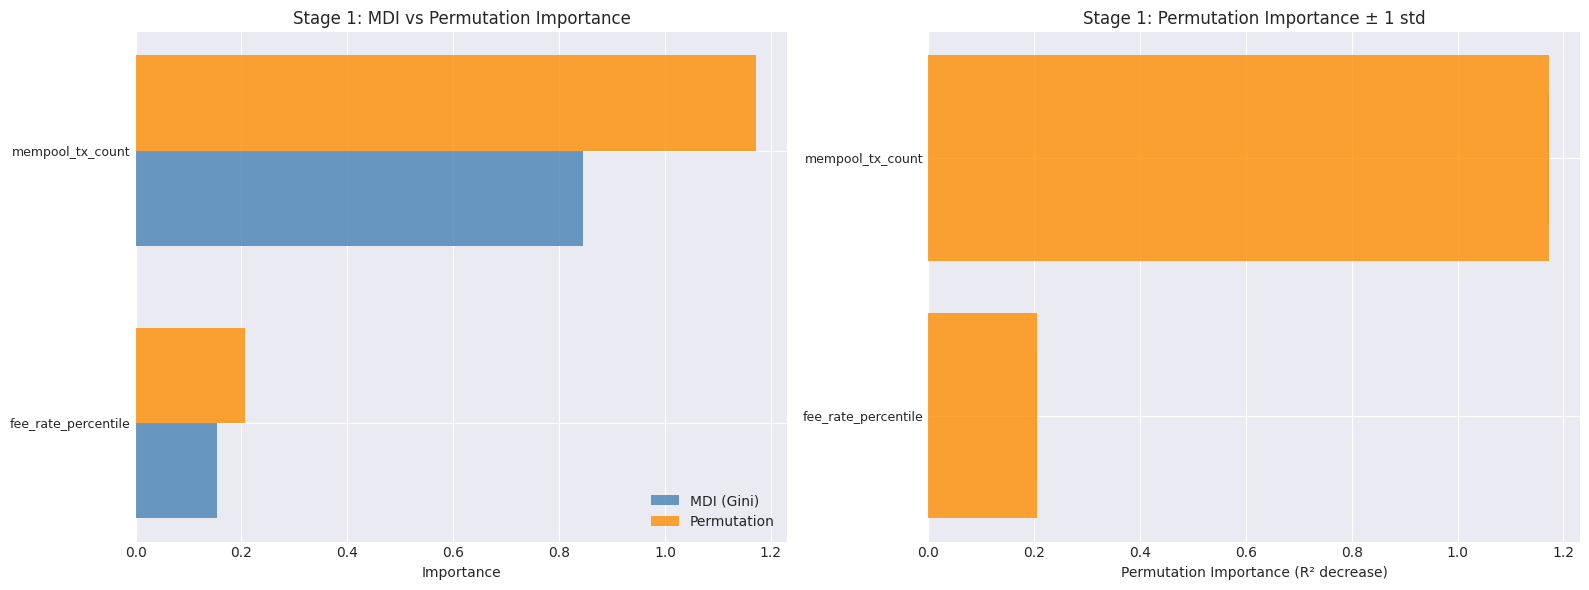


--- Variance Inflation Factors (VIF) ---
  fee_rate_percentile      :     1.00
  mempool_tx_count         :     1.00

✓ All VIFs < 5 — no strong multicollinearity detected.

--- Condition Number of Stage 1 Feature Matrix ---
  Condition number: 119176.9
  ⚠ Very high (>1000) — severe multicollinearity likely

--- Pairwise Correlation Heatmap ---


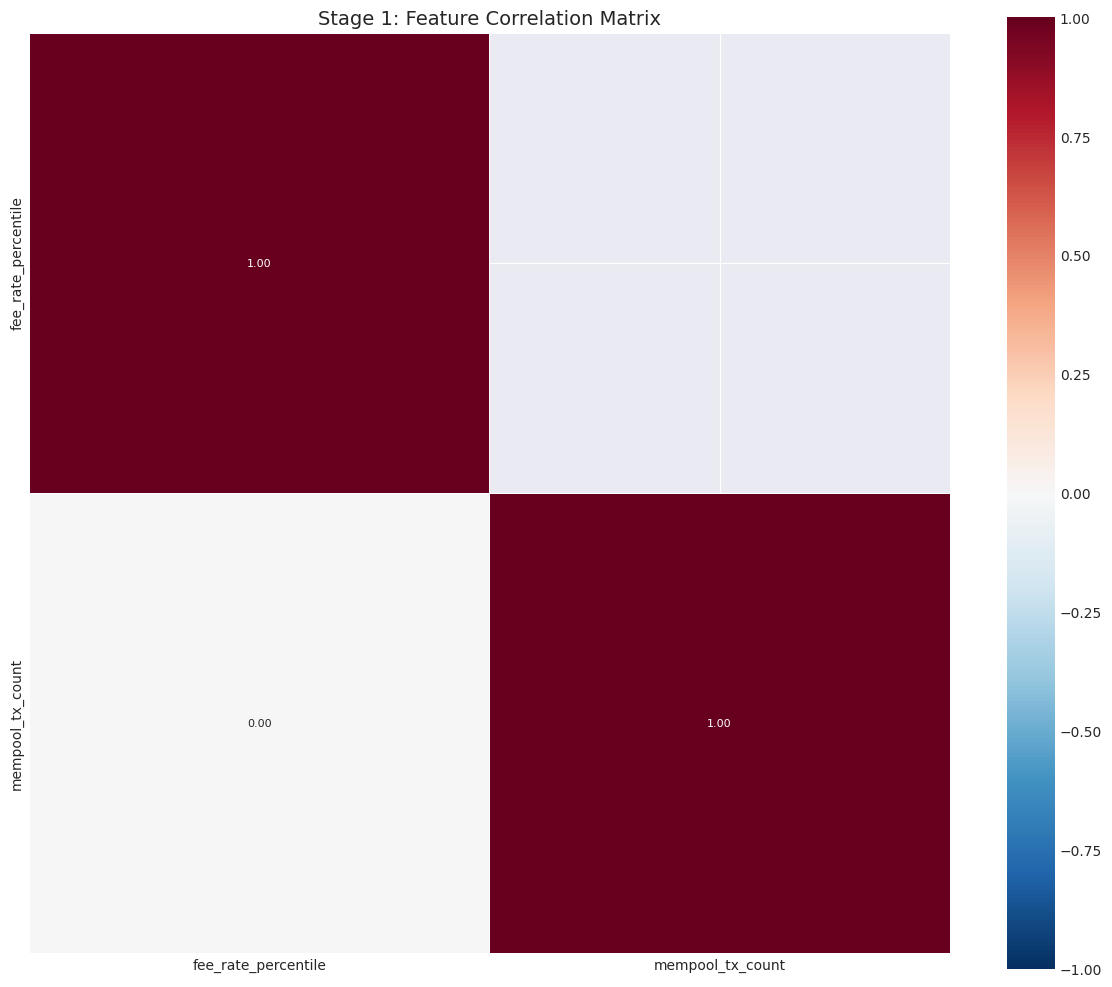


Highly correlated feature pairs (|r| > 0.5):
  ✓ No feature pairs with |r| > 0.5


In [15]:
# =============================================================================
# Section 4.4b: Stage 1 Feature Importance & Multicollinearity Diagnostics
# =============================================================================
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("=" * 70)
print("STAGE 1: FEATURE IMPORTANCE & MULTICOLLINEARITY DIAGNOSTICS")
print("=" * 70)

# --- Recreate train/test split (same random_state as in fit) ---
df_valid_s1 = df.loc[stage1._valid_indices].copy()
X_s1 = df_valid_s1[stage1.FEATURES].values
y_s1 = df_valid_s1[stage1.TARGET].values
X_train_s1, X_test_s1, y_train_s1, y_test_s1 = train_test_split(
    X_s1, y_s1, test_size=0.2, random_state=42
)

# =====================================================================
# 1. Permutation Importance (on held-out test set)
# =====================================================================
print("\n--- Permutation Importance (test set, 10 repeats) ---")
perm_result = permutation_importance(
    stage1.model, X_test_s1, y_test_s1,
    n_repeats=10, random_state=42, n_jobs=-1, scoring='r2'
)

# Build comparison DataFrame: MDI vs Permutation
mdi_importances = stage1.model.feature_importances_
perm_means = perm_result.importances_mean
perm_stds = perm_result.importances_std

importance_df = pd.DataFrame({
    'feature': stage1.FEATURES,
    'MDI (Gini)': mdi_importances,
    'Permutation (mean)': perm_means,
    'Permutation (std)': perm_stds,
}).sort_values('Permutation (mean)', ascending=False)

print(importance_df.to_string(index=False))

# Check for features where MDI rank differs substantially from permutation rank
importance_df['MDI_rank'] = importance_df['MDI (Gini)'].rank(ascending=False).astype(int)
importance_df['Perm_rank'] = importance_df['Permutation (mean)'].rank(ascending=False).astype(int)
importance_df['Rank_diff'] = (importance_df['MDI_rank'] - importance_df['Perm_rank']).abs()

rank_movers = importance_df[importance_df['Rank_diff'] >= 3].sort_values('Rank_diff', ascending=False)
if len(rank_movers) > 0:
    print("\n⚠ Features with rank shift ≥ 3 (MDI may be inflated/deflated by correlation):")
    for _, row in rank_movers.iterrows():
        direction = "inflated" if row['MDI_rank'] < row['Perm_rank'] else "deflated"
        print(f"  {row['feature']:25s}: MDI rank {row['MDI_rank']:2d} → Perm rank {row['Perm_rank']:2d} (MDI {direction})")
else:
    print("\n✓ No large rank shifts between MDI and permutation importance.")

# =====================================================================
# 2. Visualization: MDI vs Permutation Importance
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sort for plotting
plot_df = importance_df.sort_values('Permutation (mean)', ascending=True)

# Left panel: side-by-side horizontal bars
y_pos = np.arange(len(plot_df))
bar_height = 0.35

axes[0].barh(y_pos - bar_height/2, plot_df['MDI (Gini)'].values, bar_height,
             label='MDI (Gini)', alpha=0.8, color='steelblue')
axes[0].barh(y_pos + bar_height/2, plot_df['Permutation (mean)'].values, bar_height,
             label='Permutation', alpha=0.8, color='darkorange')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(plot_df['feature'].values, fontsize=9)
axes[0].set_xlabel('Importance')
axes[0].set_title('Stage 1: MDI vs Permutation Importance')
axes[0].legend(loc='lower right')

# Right panel: permutation importance with error bars
axes[1].barh(y_pos, plot_df['Permutation (mean)'].values, color='darkorange', alpha=0.8)
axes[1].barh(y_pos, plot_df['Permutation (std)'].values,
             left=plot_df['Permutation (mean)'].values - plot_df['Permutation (std)'].values,
             height=0.5, color='darkorange', alpha=0.3)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(plot_df['feature'].values, fontsize=9)
axes[1].set_xlabel('Permutation Importance (R² decrease)')
axes[1].set_title('Stage 1: Permutation Importance ± 1 std')

plt.tight_layout()
plt.savefig('/home/kristian/notebooks/plots/stage1_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# =====================================================================
# 3. Multicollinearity: VIF
# =====================================================================
print("\n--- Variance Inflation Factors (VIF) ---")
X_s1_df = pd.DataFrame(X_s1, columns=stage1.FEATURES)

# Add constant for VIF computation
X_s1_with_const = X_s1_df.copy()
X_s1_with_const.insert(0, 'const', 1.0)

vif_data = []
for i, feat in enumerate(stage1.FEATURES):
    vif_val = variance_inflation_factor(X_s1_with_const.values, i + 1)  # +1 to skip const
    flag = ""
    if vif_val > 10:
        flag = " ⚠ HIGH"
    elif vif_val > 5:
        flag = " ⚡ MODERATE"
    vif_data.append({'Feature': feat, 'VIF': vif_val, 'Flag': flag})
    print(f"  {feat:25s}: {vif_val:8.2f}{flag}")

vif_df = pd.DataFrame(vif_data)
high_vif = vif_df[vif_df['VIF'] > 5]
if len(high_vif) > 0:
    print(f"\n⚠ {len(high_vif)} feature(s) with VIF > 5 — potential multicollinearity:")
    for _, row in high_vif.iterrows():
        print(f"  {row['Feature']}: VIF = {row['VIF']:.2f}")
else:
    print("\n✓ All VIFs < 5 — no strong multicollinearity detected.")

# =====================================================================
# 4. Condition Number
# =====================================================================
cond_number = np.linalg.cond(X_s1)
print(f"\n--- Condition Number of Stage 1 Feature Matrix ---")
print(f"  Condition number: {cond_number:.1f}")
if cond_number > 1000:
    print(f"  ⚠ Very high (>1000) — severe multicollinearity likely")
elif cond_number > 30:
    print(f"  ⚡ Elevated (>30) — moderate multicollinearity possible")
else:
    print(f"  ✓ Acceptable (<30)")

# =====================================================================
# 5. Pairwise Correlation Heatmap
# =====================================================================
print("\n--- Pairwise Correlation Heatmap ---")
corr_matrix = X_s1_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            ax=ax, annot_kws={'size': 8})
ax.set_title('Stage 1: Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('/home/kristian/notebooks/plots/stage1_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print highly correlated pairs
print("\nHighly correlated feature pairs (|r| > 0.5):")
high_corr_found = False
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.5:
            high_corr_found = True
            print(f"  {corr_matrix.index[i]:25s} ↔ {corr_matrix.columns[j]:25s}: r = {r:.3f}")
if not high_corr_found:
    print("  ✓ No feature pairs with |r| > 0.5")


PRIORITY-DELAY RELATIONSHIP BY CONGESTION LEVEL

Correlation(priority, delay) by congestion level:
--------------------------------------------------
  Q1 (Low): corr(p, log_wait)=-0.0632, corr(p, W_mono)=-0.0897, mean_mempool=1,433
  Q2: corr(p, log_wait)=-0.0935, corr(p, W_mono)=-0.1193, mean_mempool=3,311
  Q3: corr(p, log_wait)=-0.1059, corr(p, W_mono)=-0.1441, mean_mempool=21,549
  Q4: corr(p, log_wait)=-0.1395, corr(p, W_mono)=-0.1677, mean_mempool=71,483
  Q5 (High): corr(p, log_wait)=-0.1329, corr(p, W_mono)=-0.1677, mean_mempool=95,317


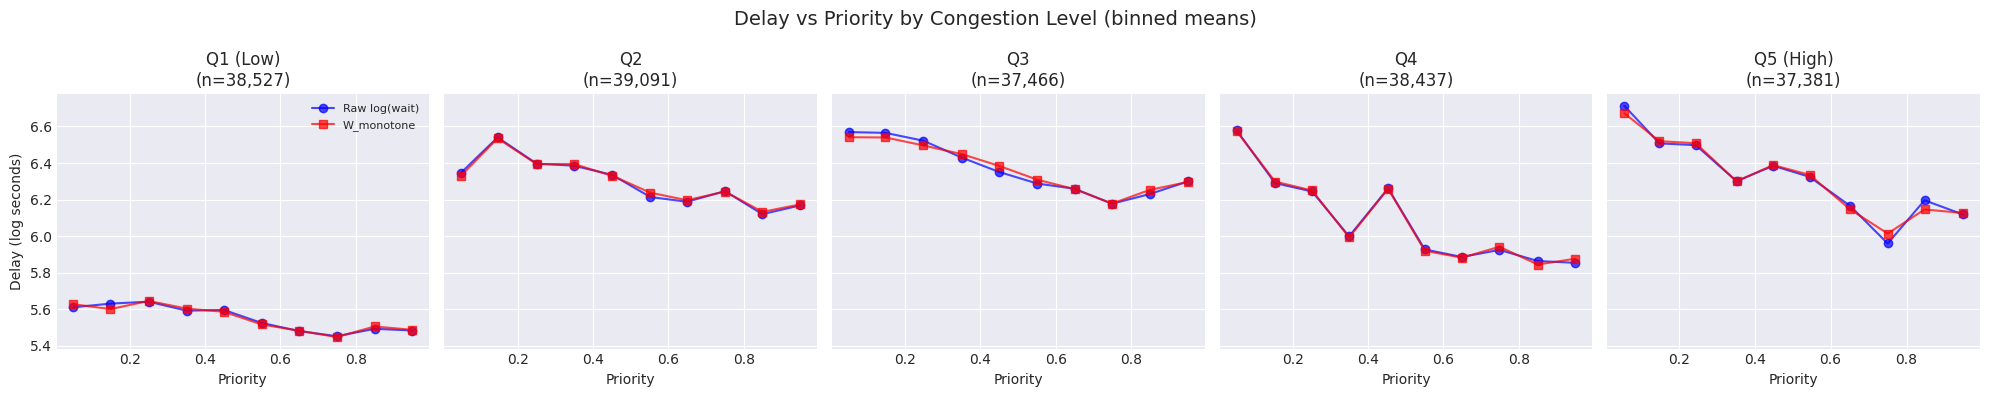


✓ Plot saved to: plots/delay_vs_priority_by_congestion.png

Key insight: The relationship should be STRONGEST in Q5 (high congestion)
because that's when priority actually matters for getting into blocks quickly.


In [16]:
# =============================================================================
# Section 4.5: Priority-Delay Relationship by Congestion Level
# =============================================================================
# The delay-priority relationship should be STRONGEST during high congestion
# when there's real competition for block space

print("\n" + "=" * 60)
print("PRIORITY-DELAY RELATIONSHIP BY CONGESTION LEVEL")
print("=" * 60)

# Get valid data
df_valid = df[df['W_monotone'].notna() & df['fee_rate_percentile'].notna() & df['mempool_tx_count'].notna()].copy()

# Create congestion quintiles
df_valid['congestion_quintile'] = pd.qcut(df_valid['mempool_tx_count'], q=5, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)'])

# Analyze relationship by congestion level
print("\nCorrelation(priority, delay) by congestion level:")
print("-" * 50)
for q in ['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)']:
    subset = df_valid[df_valid['congestion_quintile'] == q]
    if len(subset) > 100:
        # Correlation with raw waittime
        corr_raw = subset['fee_rate_percentile'].corr(subset['log_waittime'])
        # Correlation with monotone delay
        corr_monotone = subset['fee_rate_percentile'].corr(subset['W_monotone'])
        # Mean mempool size
        mean_mempool = subset['mempool_tx_count'].mean()
        print(f"  {q}: corr(p, log_wait)={corr_raw:+.4f}, corr(p, W_mono)={corr_monotone:+.4f}, mean_mempool={mean_mempool:,.0f}")

# Plot
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
fig.suptitle('Delay vs Priority by Congestion Level (binned means)', fontsize=14)

for i, q in enumerate(['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)']):
    ax = axes[i]
    subset = df_valid[df_valid['congestion_quintile'] == q]
    
    if len(subset) > 100:
        # Create priority bins and compute means
        subset['p_bin'] = pd.cut(subset['fee_rate_percentile'], bins=10, labels=False)
        bin_stats = subset.groupby('p_bin').agg({
            'fee_rate_percentile': 'mean',
            'W_monotone': 'mean',
            'log_waittime': 'mean'
        }).reset_index()
        
        # Plot raw waittime
        ax.plot(bin_stats['fee_rate_percentile'], bin_stats['log_waittime'], 
                'o-', color='blue', alpha=0.7, label='Raw log(wait)')
        # Plot monotone delay
        ax.plot(bin_stats['fee_rate_percentile'], bin_stats['W_monotone'], 
                's-', color='red', alpha=0.7, label='W_monotone')
        
        ax.set_xlabel('Priority')
        ax.set_title(f'{q}\n(n={len(subset):,})')
        if i == 0:
            ax.set_ylabel('Delay (log seconds)')
            ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('/home/kristian/notebooks/plots/delay_vs_priority_by_congestion.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Plot saved to: plots/delay_vs_priority_by_congestion.png")
print("\nKey insight: The relationship should be STRONGEST in Q5 (high congestion)")
print("because that's when priority actually matters for getting into blocks quickly.")

FEE RATE DISTRIBUTION ANALYSIS FOR EPSILON SELECTION

Total transactions: 190,902

Fee rate statistics (sat/vB):
  Min:    0.12
  1%:     1.00
  5%:     1.00
  10%:    1.01
  25%:    1.51
  Median: 3.00
  75%:    4.57
  90%:    7.58
  95%:    10.09
  99%:    36.32
  Max:    1008.26

Most common fee rates (potential defaults):
     1.0 sat/vB:   28,373 txs (14.86%, cumulative:  14.9%)
     2.0 sat/vB:   20,364 txs (10.67%, cumulative:  25.5%)
     3.0 sat/vB:   18,168 txs ( 9.52%, cumulative:  35.0%)
     4.0 sat/vB:   11,269 txs ( 5.90%, cumulative:  40.9%)
     1.2 sat/vB:    8,777 txs ( 4.60%, cumulative:  45.5%)
     5.0 sat/vB:    7,394 txs ( 3.87%, cumulative:  49.4%)
     2.3 sat/vB:    6,139 txs ( 3.22%, cumulative:  52.6%)
     1.1 sat/vB:    5,746 txs ( 3.01%, cumulative:  55.6%)
     2.2 sat/vB:    4,498 txs ( 2.36%, cumulative:  58.0%)
     6.0 sat/vB:    4,426 txs ( 2.32%, cumulative:  60.3%)
     2.1 sat/vB:    3,729 txs ( 1.95%, cumulative:  62.3%)
     2.4 sat/vB:    3,5

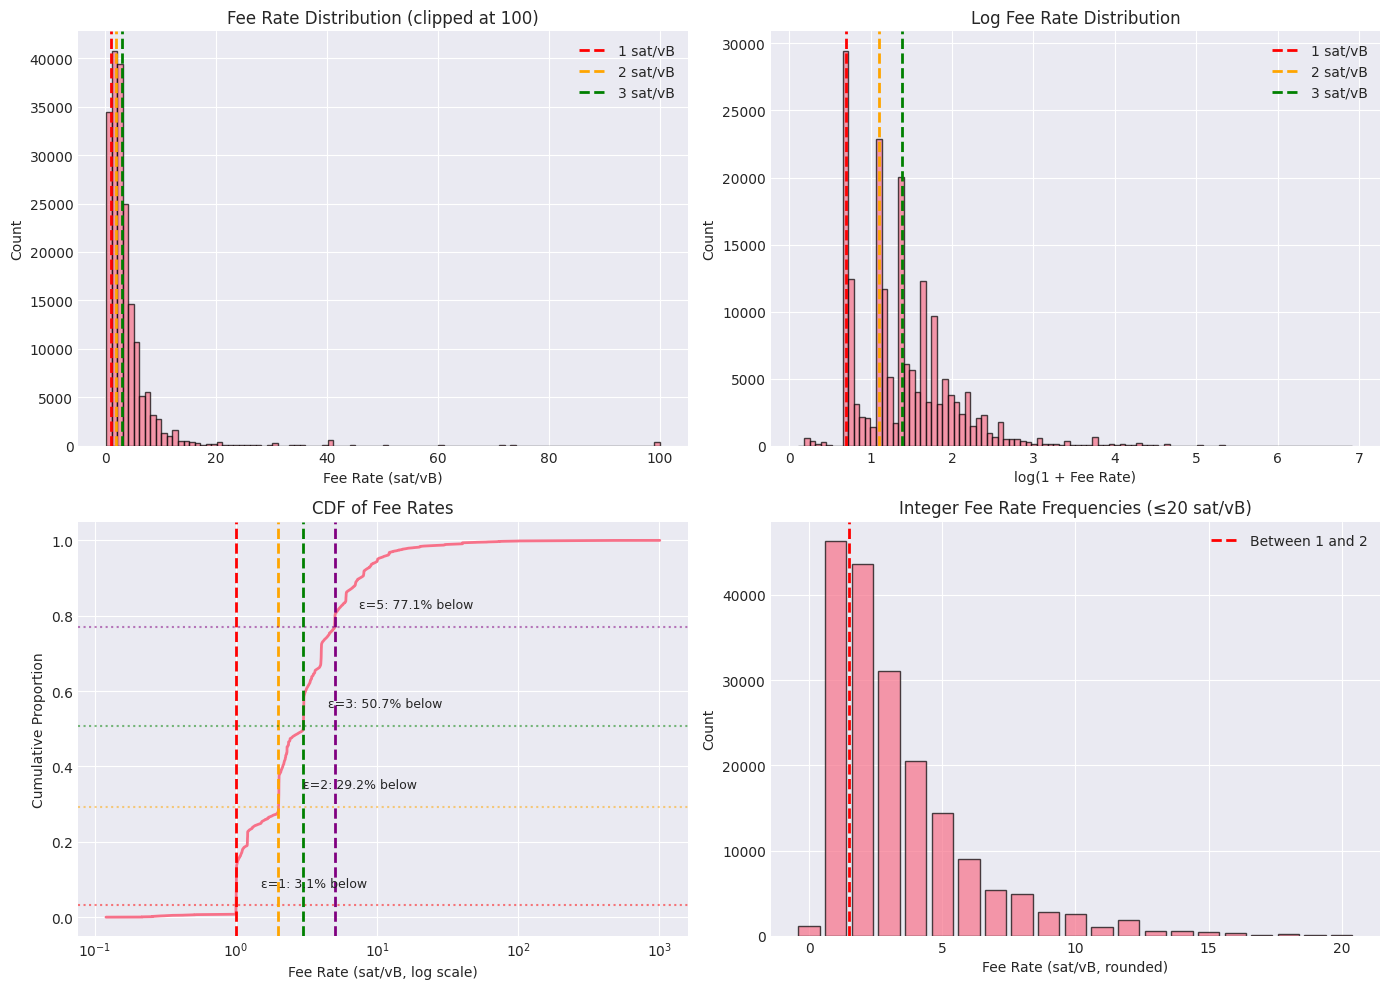


EPSILON RECOMMENDATIONS

ε = 1 sat/vB:
  'Default payers' (fee ≤ ε): 5,948 (3.1%)
  'Active payers' (fee > ε):  184,954 (96.9%)

ε = 2 sat/vB:
  'Default payers' (fee ≤ ε): 55,711 (29.2%)
  'Active payers' (fee > ε):  135,191 (70.8%)

ε = 3 sat/vB:
  'Default payers' (fee ≤ ε): 96,769 (50.7%)
  'Active payers' (fee > ε):  94,133 (49.3%)

ε = 5 sat/vB:
  'Default payers' (fee ≤ ε): 147,212 (77.1%)
  'Active payers' (fee > ε):  43,690 (22.9%)

✓ Plot saved to: plots/fee_rate_distribution.png


In [17]:
# =============================================================================
# Section 4.6: Fee Rate Distribution for Epsilon Selection
# =============================================================================
# Goal: Find a good threshold (epsilon) to separate:
#   - "Default payers" who don't optimize their fee (fee <= epsilon)
#   - "Active payers" who choose their fee strategically (fee > epsilon)

print("=" * 60)
print("FEE RATE DISTRIBUTION ANALYSIS FOR EPSILON SELECTION")
print("=" * 60)

# Get valid fee rates
fee_rates = df['fee_rate'].dropna()
print(f"\nTotal transactions: {len(fee_rates):,}")

# Basic statistics
print(f"\nFee rate statistics (sat/vB):")
print(f"  Min:    {fee_rates.min():.2f}")
print(f"  1%:     {fee_rates.quantile(0.01):.2f}")
print(f"  5%:     {fee_rates.quantile(0.05):.2f}")
print(f"  10%:    {fee_rates.quantile(0.10):.2f}")
print(f"  25%:    {fee_rates.quantile(0.25):.2f}")
print(f"  Median: {fee_rates.median():.2f}")
print(f"  75%:    {fee_rates.quantile(0.75):.2f}")
print(f"  90%:    {fee_rates.quantile(0.90):.2f}")
print(f"  95%:    {fee_rates.quantile(0.95):.2f}")
print(f"  99%:    {fee_rates.quantile(0.99):.2f}")
print(f"  Max:    {fee_rates.max():.2f}")

# Most common fee rates (likely defaults)
# Round to 1 decimal to group similar rates (avoids floating point noise)
print(f"\nMost common fee rates (potential defaults):")
fee_rates_rounded = fee_rates.round(1)
top_fees = fee_rates_rounded.value_counts().head(20)
cumsum = 0
for fee, count in top_fees.items():
    pct = count / len(fee_rates) * 100
    cumsum += pct
    print(f"  {fee:6.1f} sat/vB: {count:>8,} txs ({pct:5.2f}%, cumulative: {cumsum:5.1f}%)")

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram of fee rates (linear scale, clipped)
ax = axes[0, 0]
ax.hist(fee_rates.clip(upper=100), bins=100, edgecolor='black', alpha=0.7)
ax.axvline(x=1, color='red', linestyle='--', linewidth=2, label='1 sat/vB')
ax.axvline(x=2, color='orange', linestyle='--', linewidth=2, label='2 sat/vB')
ax.axvline(x=3, color='green', linestyle='--', linewidth=2, label='3 sat/vB')
ax.set_xlabel('Fee Rate (sat/vB)')
ax.set_ylabel('Count')
ax.set_title('Fee Rate Distribution (clipped at 100)')
ax.legend()

# 2. Histogram of fee rates (log scale)
ax = axes[0, 1]
log_fees = np.log1p(fee_rates)
ax.hist(log_fees, bins=100, edgecolor='black', alpha=0.7)
ax.axvline(x=np.log1p(1), color='red', linestyle='--', linewidth=2, label='1 sat/vB')
ax.axvline(x=np.log1p(2), color='orange', linestyle='--', linewidth=2, label='2 sat/vB')
ax.axvline(x=np.log1p(3), color='green', linestyle='--', linewidth=2, label='3 sat/vB')
ax.set_xlabel('log(1 + Fee Rate)')
ax.set_ylabel('Count')
ax.set_title('Log Fee Rate Distribution')
ax.legend()

# 3. CDF with candidate epsilon values
ax = axes[1, 0]
sorted_fees = np.sort(fee_rates)
cdf = np.arange(1, len(sorted_fees) + 1) / len(sorted_fees)
# Subsample for plotting
idx = np.linspace(0, len(sorted_fees)-1, 10000).astype(int)
ax.plot(sorted_fees[idx], cdf[idx], linewidth=2)
ax.set_xscale('log')
ax.set_xlabel('Fee Rate (sat/vB, log scale)')
ax.set_ylabel('Cumulative Proportion')
ax.set_title('CDF of Fee Rates')

# Mark candidate epsilon values
for eps, color, label in [(1, 'red', 'ε=1'), (2, 'orange', 'ε=2'), (3, 'green', 'ε=3'), (5, 'purple', 'ε=5')]:
    prop_below = (fee_rates <= eps).mean()
    ax.axvline(x=eps, color=color, linestyle='--', linewidth=2)
    ax.axhline(y=prop_below, color=color, linestyle=':', alpha=0.5)
    ax.annotate(f'{label}: {prop_below:.1%} below', xy=(eps, prop_below), 
                xytext=(eps*1.5, prop_below+0.05), fontsize=9)

# 4. Bar chart of fee rate frequencies (integer values)
ax = axes[1, 1]
int_fees = fee_rates[fee_rates <= 20].round().astype(int)
fee_counts = int_fees.value_counts().sort_index()
ax.bar(fee_counts.index, fee_counts.values, edgecolor='black', alpha=0.7)
ax.set_xlabel('Fee Rate (sat/vB, rounded)')
ax.set_ylabel('Count')
ax.set_title('Integer Fee Rate Frequencies (≤20 sat/vB)')
ax.axvline(x=1.5, color='red', linestyle='--', linewidth=2, label='Between 1 and 2')
ax.legend()

plt.tight_layout()
plt.savefig('/home/kristian/notebooks/plots/fee_rate_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Recommendation
print("\n" + "=" * 60)
print("EPSILON RECOMMENDATIONS")
print("=" * 60)
for eps in [1, 2, 3, 5]:
    n_below = (fee_rates <= eps).sum()
    n_above = (fee_rates > eps).sum()
    pct_below = n_below / len(fee_rates) * 100
    print(f"\nε = {eps} sat/vB:")
    print(f"  'Default payers' (fee ≤ ε): {n_below:,} ({pct_below:.1f}%)")
    print(f"  'Active payers' (fee > ε):  {n_above:,} ({100-pct_below:.1f}%)")

print("\n✓ Plot saved to: plots/fee_rate_distribution.png")

CPFP PACKAGE ANALYSIS (POST-COLLAPSE)

Total observations (after collapse): 190,902
  CPFP packages: 21,592 (11.31%)
  Non-CPFP transactions: 169,310 (88.69%)

--------------------------------------------------
CPFP Package Fee Rate Transformation
--------------------------------------------------

Original Parent Fee Rates (sat/vB):
  Mean:   3.01
  Median: 1.71
  Zero-fee parents: 46 (0.2%)

Package Fee Rates (sat/vB):
  Mean:   3.67
  Median: 2.12
  Zero-fee packages: 0 (0.0%)

Fee Rate Increase:
  Mean increase: 0.66 sat/vB
  Median increase: 0.00 sat/vB

--------------------------------------------------
Fee Rate Distribution by Type
--------------------------------------------------

CPFP Package Fee Rates:
  Mean:   3.67
  Median: 2.12
  Std:    7.44

Non-CPFP Transaction Fee Rates:
  Mean:   4.50
  Median: 3.01
  Std:    12.63


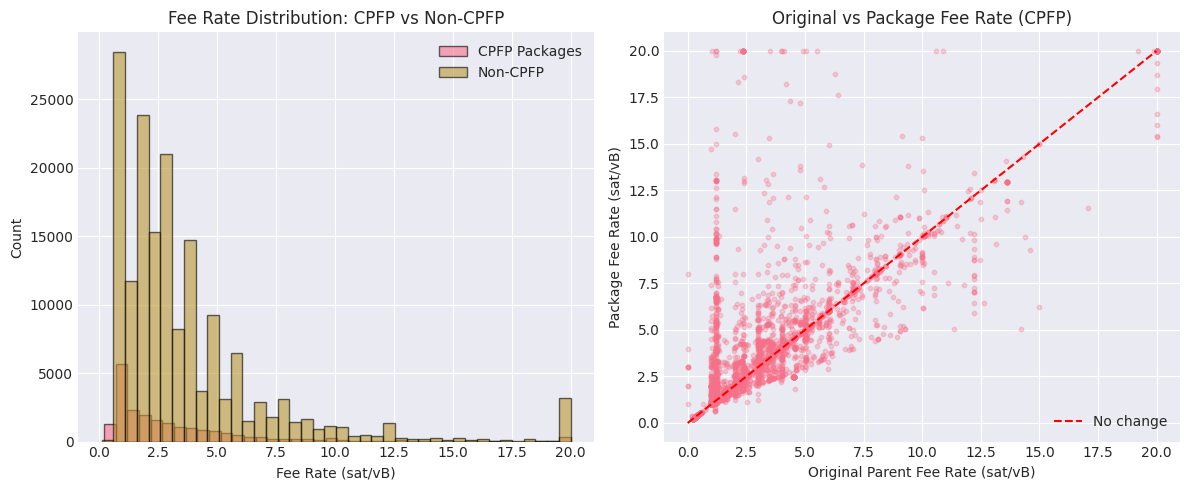


✓ Plot saved to: plots/cpfp_package_analysis.png


In [18]:
# =============================================================================
# Section 4.7: CPFP Package Analysis (Post-Collapse)
# =============================================================================
# Analyze the effect of CPFP package collapsing on fee rate distribution
# Note: CPFP pairs have been collapsed to single observations using package fee rate

print("=" * 60)
print("CPFP PACKAGE ANALYSIS (POST-COLLAPSE)")
print("=" * 60)

# After CPFP collapse, analyze the transformed data
# is_cpfp_package=1 indicates this is a collapsed parent-child pair
cpfp_packages = df[df['is_cpfp_package'] == 1].copy()
non_cpfp = df[df['is_cpfp_package'] == 0].copy()

print(f"\nTotal observations (after collapse): {len(df):,}")
print(f"  CPFP packages: {len(cpfp_packages):,} ({len(cpfp_packages)/len(df)*100:.2f}%)")
print(f"  Non-CPFP transactions: {len(non_cpfp):,} ({len(non_cpfp)/len(df)*100:.2f}%)")

# Analyze original vs package fee rates for CPFP packages
if 'original_fee_rate' in cpfp_packages.columns and len(cpfp_packages) > 0:
    print("\n" + "-" * 50)
    print("CPFP Package Fee Rate Transformation")
    print("-" * 50)
    
    # Stats on original parent fee rates
    orig_rates = cpfp_packages['original_fee_rate']
    pkg_rates = cpfp_packages['fee_rate']
    
    print(f"\nOriginal Parent Fee Rates (sat/vB):")
    print(f"  Mean:   {orig_rates.mean():.2f}")
    print(f"  Median: {orig_rates.median():.2f}")
    print(f"  Zero-fee parents: {(orig_rates == 0).sum():,} ({(orig_rates == 0).mean()*100:.1f}%)")
    
    print(f"\nPackage Fee Rates (sat/vB):")
    print(f"  Mean:   {pkg_rates.mean():.2f}")
    print(f"  Median: {pkg_rates.median():.2f}")
    print(f"  Zero-fee packages: {(pkg_rates == 0).sum():,} ({(pkg_rates == 0).mean()*100:.1f}%)")
    
    print(f"\nFee Rate Increase:")
    fee_increase = pkg_rates - orig_rates
    print(f"  Mean increase: {fee_increase.mean():.2f} sat/vB")
    print(f"  Median increase: {fee_increase.median():.2f} sat/vB")

# Compare fee rate distributions
print("\n" + "-" * 50)
print("Fee Rate Distribution by Type")
print("-" * 50)

print(f"\nCPFP Package Fee Rates:")
print(f"  Mean:   {cpfp_packages['fee_rate'].mean():.2f}")
print(f"  Median: {cpfp_packages['fee_rate'].median():.2f}")
print(f"  Std:    {cpfp_packages['fee_rate'].std():.2f}")

print(f"\nNon-CPFP Transaction Fee Rates:")
print(f"  Mean:   {non_cpfp['fee_rate'].mean():.2f}")
print(f"  Median: {non_cpfp['fee_rate'].median():.2f}")
print(f"  Std:    {non_cpfp['fee_rate'].std():.2f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Compare fee rate distributions
ax = axes[0]
if len(cpfp_packages) > 0:
    ax.hist(cpfp_packages['fee_rate'].clip(upper=20), bins=40, alpha=0.6, 
            label='CPFP Packages', edgecolor='black')
ax.hist(non_cpfp['fee_rate'].clip(upper=20), bins=40, alpha=0.6, 
        label='Non-CPFP', edgecolor='black')
ax.set_xlabel('Fee Rate (sat/vB)')
ax.set_ylabel('Count')
ax.set_title('Fee Rate Distribution: CPFP vs Non-CPFP')
ax.legend()

# Compare original vs package fee rate for CPFP
ax = axes[1]
if 'original_fee_rate' in df.columns and len(cpfp_packages) > 0:
    sample = cpfp_packages.sample(min(5000, len(cpfp_packages)))
    ax.scatter(sample['original_fee_rate'].clip(upper=20), 
               sample['fee_rate'].clip(upper=20), 
               alpha=0.3, s=10)
    ax.plot([0, 20], [0, 20], 'r--', label='No change')
    ax.set_xlabel('Original Parent Fee Rate (sat/vB)')
    ax.set_ylabel('Package Fee Rate (sat/vB)')
    ax.set_title('Original vs Package Fee Rate (CPFP)')
    ax.legend()
else:
    ax.text(0.5, 0.5, 'No CPFP packages', ha='center', va='center')
    ax.set_title('CPFP Package Analysis')

plt.tight_layout()
plt.savefig('/home/kristian/notebooks/plots/cpfp_package_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Plot saved to: plots/cpfp_package_analysis.png")

---
## Section 5: Stage 2 - Hurdle Fee Model

The hurdle model estimates two components (Section 5.4):

1. **Extensive Margin**: P(D_it = 1 | ·) - probability of paying a meaningful fee
   - Binary outcome: D_it = 1{b_it > ε}
   - Logistic regression

2. **Intensive Margin**: E[log b_it | b_it > ε, ·] - conditional log-fee among payers
   - Ridge regression on log(fee)
   - Smearing correction (ψ) to recover level predictions

**Key**: Priority (p) does NOT appear directly - it enters only through log_Wprime from Stage 1

In [19]:
# =============================================================================
# Section 5.1: I-Spline Transformer for Monotone Impatience Mapping
# =============================================================================
# I-splines (Ramsay 1988) are integrated M-splines (normalised B-splines).
# Each basis function I_j(ι) is monotonically non-decreasing from 0 to 1.
# Combined with nonnegativity constraints  δ_j ≥ 0  the linear combination
#     s(ι) = Σ δ_j I_j(ι)
# is guaranteed to be weakly increasing — matching the economic prior that
# greater impatience should never reduce the propensity or level of fees.

IMPATIENCE_SPLINE_DEGREE = 3   # cubic
IMPATIENCE_SPLINE_N_KNOTS = 5  # quantile-based knot positions (incl. boundaries)


class ISplineTransformer:
    """
    I-Spline (integrated M-spline) basis transformer.

    Each basis function I_j(x) is monotonically non-decreasing on [0, 1].
    Combined with nonnegative coefficients δ_j ≥ 0, the linear combination
    Σ δ_j I_j(x) is guaranteed to be weakly increasing.

    Parameters
    ----------
    n_knots : int
        Number of quantile-based knot positions (including boundaries).
    degree : int
        Polynomial degree (3 = cubic).
    """

    def __init__(self, n_knots: int = 5, degree: int = 3):
        self.n_knots = n_knots
        self.degree = degree
        self._knot_vector = None
        self._n_basis = None
        self._lower = None
        self._upper = None

    def fit(self, X) -> 'ISplineTransformer':
        x = np.asarray(X).ravel()
        quantiles = np.linspace(0, 100, self.n_knots)
        knot_positions = np.percentile(x, quantiles)

        self._lower = float(knot_positions[0])
        self._upper = float(knot_positions[-1])
        internal = knot_positions[1:-1]

        self._knot_vector = np.concatenate([
            np.repeat(self._lower, self.degree + 1),
            internal,
            np.repeat(self._upper, self.degree + 1),
        ])
        self._n_basis = len(self._knot_vector) - self.degree - 1
        return self

    def transform(self, X) -> np.ndarray:
        x = np.asarray(X).ravel()
        n = len(x)
        order = self.degree + 1
        basis = np.zeros((n, self._n_basis))

        x_clamped = np.clip(x, self._lower, self._upper)

        for i in range(self._n_basis):
            span = self._knot_vector[i + order] - self._knot_vector[i]
            if span <= 0:
                continue

            # M-spline_i = (order / span) · B-spline_i
            coefs = np.zeros(self._n_basis)
            coefs[i] = order / span
            mspl = BSpline(self._knot_vector, coefs, self.degree)

            # I-spline_i = antiderivative of M-spline_i, evaluated from lower bound
            ispl = mspl.antiderivative()
            vals = ispl(x_clamped) - ispl(self._lower)

            total = ispl(self._upper) - ispl(self._lower)
            if total > 1e-12:
                vals /= total

            basis[:, i] = np.clip(vals, 0.0, 1.0)

        return basis

    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        return self.fit(X).transform(X)


print(f"I-Spline transformer defined (degree={IMPATIENCE_SPLINE_DEGREE}, "
      f"n_knots={IMPATIENCE_SPLINE_N_KNOTS})")
print("  Monotonicity: I-spline basis × nonneg coefficients → weakly increasing")

I-Spline transformer defined (degree=3, n_knots=5)
  Monotonicity: I-spline basis × nonneg coefficients → weakly increasing


In [20]:
# =============================================================================
# Section 5.2: Estimation Functions
# =============================================================================

def fit_logistic(X: np.ndarray, y: np.ndarray, max_iter: int = 1000,
                 bounds: Optional[list] = None) -> np.ndarray:
    """
    Fit logistic regression via L-BFGS-B with optional coefficient bounds.

    Args:
        X: Feature matrix (including intercept column)
        y: Binary target variable
        max_iter: Maximum optimization iterations
        bounds: Per-coefficient (lo, hi) bounds; None = unconstrained

    Returns:
        Coefficient array
    """
    n_total = X.shape[1]

    def neg_log_likelihood(beta):
        linear_pred = np.clip(X @ beta, -500, 500)
        return -np.sum(y * linear_pred - np.log1p(np.exp(linear_pred)))

    def gradient(beta):
        linear_pred = np.clip(X @ beta, -500, 500)
        prob = 1 / (1 + np.exp(-linear_pred))
        return -X.T @ (y - prob)

    x0 = np.zeros(n_total)
    if bounds is None:
        bounds = [(None, None)] * n_total

    result = minimize(
        neg_log_likelihood,
        x0,
        method='L-BFGS-B',
        jac=gradient,
        bounds=bounds,
        options={'maxiter': max_iter, 'disp': False}
    )

    return result.x


def fit_regularized_ols(X: np.ndarray, y: np.ndarray, alpha: float = 1.0,
                        bounds: Optional[list] = None) -> np.ndarray:
    """
    Fit OLS (alpha=0) or Ridge regression with optional coefficient bounds.
    Falls back to sklearn when unconstrained for speed.
    """
    if bounds is None:
        if alpha > 0:
            from sklearn.linear_model import Ridge
            model = Ridge(alpha=alpha, fit_intercept=False)
        else:
            from sklearn.linear_model import LinearRegression
            model = LinearRegression(fit_intercept=False)
        model.fit(X, y)
        return model.coef_

    # Constrained case
    if alpha == 0:
        lb = np.array([b[0] if b[0] is not None else -np.inf for b in bounds])
        ub = np.array([b[1] if b[1] is not None else  np.inf for b in bounds])
        result = lsq_linear(X, y, bounds=(lb, ub))
        return result.x

    # Ridge with bounds → L-BFGS-B
    n = X.shape[0]

    def objective(beta):
        r = y - X @ beta
        return 0.5 * np.sum(r ** 2) / n + 0.5 * alpha * np.sum(beta ** 2)

    def gradient(beta):
        r = y - X @ beta
        return -X.T @ r / n + alpha * beta

    x0 = np.zeros(X.shape[1])
    result = minimize(objective, x0, method='L-BFGS-B', jac=gradient,
                      bounds=bounds, options={'maxiter': 2000, 'disp': False})
    return result.x


print("Estimation functions defined (with monotonicity-constraint support)")

Estimation functions defined (with monotonicity-constraint support)


In [21]:
# =============================================================================
# Section 5.3: HurdleFeeModel Class (WITH EPOCH FIXED EFFECTS)
# =============================================================================

class HurdleFeeModel:
    """
    Stage 2: Hurdle model for fee estimation with epoch fixed effects.

    Estimates two components:
    1. Extensive margin h(ι): P(fee > ε | X) using logistic regression
    2. Intensive margin s(ι): E[log(fee) | fee > ε, X] via Ridge/OLS,
       or Q_τ[log(fee) | …] via quantile regression when quantile is set

    Impatience enters via an I-spline basis with nonneg coefficients
    to enforce the monotonicity restriction from the paper (§ eq. 7–8).
    blockspace_utilization uses a standard B-spline basis.

    Epoch fixed effects absorb time-varying congestion shocks.
    """

    CONTROL_FEATURES = [
        'log_Wprime',  'has_rbf', 'is_cpfp_package', 'log_total_output',
        'log_n_in', 'log_n_out',
        'has_op_return', 'has_inscription',
    ]
    # blockspace_utilization is kept here for column validation but is
    # handled separately in _build_feature_matrix via a spline expansion.
    STATE_FEATURES = [
        'blockspace_utilization',
        'log_time_since_last_block',
        'log_size',
    ]

    # Knots for the blockspace spline.  Boundary knots at 0 and 1; interior
    # knots are clustered near the 0.85-0.95 region where residuals curve.
    _BLOCKSPACE_KNOTS = np.array([[0.0], [0.3], [0.6], [0.80], [0.88], [0.94], [1.0]])

    def __init__(self, config: EstimationConfig, use_epoch_fe: bool = True,
                 use_ridge: bool = True, ridge_alpha: float = 1.0,
                 quantile: Optional[float] = None):
        self.config = config
        self.use_epoch_fe = use_epoch_fe
        self.use_ridge = use_ridge
        self.ridge_alpha = ridge_alpha
        self.quantile = quantile
        self.ext_coefs = None
        self.int_coefs = None
        self.smearing_factor = None
        self.epoch_labels = None
        self.epoch_labels_for_dummies = None
        self._n_epoch_dummies = 0
        self._feature_names = None
        self._blockspace_spline = None   # fitted SplineTransformer for blockspace
        self._impatience_spline = None   # fitted ISplineTransformer for impatience
        self._impatience_clip = None     # (low, high) percentile bounds for clipping
        self._ispline_col_start = None   # first I-spline column index in X
        self._n_ispline_basis = 0        # number of I-spline basis columns
        self._is_fitted = False

    def _build_feature_matrix(self, df: pd.DataFrame, fit_spline: bool = False) -> Tuple[np.ndarray, List[str]]:
        """
        Build the feature matrix with control/state features and epoch FE.

        blockspace_utilization uses a cubic B-spline basis.
        impatience uses an I-spline (integrated M-spline) basis for
        monotone mapping.  Splines are fitted on the first call
        (fit_spline=True) and reused for subsequent prediction calls.
        """
        # --- Linear features ------------------------------------------------
        control_vals = df[self.CONTROL_FEATURES].values
        feature_names = list(self.CONTROL_FEATURES)

        linear_state = [f for f in self.STATE_FEATURES if f != 'blockspace_utilization']
        state_vals = df[linear_state].values
        feature_names += linear_state

        # --- Blockspace spline ----------------------------------------------
        bs_raw = df[['blockspace_utilization']].values
        if fit_spline:
            self._blockspace_spline = SplineTransformer(
                degree=3,
                knots=self._BLOCKSPACE_KNOTS,
                include_bias=False,
            )
            bs_basis = self._blockspace_spline.fit_transform(bs_raw)
            n_bs = bs_basis.shape[1]
            print(f"  Blockspace spline: {n_bs} basis functions "
                  f"(knots at {self._BLOCKSPACE_KNOTS.ravel().tolist()})")
        else:
            bs_basis = self._blockspace_spline.transform(bs_raw)

        bs_names = [f'blockspace_spl_{i}' for i in range(bs_basis.shape[1])]
        feature_names += bs_names

        # --- I-spline for impatience (monotone basis) -------------------------
        imp_raw = df[['impatience']].values
        if fit_spline:
            lo, hi = np.percentile(imp_raw, [1, 99])
            self._impatience_clip = (lo, hi)
            imp_clipped = np.clip(imp_raw, lo, hi)
            self._impatience_spline = ISplineTransformer(
                n_knots=IMPATIENCE_SPLINE_N_KNOTS,
                degree=IMPATIENCE_SPLINE_DEGREE,
            )
            imp_basis = self._impatience_spline.fit_transform(imp_clipped)
            self._ispline_col_start = len(feature_names)
            self._n_ispline_basis = imp_basis.shape[1]
            print(f"  Impatience I-spline: {self._n_ispline_basis} basis functions "
                  f"(n_knots={IMPATIENCE_SPLINE_N_KNOTS}, "
                  f"clip=[{lo:.4f}, {hi:.4f}])")
        else:
            imp_clipped = np.clip(imp_raw, *self._impatience_clip)
            imp_basis = self._impatience_spline.transform(imp_clipped)

        imp_names = [f'impatience_spl_{i}' for i in range(imp_basis.shape[1])]
        feature_names += imp_names

        X = np.hstack([control_vals, state_vals, bs_basis, imp_basis])

        # --- Epoch fixed effects --------------------------------------------
        if self.use_epoch_fe:
            if fit_spline:
                self.epoch_labels = sorted(df['epoch_id'].unique())
                self.epoch_labels_for_dummies = self.epoch_labels[1:]
                self._n_epoch_dummies = len(self.epoch_labels_for_dummies)
                print(f"  Epoch fixed effects: {self._n_epoch_dummies} dummies "
                      f"(from {len(self.epoch_labels)} epochs)")

            epoch_dummies = np.zeros((len(df), self._n_epoch_dummies))
            epoch_ids = df['epoch_id'].values
            for i, epoch in enumerate(self.epoch_labels_for_dummies):
                epoch_dummies[:, i] = (epoch_ids == epoch).astype(float)

            X = np.hstack([X, epoch_dummies])
            feature_names += [f'epoch_{e}' for e in self.epoch_labels_for_dummies]

        return X, feature_names

    def _make_coef_bounds(self, n_total: int) -> list:
        """Build per-coefficient bounds: nonneg on I-spline coefs, free elsewhere.

        n_total is the length of the full coefficient vector (intercept + features).
        The intercept is at index 0; I-spline columns in X start at
        self._ispline_col_start, so in the coefficient vector they start at
        _ispline_col_start + 1.
        """
        bounds = [(None, None)] * n_total
        start = self._ispline_col_start + 1          # +1 for intercept
        for j in range(self._n_ispline_basis):
            bounds[start + j] = (0.0, None)
        return bounds

    def fit(self, df: pd.DataFrame) -> 'HurdleFeeModel':
        print("\n" + "=" * 60)
        print("STAGE 2: Fitting Hurdle Fee Model" + (" (with Epoch FE)" if self.use_epoch_fe else ""))
        print("=" * 60)

        required = ['log_Wprime', 'fee_rate', 'epoch_id', 'impatience'] + self.CONTROL_FEATURES + self.STATE_FEATURES
        missing = [c for c in required if c not in df.columns]
        if missing:
            raise ValueError(f"Missing columns: {missing}")

        valid_mask = (
            df['log_Wprime'].notna() &
            df['fee_rate'].notna() &
            df['epoch_id'].notna()
        )
        df_valid = df[valid_mask].copy()
        print(f"Fitting on {len(df_valid):,} valid observations")

        eps = self.config.fee_threshold_sat_vb
        df_valid['D'] = (df_valid['fee_rate'] > eps).astype(int)
        print(f"\nHurdle threshold: {eps} sat/vB")
        print(f"  D=1 (fee > ε): {df_valid['D'].sum():,} ({df_valid['D'].mean()*100:.1f}%)")
        print(f"  D=0 (fee <= ε): {(1-df_valid['D']).sum():,} ({(1-df_valid['D']).mean()*100:.1f}%)")

        # Build feature matrix — also fits the blockspace spline & epoch labels
        X, self._feature_names = self._build_feature_matrix(df_valid, fit_spline=True)
        print(f"\nFeature matrix shape: {X.shape}")

        # Coefficient bounds — nonneg on I-spline coefs (monotonicity)
        coef_bounds = self._make_coef_bounds(X.shape[1] + 1)
        n_nonneg = sum(1 for lo, _ in coef_bounds if lo is not None and lo >= 0)
        print(f"  Monotonicity bounds: {n_nonneg} I-spline coefs constrained ≥ 0")

        # =================================================================
        # Extensive Margin  h(ι) with δ_ℓ ≥ 0
        # =================================================================
        print("\nFitting extensive margin (logistic, nonneg I-spline coefs)...")
        y_ext = df_valid['D'].values
        X_ext = np.hstack([np.ones((len(df_valid), 1)), X])
        self.ext_coefs = fit_logistic(X_ext, y_ext, bounds=coef_bounds)

        prob_ext = 1 / (1 + np.exp(-X_ext @ self.ext_coefs))
        accuracy = np.mean((prob_ext > 0.5).astype(int) == y_ext)
        print(f"  Extensive margin accuracy: {accuracy*100:.1f}%")

        # =================================================================
        # Intensive Margin
        # =================================================================
        df_payers = df_valid[df_valid['D'] == 1].copy()
        y_int = np.log(df_payers['fee_rate'].values)
        X_int_raw, _ = self._build_feature_matrix(df_payers, fit_spline=False)

        if self.quantile is not None:
            print(f"\nFitting intensive margin (quantile regression, τ={self.quantile})...")
            from sklearn.linear_model import QuantileRegressor
            qr = QuantileRegressor(quantile=self.quantile, alpha=0.0,
                                   fit_intercept=True, solver='highs')
            qr.fit(X_int_raw, y_int)
            self.int_coefs = np.concatenate([[qr.intercept_], qr.coef_])
            self.smearing_factor = None
        else:
            alpha = self.ridge_alpha if self.use_ridge else 0.0
            label = f"Ridge (α={alpha})" if self.use_ridge else "OLS"
            print(f"\nFitting intensive margin ({label}, nonneg I-spline coefs)...")
            X_int = np.hstack([np.ones((len(df_payers), 1)), X_int_raw])
            self.int_coefs = fit_regularized_ols(
                X_int, y_int, alpha=alpha, bounds=coef_bounds,
            )

        X_int_with_intercept = np.hstack([np.ones((len(df_payers), 1)), X_int_raw])
        y_pred_int = X_int_with_intercept @ self.int_coefs
        residuals = y_int - y_pred_int

        if self.quantile is None:
            self.smearing_factor = np.mean(np.exp(residuals))

        ss_res = np.sum(residuals ** 2)
        ss_tot = np.sum((y_int - y_int.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot

        if self.quantile is not None:
            pinball = np.mean(np.where(residuals >= 0,
                                       self.quantile * residuals,
                                       (self.quantile - 1) * residuals))
            coverage = np.mean(y_int <= y_pred_int)
            print(f"  Quantile (τ={self.quantile}) pseudo-R²: {r2:.4f}")
            print(f"  Pinball loss: {pinball:.4f}")
            print(f"  Empirical coverage: {coverage:.1%} (target: {self.quantile:.0%})")
        else:
            print(f"  Intensive margin R²: {r2:.4f}")
            if self.smearing_factor is not None:
                print(f"  Smearing factor (ψ): {self.smearing_factor:.4f}")

        self._is_fitted = True
        print(f"\n✓ Stage 2 fitting complete")
        return self

    def predict_probability(self, df: pd.DataFrame) -> np.ndarray:
        """Predict P(fee > ε | X)."""
        if not self._is_fitted:
            raise RuntimeError("Model must be fitted before prediction")
        X, _ = self._build_feature_matrix(df, fit_spline=False)
        X_ext = np.hstack([np.ones((len(df), 1)), X])
        lp = X_ext @ self.ext_coefs
        return 1 / (1 + np.exp(-np.clip(lp, -500, 500)))

    def predict_conditional_log_fee(self, df: pd.DataFrame) -> np.ndarray:
        """Predict E[log(fee) | fee > ε, X]."""
        if not self._is_fitted:
            raise RuntimeError("Model must be fitted before prediction")
        X, _ = self._build_feature_matrix(df, fit_spline=False)
        X_int = np.hstack([np.ones((len(df), 1)), X])
        return X_int @ self.int_coefs

    def predict_conditional_fee(self, df: pd.DataFrame) -> np.ndarray:
        """Predict fee | fee > ε, X (smearing-corrected mean, or τ-th quantile)."""
        log_fee = self.predict_conditional_log_fee(df)
        if self.smearing_factor is not None:
            return np.exp(log_fee) * self.smearing_factor
        return np.exp(log_fee)

    def get_coefficient_summary(self) -> pd.DataFrame:
        """Coefficients excluding epoch FE. Spline basis cols are labelled blockspace_spl_*."""
        if not self._is_fitted:
            raise RuntimeError("Model must be fitted first")
        n_base_features = len(self._feature_names) - self._n_epoch_dummies
        base_feature_names = ['intercept'] + self._feature_names[:n_base_features]
        n_coefs = len(base_feature_names)
        return pd.DataFrame({
            'feature': base_feature_names,
            'extensive_coef': self.ext_coefs[:n_coefs],
            'intensive_coef': self.int_coefs[:n_coefs],
        })

    def get_epoch_effects(self) -> pd.DataFrame:
        """Get epoch fixed effects from intensive margin."""
        if not self._is_fitted or not self.use_epoch_fe:
            return None
        n_base = 1 + len(self._feature_names) - self._n_epoch_dummies
        epoch_coefs = self.int_coefs[n_base:]
        return pd.DataFrame({
            'epoch_id': self.epoch_labels_for_dummies,
            'intensive_fe': epoch_coefs,
        })


In [22]:
# =============================================================================
# Section 5.4: Fit Stage 2 Model
# =============================================================================
# Initialize and fit Stage 2 estimator
stage2 = HurdleFeeModel(config, use_ridge=False, ridge_alpha=10.0)
congestion_mask = df["mempool_tx_count"] <= df["mempool_tx_count"].quantile(0.25)
df_congestion = df[congestion_mask].copy()
#df = df_congestion
stage2.fit(df)

# Get coefficient summary
coef_summary = stage2.get_coefficient_summary()
print("\nCoefficient Summary:")
print(coef_summary.to_string(index=False))


STAGE 2: Fitting Hurdle Fee Model (with Epoch FE)
Fitting on 190,902 valid observations

Hurdle threshold: 0.1 sat/vB
  D=1 (fee > ε): 190,902 (100.0%)
  D=0 (fee <= ε): 0 (0.0%)
  Blockspace spline: 8 basis functions (knots at [0.0, 0.3, 0.6, 0.8, 0.88, 0.94, 1.0])
  Impatience I-spline: 7 basis functions (n_knots=5, clip=[0.0714, 1000000.0000])
  Epoch fixed effects: 220 dummies (from 221 epochs)

Feature matrix shape: (190902, 245)
  Monotonicity bounds: 7 I-spline coefs constrained ≥ 0

Fitting extensive margin (logistic, nonneg I-spline coefs)...
  Extensive margin accuracy: 100.0%

Fitting intensive margin (OLS, nonneg I-spline coefs)...
  Intensive margin R²: 0.4441
  Smearing factor (ψ): 1.3628

✓ Stage 2 fitting complete

Coefficient Summary:
                  feature  extensive_coef  intensive_coef
                intercept          0.0768         -3.1402
               log_Wprime         -0.0101          0.0646
                  has_rbf          0.0005          0.6222
     

In [23]:
# =============================================================================
# Section 5.4c: Variance Inflation Factor (VIF) Diagnostic
# =============================================================================
# Check multicollinearity among non-epoch features in Stage 2

from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif(df: pd.DataFrame, feature_list: list) -> pd.DataFrame:
    """Compute VIF for each feature. VIF > 10 suggests problematic collinearity."""
    available = [f for f in feature_list if f in df.columns]
    X = df[available].dropna()
    # Add intercept for VIF computation
    X_with_const = np.column_stack([np.ones(len(X)), X.values])
    
    vif_data = []
    for i, feat in enumerate(available):
        vif_val = variance_inflation_factor(X_with_const, i + 1)  # +1 to skip intercept
        vif_data.append({'feature': feat, 'VIF': vif_val})
    
    return pd.DataFrame(vif_data).sort_values('VIF', ascending=False)

all_features = stage2.CONTROL_FEATURES + stage2.STATE_FEATURES
vif_df = compute_vif(df, all_features)

print("Variance Inflation Factors (VIF):")
print("  (VIF > 10 = problematic collinearity, VIF > 5 = moderate)")
print()
for _, row in vif_df.iterrows():
    flag = ' ***' if row['VIF'] > 10 else (' **' if row['VIF'] > 5 else '')
    print(f"  {row['feature']:<30s} {row['VIF']:>8.2f}{flag}")


Variance Inflation Factors (VIF):
  (VIF > 10 = problematic collinearity, VIF > 5 = moderate)

  log_total_output                   1.40
  has_inscription                    1.27
  log_n_out                          1.24
  has_op_return                      1.18
  log_time_since_last_block          1.10
  blockspace_utilization             1.09
  is_cpfp_package                    1.07
  log_size                           1.06
  has_rbf                            1.03
  log_n_in                           1.02
  log_Wprime                         1.01


Impatience I-spline: 7 basis functions
  Clip range: [0.0714, 1000000.0000]

  Coefficients (δ_ℓ ≥ 0 enforced for monotonicity):
  Basis                  h(ι) ext   s(ι) int
    impatience_spl_0   +0.0000     +2199296298.0770
    impatience_spl_1   +0.0445     +0.0000
    impatience_spl_2   +0.0397     +0.0000
    impatience_spl_3   +0.0118     +0.0000
    impatience_spl_4   +0.0118     +0.1088
    impatience_spl_5   +0.0118     +0.0543
    impatience_spl_6   +0.0118     +0.0545

  Monotonicity constraint satisfied: True


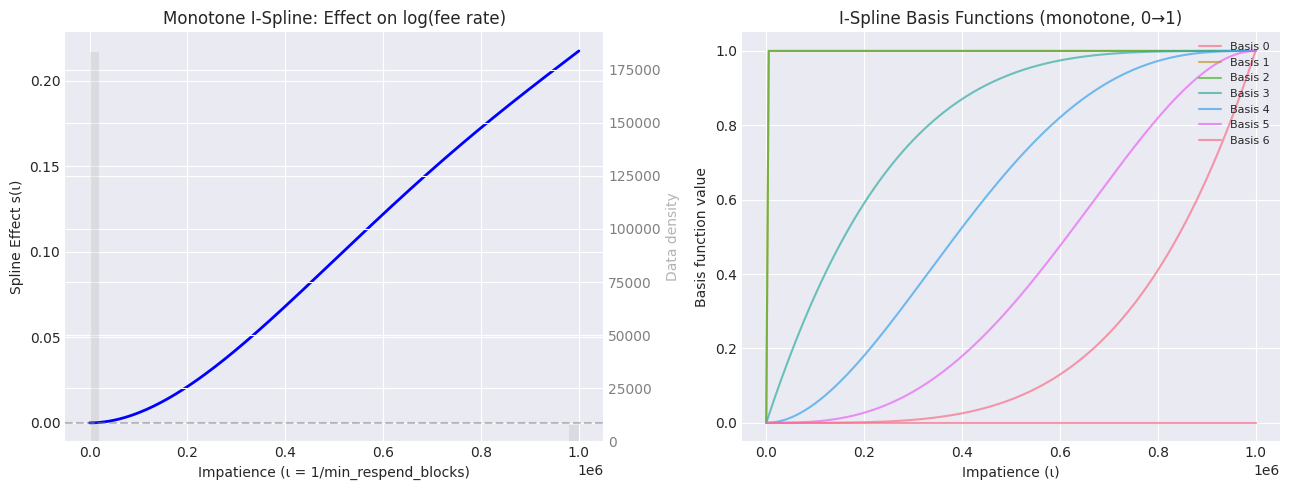


Spline effect range: [0.0000, 0.2175]


In [24]:
# =============================================================================
# Section 5.4d: Impatience Spline Diagnostics
# =============================================================================
# Visualize the fitted impatience spline effect s(ι) and its basis functions.

coef_df = stage2.get_coefficient_summary()

# Extract impatience spline coefficients (intensive margin, skip intercept row)
imp_spl_mask = coef_df['feature'].str.startswith('impatience_spl_')
imp_coefs = coef_df.loc[imp_spl_mask, 'intensive_coef'].values
imp_names = coef_df.loc[imp_spl_mask, 'feature'].values
n_imp_basis = len(imp_coefs)

imp_ext_coefs = coef_df.loc[imp_spl_mask, 'extensive_coef'].values

print(f"Impatience I-spline: {n_imp_basis} basis functions")
print(f"  Clip range: [{stage2._impatience_clip[0]:.4f}, {stage2._impatience_clip[1]:.4f}]")
print(f"\n  Coefficients (δ_ℓ ≥ 0 enforced for monotonicity):")
print(f"  {'Basis':<20s} {'h(ι) ext':>10s} {'s(ι) int':>10s}")
for name, ce, ci in zip(imp_names, imp_ext_coefs, imp_coefs):
    print(f"    {name:<18s} {ce:+.4f}     {ci:+.4f}")
all_nonneg = np.all(imp_coefs >= -1e-8) and np.all(imp_ext_coefs >= -1e-8)
print(f"\n  Monotonicity constraint satisfied: {all_nonneg}")

# Sweep impatience range through the fitted spline
iota_range = np.linspace(
    stage2._impatience_clip[0],
    stage2._impatience_clip[1],
    200
).reshape(-1, 1)
iota_basis = stage2._impatience_spline.transform(iota_range)
spline_effect = iota_basis @ imp_coefs

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1. Spline effect s(ι) on log fee rate
ax1 = axes[0]
ax1.plot(iota_range.flatten(), spline_effect, 'b-', linewidth=2)
ax1.set_xlabel('Impatience (ι = 1/min_respend_blocks)')
ax1.set_ylabel('Spline Effect s(ι)')
ax1.set_title('Monotone I-Spline: Effect on log(fee rate)')
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
# Rug / density
ax1_rug = ax1.twinx()
valid_imp = df.loc[df['impatience'].notna(), 'impatience']
ax1_rug.hist(valid_imp, bins=50, alpha=0.15, color='gray')
ax1_rug.set_ylabel('Data density', color='gray', alpha=0.6)
ax1_rug.tick_params(axis='y', labelcolor='gray')

# 2. Individual basis functions
ax2 = axes[1]
for i in range(iota_basis.shape[1]):
    ax2.plot(iota_range.flatten(), iota_basis[:, i],
             label=f'Basis {i}', alpha=0.7)
ax2.set_xlabel('Impatience (ι)')
ax2.set_ylabel('Basis function value')
ax2.set_title('I-Spline Basis Functions (monotone, 0→1)')
ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('plots/impatience_spline_effect.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSpline effect range: [{spline_effect.min():.4f}, {spline_effect.max():.4f}]")

STAGE 2: FEATURE IMPORTANCE & MULTICOLLINEARITY DIAGNOSTICS
Total features in full matrix: 245
Base features (excl. epoch FE): 25  (of which 8 blockspace + 7 impatience are spline basis functions)
Display features (splines grouped): 12

--- Standardized Coefficients (Intensive Margin) ---
                          feature  |std coef| intensive  |std coef| extensive
        log_time_since_last_block                0.4454                0.5225
blockspace_utilization (B-spline)                0.2892                0.0169
                 log_total_output                0.1719                2.6850
                         log_size                0.1124                1.8533
                  is_cpfp_package                0.0814                0.0025
                          has_rbf                0.0767                0.0001
                         log_n_in                0.0596                0.0322
            impatience (I-spline)                0.0524                0.0498
        

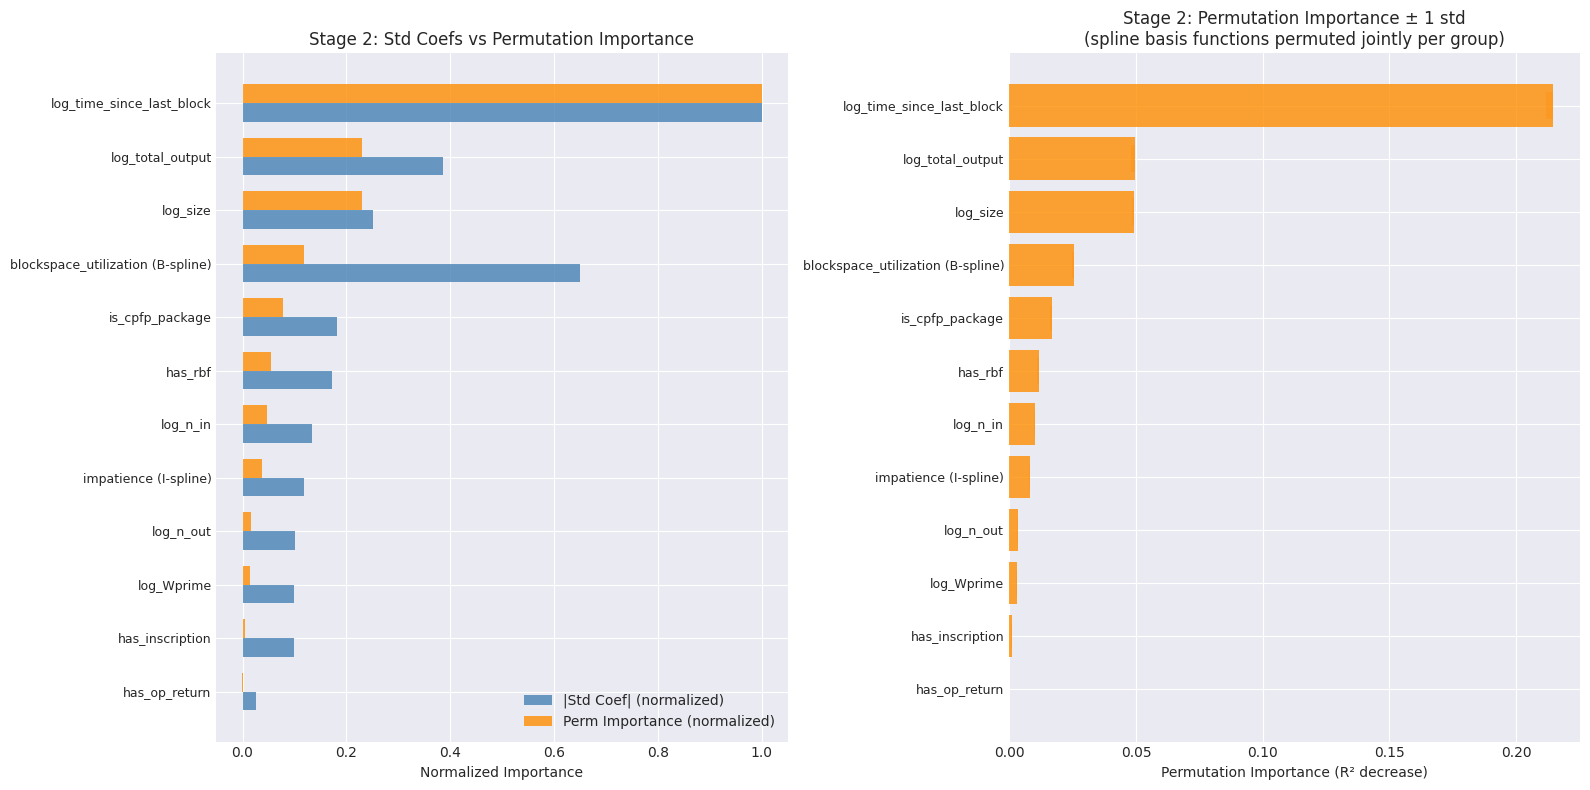


--- Variance Inflation Factors (VIF) — spline basis functions excluded ---
(Spline basis functions are collinear by construction; VIF computed on other features)
  log_Wprime               :     1.01
  has_rbf                  :     1.02
  is_cpfp_package          :     1.05
  log_total_output         :     1.40
  log_n_in                 :     1.02
  log_n_out                :     1.24
  has_op_return            :     1.17
  has_inscription          :     1.27
  log_time_since_last_block:     1.06
  log_size                 :     1.03

✓ All features have VIF < 5 — no strong multicollinearity detected.


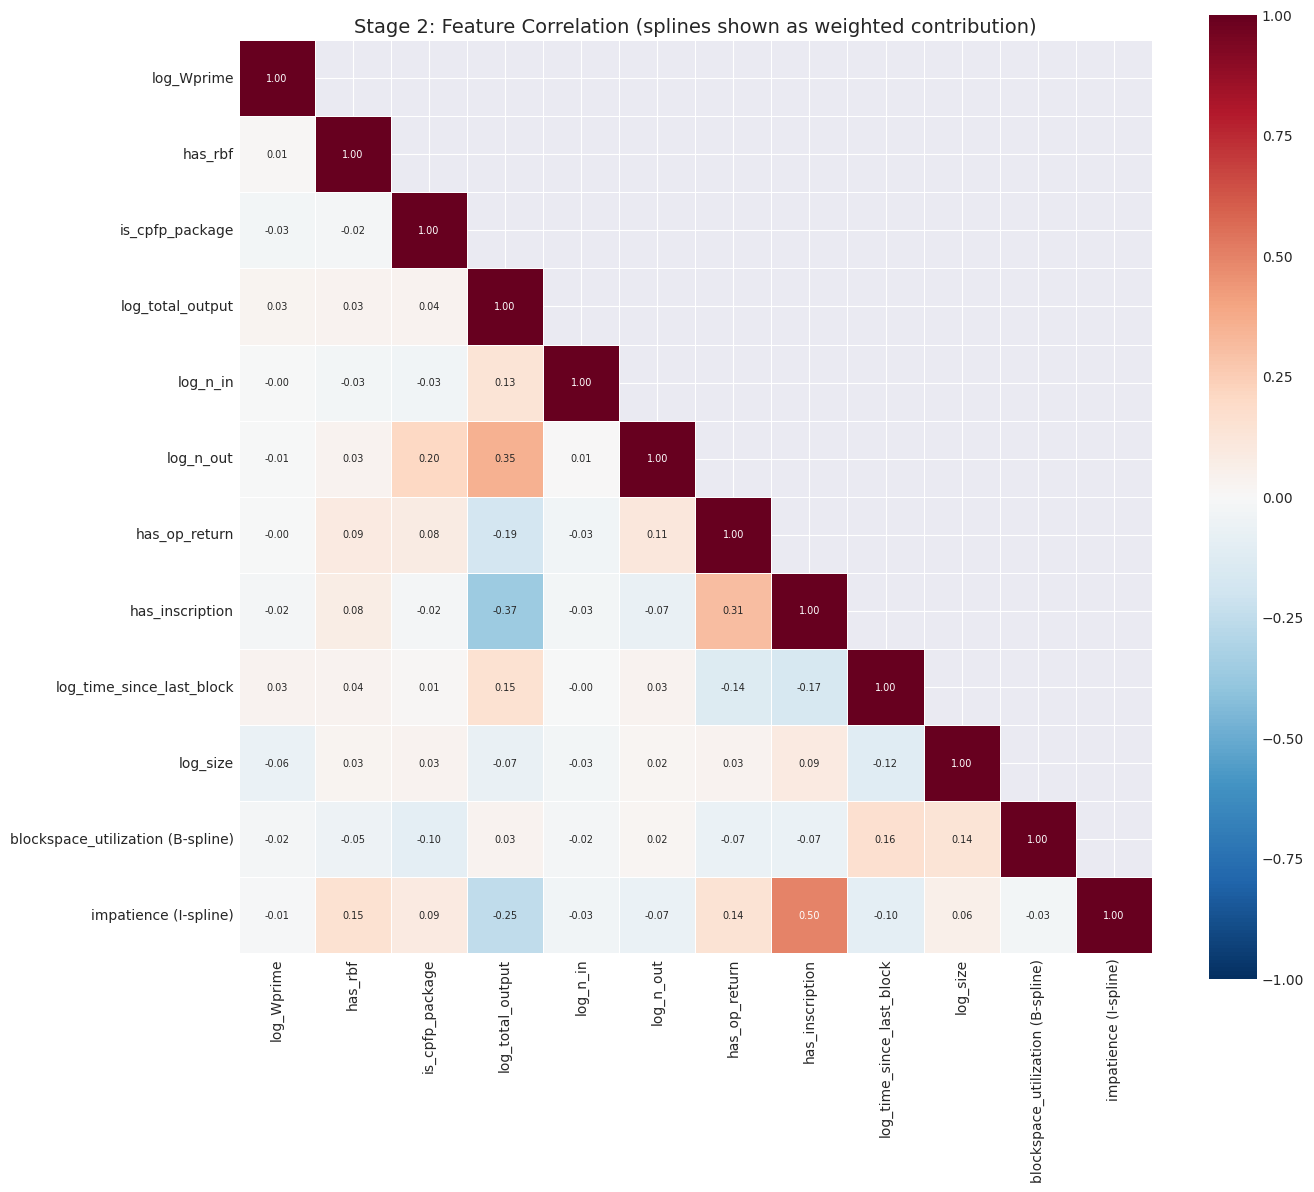

In [25]:
# =============================================================================
# Section 5.4b: Stage 2 Feature Importance & Multicollinearity Diagnostics
# =============================================================================
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("=" * 70)
print("STAGE 2: FEATURE IMPORTANCE & MULTICOLLINEARITY DIAGNOSTICS")
print("=" * 70)

# --- Build the base feature matrix (excluding epoch FE) ---
valid_mask_s2 = (
    df['log_Wprime'].notna() &
    df['fee_rate'].notna() &
    df['epoch_id'].notna()
)
df_valid_s2 = df[valid_mask_s2].copy()

X_full_s2, feat_names_full = stage2._build_feature_matrix(df_valid_s2, fit_spline=False)

# Correct n_base: all columns except epoch FE dummies
n_base = len(feat_names_full) - stage2._n_epoch_dummies
X_base_s2 = X_full_s2[:, :n_base]
base_feature_names = feat_names_full[:n_base]

# Identify spline column indices and non-spline indices
bs_idx  = [i for i, n in enumerate(base_feature_names) if n.startswith('blockspace_spl_')]
imp_idx = [i for i, n in enumerate(base_feature_names) if n.startswith('impatience_spl_')]
spline_idx = bs_idx + imp_idx
non_spline_idx = [i for i, n in enumerate(base_feature_names) if i not in spline_idx]

# Display names: collapse spline columns into one entry each
display_names = ([base_feature_names[i] for i in non_spline_idx]
                 + ['blockspace_utilization (B-spline)', 'impatience (I-spline)'])

print(f"Total features in full matrix: {X_full_s2.shape[1]}")
print(f"Base features (excl. epoch FE): {n_base}  "
      f"(of which {len(bs_idx)} blockspace + {len(imp_idx)} impatience "
      f"are spline basis functions)")
print(f"Display features (splines grouped): {len(display_names)}")

# --- Fee-payers for intensive margin analysis ---
eps = config.fee_threshold_sat_vb
payer_mask_s2 = df_valid_s2['fee_rate'] > eps
df_payers_s2  = df_valid_s2[payer_mask_s2].copy()
X_payers_full, _ = stage2._build_feature_matrix(df_payers_s2, fit_spline=False)
X_payers_base = X_payers_full[:, :n_base]
y_payers_s2   = np.log(df_payers_s2['fee_rate'].values)

int_coefs_base = stage2.int_coefs[1:n_base + 1]
ext_coefs_base = stage2.ext_coefs[1:n_base + 1]

# =====================================================================
# 1. Standardized Coefficients (grouped for blockspace)
# =====================================================================
print("\n--- Standardized Coefficients (Intensive Margin) ---")

feature_stds = np.std(X_payers_base, axis=0)
target_std   = np.std(y_payers_s2)
std_coefs_int = int_coefs_base * feature_stds / target_std
std_coefs_ext = ext_coefs_base * feature_stds

# Aggregate spline groups: sum of |std coefs| for all basis cols in each group
bs_std_agg     = np.sum(np.abs(std_coefs_int[bs_idx]))
bs_std_ext_agg = np.sum(np.abs(std_coefs_ext[bs_idx]))
imp_std_agg     = np.sum(np.abs(std_coefs_int[imp_idx]))
imp_std_ext_agg = np.sum(np.abs(std_coefs_ext[imp_idx]))

display_std_int = (list(np.abs(std_coefs_int[non_spline_idx]))
                   + [bs_std_agg, imp_std_agg])
display_std_ext = (list(np.abs(std_coefs_ext[non_spline_idx]))
                   + [bs_std_ext_agg, imp_std_ext_agg])

std_coef_df = pd.DataFrame({
    'feature': display_names,
    '|std coef| intensive': display_std_int,
    '|std coef| extensive': display_std_ext,
}).sort_values('|std coef| intensive', ascending=False)
print(std_coef_df.to_string(index=False))

# =====================================================================
# 2. Grouped Permutation Importance (blockspace cols permuted together)
# =====================================================================
print("\n--- Permutation Importance (blockspace columns permuted as a group) ---")

rng = np.random.RandomState(42)
subsample_size = min(50000, len(X_payers_base))
sub_idx = rng.choice(len(X_payers_base), size=subsample_size, replace=False)
X_perm_sample = X_payers_base[sub_idx]
y_perm_sample = y_payers_s2[sub_idx]

def _predict_base(X):
    return np.hstack([np.ones((X.shape[0], 1)), X]) @ stage2.int_coefs[:n_base + 1]

baseline_r2 = r2_score(y_perm_sample, _predict_base(X_perm_sample))

def _grouped_perm_importance(X, y, groups, n_repeats=10):
    results = {}
    for name, cols in groups.items():
        drops = []
        for _ in range(n_repeats):
            X_p = X.copy()
            perm = rng.permutation(len(X))
            X_p[:, cols] = X[perm][:, cols]
            drops.append(baseline_r2 - r2_score(y, _predict_base(X_p)))
        results[name] = (np.mean(drops), np.std(drops))
    return results

# Build groups: each non-spline feature individually + spline groups
groups = {base_feature_names[i]: [i] for i in non_spline_idx}
groups['blockspace_utilization (B-spline)'] = bs_idx
groups['impatience (I-spline)'] = imp_idx

perm_results = _grouped_perm_importance(X_perm_sample, y_perm_sample, groups)

perm_df_s2 = pd.DataFrame([
    {'feature': name, 'Perm Importance (mean)': m, 'Perm Importance (std)': s}
    for name, (m, s) in perm_results.items()
]).sort_values('Perm Importance (mean)', ascending=False)

print(perm_df_s2.to_string(index=False))

# =====================================================================
# 3. Visualization
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

plot_df_s2 = perm_df_s2.sort_values('Perm Importance (mean)', ascending=True)
y_pos = np.arange(len(plot_df_s2))
bar_height = 0.35

# Merge std coef for display order
std_map = dict(zip(display_names, display_std_int))
plot_df_s2['std_coef'] = plot_df_s2['feature'].map(std_map).fillna(0)

max_std  = plot_df_s2['std_coef'].max()
max_perm = plot_df_s2['Perm Importance (mean)'].max()

axes[0].barh(y_pos - bar_height/2, plot_df_s2['std_coef'].values / max_std, bar_height,
             label='|Std Coef| (normalized)', alpha=0.8, color='steelblue')
axes[0].barh(y_pos + bar_height/2, plot_df_s2['Perm Importance (mean)'].values / max_perm, bar_height,
             label='Perm Importance (normalized)', alpha=0.8, color='darkorange')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(plot_df_s2['feature'].values, fontsize=9)
axes[0].set_xlabel('Normalized Importance')
axes[0].set_title('Stage 2: Std Coefs vs Permutation Importance')
axes[0].legend(loc='lower right')

axes[1].barh(y_pos, plot_df_s2['Perm Importance (mean)'].values, color='darkorange', alpha=0.8)
axes[1].barh(y_pos, plot_df_s2['Perm Importance (std)'].values,
             left=plot_df_s2['Perm Importance (mean)'].values - plot_df_s2['Perm Importance (std)'].values,
             height=0.5, color='darkorange', alpha=0.3)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(plot_df_s2['feature'].values, fontsize=9)
axes[1].set_xlabel('Permutation Importance (R² decrease)')
axes[1].set_title('Stage 2: Permutation Importance ± 1 std\n(spline basis functions permuted jointly per group)')

plt.tight_layout()
plt.savefig('/home/kristian/notebooks/plots/stage2_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# =====================================================================
# 4. VIF — exclude spline basis functions (inherently collinear by design)
# =====================================================================
print("\n--- Variance Inflation Factors (VIF) — spline basis functions excluded ---")
print("(Spline basis functions are collinear by construction; VIF computed on other features)")

vif_idx  = non_spline_idx
vif_names = [base_feature_names[i] for i in vif_idx]
X_vif    = X_base_s2[:, vif_idx]

X_vif_df = pd.DataFrame(X_vif, columns=vif_names)
X_vif_with_const = X_vif_df.copy()
X_vif_with_const.insert(0, 'const', 1.0)

vif_data_s2 = []
for i, feat in enumerate(vif_names):
    vif_val = variance_inflation_factor(X_vif_with_const.values, i + 1)
    flag = " ⚠ HIGH" if vif_val > 10 else (" ⚡ MODERATE" if vif_val > 5 else "")
    vif_data_s2.append({'Feature': feat, 'VIF': vif_val, 'Flag': flag})
    print(f"  {feat:25s}: {vif_val:8.2f}{flag}")

vif_df_s2 = pd.DataFrame(vif_data_s2)
high_vif = vif_df_s2[vif_df_s2['VIF'] > 5]
if len(high_vif) > 0:
    print(f"\n⚠ {len(high_vif)} feature(s) with VIF > 5:")
    print(high_vif[['Feature', 'VIF']].to_string(index=False))
else:
    print("\n✓ All features have VIF < 5 — no strong multicollinearity detected.")

# =====================================================================
# 5. Correlation heatmap (spline cols collapsed to weighted contribution)
# =====================================================================
bs_contrib  = X_base_s2[:, bs_idx]  @ int_coefs_base[bs_idx]
imp_contrib = X_base_s2[:, imp_idx] @ int_coefs_base[imp_idx]
X_display  = np.hstack([X_base_s2[:, non_spline_idx],
                         bs_contrib.reshape(-1, 1),
                         imp_contrib.reshape(-1, 1)])
X_display_df = pd.DataFrame(X_display, columns=display_names)
corr_matrix_s2 = X_display_df.corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask_s2 = np.triu(np.ones_like(corr_matrix_s2, dtype=bool), k=1)
sns.heatmap(corr_matrix_s2, mask=mask_s2, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            ax=ax, annot_kws={'size': 7})
ax.set_title('Stage 2: Feature Correlation (splines shown as weighted contribution)', fontsize=14)
plt.tight_layout()
plt.savefig('/home/kristian/notebooks/plots/stage2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 6: Main Pipeline - BitcoinFeeEstimator

The main orchestrator class that combines Stage 1 and Stage 2 into a complete pipeline.

In [26]:

# =============================================================================
# Section 6.1: BitcoinFeeEstimator Class
# =============================================================================

class BitcoinFeeEstimator:
    """
    Main orchestrator for the two-stage fee estimation pipeline.
    
    Combines:
    - Data preparation
    - Stage 1: Delay technology estimation
    - Stage 2: Hurdle fee model
    
    Attributes:
        config: EstimationConfig object
        stage1: DelayTechnologyEstimator
        stage2: HurdleFeeModel
        df_prepared: Prepared DataFrame
    """
    
    def __init__(self, config: Optional[EstimationConfig] = None,
                 use_isotonic: bool = False):
        """
        Initialize the estimator.
        
        Args:
            config: EstimationConfig object (uses defaults if None)
            use_isotonic: If True, enforce per-epoch monotonicity via isotonic
                          regression before computing finite-difference slopes.
                          If False (default), use raw RF predictions directly —
                          avoids flat-plateau artefacts that spike log(W') at -13.8.
        """
        self.config = config or EstimationConfig()
        self.use_isotonic = use_isotonic
        self.stage1 = None
        self.stage2 = None
        self.df_prepared = None
        self._is_fitted = False

    def _compute_wprime(self, df: pd.DataFrame, W_hat: np.ndarray,
                        verbose: bool = True) -> tuple:
        """
        Compute W' (finite-difference slopes), optionally via isotonic smoothing.
        Returns (W_for_diff, Wprime_hat).
        """
        if self.use_isotonic:
            if verbose:
                print("  Enforcing monotonicity via per-epoch isotonic regression...")
            W_for_diff = self.stage1.predict_delay_monotone_per_obs(df, W_hat, verbose=False)
        else:
            if verbose:
                print("  Skipping isotonic — using raw W_hat for finite differences")
            W_for_diff = W_hat

        Wprime_hat = self.stage1.compute_slope_finite_diff_per_obs(
            df, W_for_diff, delta=0.05, verbose=False
        )
        return W_for_diff, Wprime_hat
    
    def fit(self, df: pd.DataFrame) -> 'BitcoinFeeEstimator':
        """
        Fit the complete two-stage model.
        
        Args:
            df: Raw transaction DataFrame
            
        Returns:
            self
        """
        print("\n" + "=" * 60)
        print("BITCOIN FEE ESTIMATION PIPELINE")
        print(f"  use_isotonic = {self.use_isotonic}")
        print("=" * 60)
        
        # Step 1: Prepare features
        print("\n[1/4] Preparing features...")
        self.df_prepared = prepare_features(df.copy(), self.config)
        
        # Step 2: Fit Stage 1
        print("\n[2/4] Fitting Stage 1 (Delay Technology)...")
        self.stage1 = DelayTechnologyEstimator(self.config)
        self.stage1.fit(self.df_prepared)
        
        # Step 3: Compute Stage 1 outputs
        print("\n[3/4] Computing Stage 1 outputs...")
        W_hat = self.stage1.predict_W_hat(self.df_prepared)
        W_for_diff, Wprime_hat = self._compute_wprime(self.df_prepared, W_hat)
        
        self.df_prepared['W_hat'] = np.nan
        self.df_prepared['W_monotone'] = np.nan
        self.df_prepared['Wprime_hat'] = np.nan
        self.df_prepared.loc[self.stage1._valid_indices, 'W_hat'] = W_hat
        self.df_prepared.loc[self.stage1._valid_indices, 'W_monotone'] = W_for_diff
        self.df_prepared.loc[self.stage1._valid_indices, 'Wprime_hat'] = Wprime_hat
        self.df_prepared['log_Wprime'] = np.log(self.df_prepared['Wprime_hat'].clip(lower=1e-6))
        
        # Step 4: Fit Stage 2
        print("\n[4/4] Fitting Stage 2 (Hurdle Fee Model)...")
        self.stage2 = HurdleFeeModel(self.config)
        self.stage2.fit(self.df_prepared)
        
        self._is_fitted = True
        
        print("\n" + "=" * 60)
        print("PIPELINE FITTING COMPLETE")
        print("=" * 60)
        
        return self
    
    def predict(self, df: Optional[pd.DataFrame] = None) -> pd.DataFrame:
        """
        Generate predictions.
        
        Args:
            df: DataFrame to predict on (uses training data if None)
            
        Returns:
            DataFrame with predictions
        """
        if not self._is_fitted:
            raise RuntimeError("Model must be fitted before prediction")
        
        if df is None:
            df = self.df_prepared
        else:
            df = prepare_features(df.copy(), self.config)
            
            W_hat = self.stage1.predict_W_hat(df)
            W_for_diff, Wprime_hat = self._compute_wprime(df, W_hat, verbose=False)
            
            df['W_hat'] = np.nan
            df['W_monotone'] = np.nan
            df['Wprime_hat'] = np.nan
            df.loc[self.stage1._valid_indices, 'W_hat'] = W_hat
            df.loc[self.stage1._valid_indices, 'W_monotone'] = W_for_diff
            df.loc[self.stage1._valid_indices, 'Wprime_hat'] = Wprime_hat
            df['log_Wprime'] = np.log(df['Wprime_hat'].clip(lower=1e-6))
        
        valid_mask = df['log_Wprime'].notna()
        df_valid = df[valid_mask].copy()
        
        results = pd.DataFrame({
            'tx_id':             df_valid['tx_id'],
            'actual_fee_rate':   df_valid['fee_rate'],
            'W_hat':             df_valid['W_hat'],
            'Wprime_hat':        df_valid['Wprime_hat'],
            'log_fee_hat':       self.stage2.predict_conditional_log_fee(df_valid),
            'fee_hat':           self.stage2.predict_conditional_fee(df_valid),
        })
        
        return results
    
    def summary(self) -> Dict[str, Any]:
        """Get summary statistics of the fitted model."""
        if not self._is_fitted:
            raise RuntimeError("Model must be fitted before getting summary")
        
        return {
            'config': {
                'epoch_duration_minutes': self.config.epoch_duration_minutes,
                'n_folds': self.config.n_folds,
            },
            'use_isotonic': self.use_isotonic,
            'data': {
                'n_observations': len(self.df_prepared),
                'n_epochs': self.df_prepared['epoch_id'].nunique(),
                'time_range': (
                    str(self.df_prepared['found_at'].min()),
                    str(self.df_prepared['found_at'].max())
                )
            },
            'stage1': {
                'model_type': 'RandomForest',
                'n_valid': len(self.stage1._valid_indices)
            },
            'stage2': {
                'smearing_factor': self.stage2.smearing_factor,
                'n_features': len(self.stage2._feature_names)
            }
        }
    
    def save(self, path: str) -> None:
        """Save the fitted model to disk."""
        if not self._is_fitted:
            raise RuntimeError("Model must be fitted before saving")
        
        joblib.dump({
            'config': self.config,
            'use_isotonic': self.use_isotonic,
            'stage1': self.stage1,
            'stage2': self.stage2
        }, path)
        print(f"Model saved to {path}")
    
    @classmethod
    def load(cls, path: str) -> 'BitcoinFeeEstimator':
        """Load a fitted model from disk."""
        data = joblib.load(path)
        
        estimator = cls(data['config'], use_isotonic=data.get('use_isotonic', True))
        estimator.stage1 = data['stage1']
        estimator.stage2 = data['stage2']
        estimator._is_fitted = True
        
        print(f"Model loaded from {path}")
        return estimator

print("BitcoinFeeEstimator class defined")


BitcoinFeeEstimator class defined


In [27]:
# =============================================================================
# Section 6.2: Run Complete Pipeline
# =============================================================================
# Note: We've already fitted stage1 and stage2 separately above
# This cell demonstrates how to use the unified interface

# Create a new estimator from the already fitted components
estimator = BitcoinFeeEstimator(config)
estimator.stage1 = stage1
estimator.stage2 = stage2
estimator.df_prepared = df
estimator._is_fitted = True

# Get predictions
predictions = estimator.predict()

print("\nPrediction Sample:")
print(predictions.head(10))

# Get summary
summary = estimator.summary()
print("\nModel Summary:")
for section, values in summary.items():
    print(f"\n{section}:")
    if isinstance(values, dict):
        for k, v in values.items():
            print(f"  {k}: {v}")


Prediction Sample:
                                                    tx_id  actual_fee_rate  \
172175  5d1630fea3b7bbeaa83205957422f9987453145b7c6f95...           2.7500   
172176  29da4e085d1a280fcae78f3c25c9549700ed1a006f9e65...           1.0033   
172139  a05eee4b0ff20f6199b244b32bc9c3bfd99aecadf88bd3...           2.6169   
172140  cc97189285916b06766e73b9db22a026f702910283cc9d...           1.6759   
172141  af60c40fe7e6e5e950b8558d7190e4af3a809ed20b85d8...           1.0004   
172143  59bc60f24a3bcb314440ea1d8a2c95ffbe55149c837055...           9.7087   
172145  a8e3869e4f0bb7a35a68b60462851e917c1a9e3d16b52b...           1.3860   
172146  b426d9acad0f740a1c94f46345736feb0054cb71bd2fce...           1.0047   
172147  98592085c6c39eb0cfc011b6d551b2e0d5606212a41e5e...           4.7603   
172148  7531e2095a92f26a6dff80bbe8097f091d82d4a5db7adc...           1.5029   

        W_hat  Wprime_hat  log_fee_hat  fee_hat  
172175 5.7345      0.0000       0.7085   2.7678  
172176 5.8546      0.

---
## Section 7: Diagnostics and Validation

This section includes:
- Clustered standard errors (Liang-Zeger sandwich estimator)
- Diagnostic visualizations
- Model validation plots

In [28]:
# =============================================================================
# Section 7.1: Clustered Standard Errors
# =============================================================================

def compute_clustered_se(X: np.ndarray, residuals: np.ndarray,
                         cluster_ids: np.ndarray):
    """
    Compute Liang-Zeger cluster-robust standard errors.

    Returns
    -------
    se : ndarray  (p,)  — standard errors (NaN for degenerate columns)
    V  : ndarray  (p,p) — full sandwich covariance matrix
    """
    n, p = X.shape
    col_var = np.var(X, axis=0)
    degenerate = col_var < 1e-12

    XtX_inv = np.linalg.pinv(X.T @ X)

    unique_clusters = np.unique(cluster_ids)
    n_clusters = len(unique_clusters)

    meat = np.zeros((p, p))
    for c in unique_clusters:
        mask = cluster_ids == c
        score_c = X[mask].T @ residuals[mask]
        meat += np.outer(score_c, score_c)

    adjustment = (n_clusters / (n_clusters - 1)) * ((n - 1) / (n - p))
    V = XtX_inv @ (adjustment * meat) @ XtX_inv

    diag_V = np.diag(V)
    se = np.where(diag_V > 0, np.sqrt(diag_V), np.nan)
    se[degenerate] = np.nan

    return se, V


def compute_intensive_margin_se(stage2: HurdleFeeModel, df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute clustered SEs for the intensive margin.

    The blockspace spline basis functions are aggregated into a single row
    via the delta method: the quantity reported is the predicted change in
    log(fee_rate) when blockspace_utilization moves from its p50 to p95 in
    the sample, with SE computed as sqrt(d' V_spl d).
    """
    print("Computing clustered standard errors for intensive margin...")

    eps = stage2.config.fee_threshold_sat_vb
    valid_mask = (
        df['log_Wprime'].notna() &
        df['fee_rate'].notna() &
        (df['fee_rate'] > eps)
    )
    df_payers = df[valid_mask].copy()

    X_base, feature_names = stage2._build_feature_matrix(df_payers, fit_spline=False)
    X = np.hstack([np.ones((len(df_payers), 1)), X_base])

    y = np.log(df_payers['fee_rate'].values)
    y_pred = X @ stage2.int_coefs
    residuals = y - y_pred

    cluster_ids = df_payers['epoch_id'].values
    se_clustered, V = compute_clustered_se(X, residuals, cluster_ids)

    unique_clusters = np.unique(cluster_ids)
    n_clusters = len(unique_clusters)

    # Naive SEs for inflation reporting
    n = len(y)
    sigma2 = np.sum(residuals ** 2) / (n - X.shape[1])
    XtX_inv = np.linalg.pinv(X.T @ X)
    diag_ols = sigma2 * np.diag(XtX_inv)
    se_naive = np.where(diag_ols > 0, np.sqrt(diag_ols), np.nan)

    from scipy import stats as sp_stats

    names = ['intercept'] + feature_names
    coefs = stage2.int_coefs
    df_dof = n_clusters - 1
    t_vals = np.where(np.isnan(se_clustered), np.nan, coefs / se_clustered)
    p_vals = np.where(np.isnan(t_vals), np.nan,
                      2 * sp_stats.t.sf(np.abs(t_vals), df=df_dof))
    ci_crit = sp_stats.t.ppf(0.975, df=df_dof)

    def sig_stars(p):
        if np.isnan(p): return ''
        if p < 0.001: return '***'
        if p < 0.01:  return '**'
        if p < 0.05:  return '*'
        if p < 0.1:   return '.'
        return ''

    summary = pd.DataFrame({
        'feature':      names,
        'coef':         coefs,
        'se_clustered': se_clustered,
        't_stat':       t_vals,
        'p_value':      p_vals,
        'ci_lower':     coefs - ci_crit * se_clustered,
        'ci_upper':     coefs + ci_crit * se_clustered,
        'sig':          [sig_stars(p) for p in p_vals],
    })

    # ----------------------------------------------------------------
    # Aggregate blockspace spline via delta method
    # Contrast: predicted Δlog(fee) for blockspace p50 → p95
    # ----------------------------------------------------------------
    spl_feat_idx = [i for i, nm in enumerate(feature_names) if nm.startswith('blockspace_spl_')]
    if spl_feat_idx and stage2._blockspace_spline is not None:
        bs_p50 = np.percentile(df_payers['blockspace_utilization'], 50)
        bs_p95 = np.percentile(df_payers['blockspace_utilization'], 95)

        X_lo = stage2._blockspace_spline.transform([[bs_p50]])
        X_hi = stage2._blockspace_spline.transform([[bs_p95]])
        d = (X_hi - X_lo).ravel()                      # shape: (n_spl,)

        # Coefficient indices in the full vector (intercept at 0)
        spl_coef_idx = [i + 1 for i in spl_feat_idx]

        partial_effect = float(d @ coefs[spl_coef_idx])
        V_spl = V[np.ix_(spl_coef_idx, spl_coef_idx)]
        partial_var = float(d @ V_spl @ d)
        partial_se  = np.sqrt(max(partial_var, 0))

        t_agg = partial_effect / partial_se if partial_se > 0 else np.nan
        p_agg = float(2 * sp_stats.t.sf(abs(t_agg), df=df_dof)) if not np.isnan(t_agg) else np.nan

        agg_row = {
            'feature':      f'blockspace_util (spline Δ p50={bs_p50:.2f}→p95={bs_p95:.2f})',
            'coef':         partial_effect,
            'se_clustered': partial_se,
            't_stat':       t_agg,
            'p_value':      p_agg,
            'ci_lower':     partial_effect - ci_crit * partial_se,
            'ci_upper':     partial_effect + ci_crit * partial_se,
            'sig':          sig_stars(p_agg),
        }
        summary = pd.concat(
            [summary[~summary['feature'].str.startswith('blockspace_spl_')],
             pd.DataFrame([agg_row])],
            ignore_index=True,
        )
        print(f"  Blockspace spline aggregated: Δlog(fee) at "
              f"p50={bs_p50:.2f}→p95={bs_p95:.2f} = {partial_effect:.4f} "
              f"(SE={partial_se:.4f}, p={p_agg:.4f})")

    # ----------------------------------------------------------------
    # Aggregate impatience I-spline via delta method
    # Contrast: predicted Δlog(fee) for impatience p50 → p95
    # ----------------------------------------------------------------
    imp_feat_idx = [i for i, nm in enumerate(feature_names) if nm.startswith('impatience_spl_')]
    if imp_feat_idx and stage2._impatience_spline is not None:
        imp_vals = df_payers['impatience'].clip(*stage2._impatience_clip)
        imp_p50 = float(np.percentile(imp_vals, 50))
        imp_p95 = float(np.percentile(imp_vals, 95))

        X_lo = stage2._impatience_spline.transform([[imp_p50]])
        X_hi = stage2._impatience_spline.transform([[imp_p95]])
        d = (X_hi - X_lo).ravel()

        imp_coef_idx = [i + 1 for i in imp_feat_idx]

        partial_effect = float(d @ coefs[imp_coef_idx])
        V_imp = V[np.ix_(imp_coef_idx, imp_coef_idx)]
        partial_var = float(d @ V_imp @ d)
        partial_se  = np.sqrt(max(partial_var, 0))

        t_agg = partial_effect / partial_se if partial_se > 0 else np.nan
        p_agg = float(2 * sp_stats.t.sf(abs(t_agg), df=df_dof)) if not np.isnan(t_agg) else np.nan

        agg_row = {
            'feature':      f'impatience (I-spline Δ p50={imp_p50:.4g}→p95={imp_p95:.4g})',
            'coef':         partial_effect,
            'se_clustered': partial_se,
            't_stat':       t_agg,
            'p_value':      p_agg,
            'ci_lower':     partial_effect - ci_crit * partial_se,
            'ci_upper':     partial_effect + ci_crit * partial_se,
            'sig':          sig_stars(p_agg),
        }
        summary = pd.concat(
            [summary[~summary['feature'].str.startswith('impatience_spl_')],
             pd.DataFrame([agg_row])],
            ignore_index=True,
        )
        print(f"  Impatience I-spline aggregated: Δlog(fee) at "
              f"p50={imp_p50:.4g}→p95={imp_p95:.4g} = {partial_effect:.4f} "
              f"(SE={partial_se:.4f}, p={p_agg:.4f})")

    # ----------------------------------------------------------------
    # Diagnostics
    # ----------------------------------------------------------------
    n_degenerate = int(np.sum(np.isnan(se_clustered)))
    valid_se = ~np.isnan(se_clustered) & ~np.isnan(se_naive) & (se_naive > 0)

    print(f"✓ Computed standard errors")
    print(f"  Number of clusters (epochs): {n_clusters}")
    print(f"  Degrees of freedom: {df_dof}")
    if n_degenerate > 0:
        degen_names = [names[i] for i in range(len(names)) if np.isnan(se_clustered[i])]
        print(f"  ⚠ {n_degenerate} feature(s) with degenerate SEs:")
        for dn in degen_names:
            print(f"    - {dn}")
    inflation = se_clustered[valid_se] / se_naive[valid_se]
    if len(inflation) > 0:
        print(f"  Mean SE inflation (clustered / naive): {inflation.mean():.2f}x")

    return summary


# Compute clustered standard errors
se_summary = compute_intensive_margin_se(stage2, df)

# base_summary: exclude intercept, epoch FE, and raw spline cols
# (raw spline cols were already replaced by the aggregate row above)
base_summary = se_summary[
    (se_summary['feature'] != 'intercept') &
    ~se_summary['feature'].str.startswith('epoch_') &
    ~se_summary['feature'].str.startswith('blockspace_spl_')
].copy()

print("\nIntensive Margin — Clustered Inference (base features):")
print(base_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\nSignificance: *** p<0.001, ** p<0.01, * p<0.05, . p<0.1")


Computing clustered standard errors for intensive margin...
  Blockspace spline aggregated: Δlog(fee) at p50=0.42→p95=0.92 = 0.1501 (SE=0.0265, p=0.0000)


AttributeError: 'list' object has no attribute 'ravel'

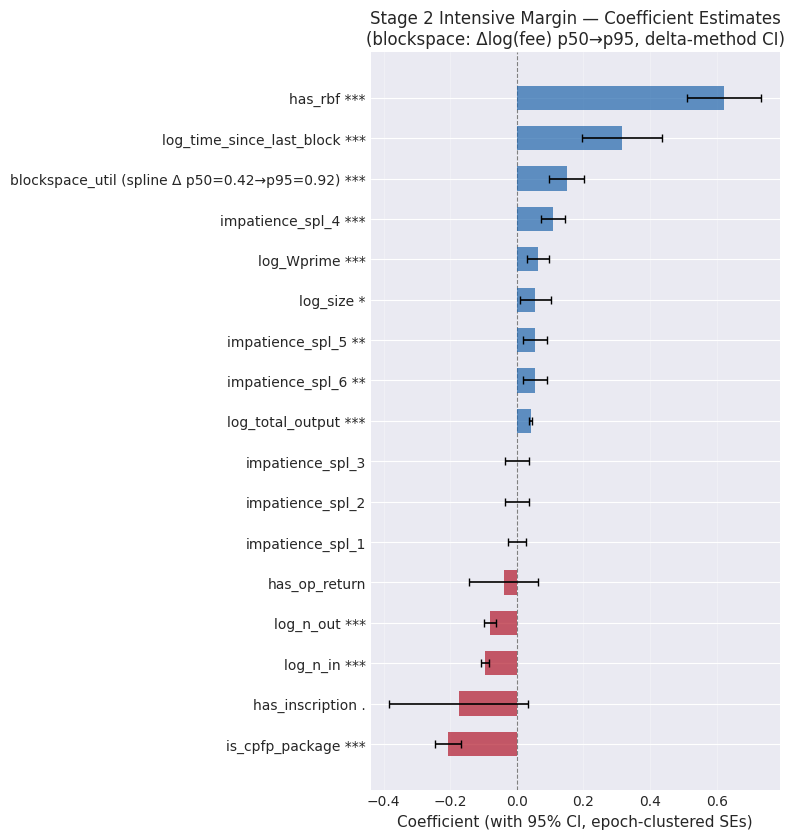

In [ ]:
# =============================================================================
# Section 7.1b: Coefficient Confidence Interval Plot
# =============================================================================
# base_summary has blockspace + impatience aggregated into delta-method rows
# and epoch FE / intercept excluded — plot it directly.

plot_df = base_summary[base_summary['se_clustered'].notna()].copy()
plot_df = plot_df.sort_values('coef', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, max(5, 0.5 * len(plot_df))))

y_pos = np.arange(len(plot_df))
colors = ['#2166ac' if c > 0 else '#b2182b' for c in plot_df['coef']]

ax.barh(y_pos, plot_df['coef'], height=0.6, color=colors, alpha=0.7, zorder=2)
ax.errorbar(plot_df['coef'], y_pos,
            xerr=np.vstack([
                plot_df['coef'] - plot_df['ci_lower'],
                plot_df['ci_upper'] - plot_df['coef'],
            ]),
            fmt='none', ecolor='black', elinewidth=1.2, capsize=3, zorder=3)

ax.axvline(0, color='grey', linewidth=0.8, linestyle='--', zorder=1)

labels = []
for _, row in plot_df.iterrows():
    name = row['feature']
    stars = row['sig']
    labels.append(f"{name} {stars}" if stars else name)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Coefficient (with 95% CI, epoch-clustered SEs)', fontsize=11)
ax.set_title(
    'Stage 2 Intensive Margin — Coefficient Estimates\n'
    '(blockspace: Δlog(fee) p50→p95, delta-method CI)',
    fontsize=12,
)
ax.grid(axis='x', alpha=0.3)

fig.tight_layout()
plt.savefig('plots/stage2_coefficient_ci.png', dpi=150, bbox_inches='tight')
plt.show()


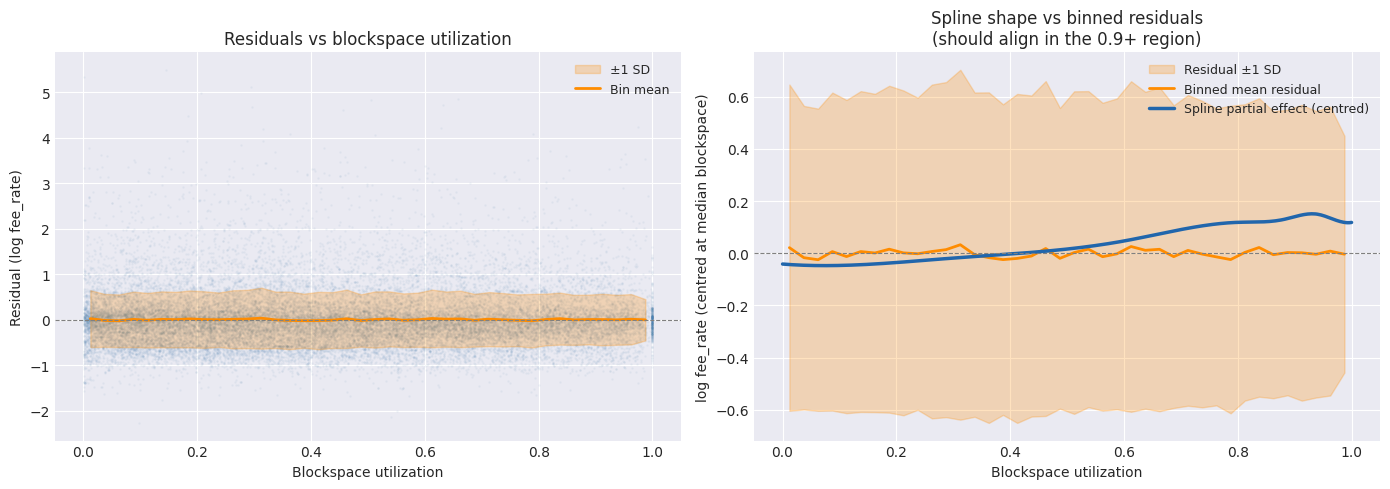

In [ ]:
# =============================================================================
# Section 7.1c: Blockspace Spline Shape vs Residuals
# =============================================================================
# Overlay the fitted spline partial effect on the binned mean residuals so
# we can check whether the spline shape lines up with the data.

# --- 1. Residuals for fee-payers ----------------------------------------
eps_bs = config.fee_threshold_sat_vb
_payer_mask = (
    df['log_Wprime'].notna() &
    df['fee_rate'].notna() &
    (df['fee_rate'] > eps_bs)
)
_df_p = df[_payer_mask].copy()

_X_base, _feat_names = stage2._build_feature_matrix(_df_p, fit_spline=False)
_X = np.hstack([np.ones((len(_df_p), 1)), _X_base])
_resid = np.log(_df_p['fee_rate'].values) - _X @ stage2.int_coefs
_df_p['_resid'] = _resid

# --- 2. Binned mean residual ± 1 SD ------------------------------------
n_bins = 40
_df_p['_bs_bin'] = pd.cut(_df_p['blockspace_utilization'], bins=n_bins)
_binned = _df_p.groupby('_bs_bin', observed=True)['_resid'].agg(['mean', 'std', 'count'])
_binned['se'] = _binned['std'] / np.sqrt(_binned['count'])
_bin_centers = _binned.index.map(lambda iv: iv.mid).astype(float)

# --- 3. Fitted spline partial effect (relative to median) ---------------
_bs_grid = np.linspace(
    _df_p['blockspace_utilization'].min(),
    _df_p['blockspace_utilization'].max(),
    300,
)
_spl_basis_grid = stage2._blockspace_spline.transform(_bs_grid.reshape(-1, 1))

# Identify spline coefficient indices (offset +1 for intercept)
_spl_feat_idx = [i for i, nm in enumerate(_feat_names) if nm.startswith('blockspace_spl_')]
_spl_coef_idx = [i + 1 for i in _spl_feat_idx]
_spl_effect_grid = _spl_basis_grid @ stage2.int_coefs[_spl_coef_idx]

# Centre at median blockspace so the two curves share the same baseline
_bs_median = _df_p['blockspace_utilization'].median()
_spl_basis_med = stage2._blockspace_spline.transform([[_bs_median]])
_spl_effect_median = (_spl_basis_med @ stage2.int_coefs[_spl_coef_idx]).item()
_spl_effect_centred = _spl_effect_grid - _spl_effect_median

# --- 4. Plot ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw scatter + binned mean
ax = axes[0]
sample_plot = _df_p.sample(min(30_000, len(_df_p)), random_state=42)
ax.scatter(sample_plot['blockspace_utilization'], sample_plot['_resid'],
           alpha=0.04, s=1, color='steelblue', rasterized=True)
ax.fill_between(_bin_centers,
                _binned['mean'] - _binned['std'],
                _binned['mean'] + _binned['std'],
                alpha=0.25, color='darkorange', label='±1 SD')
ax.plot(_bin_centers, _binned['mean'], color='darkorange', lw=2, label='Bin mean')
ax.axhline(0, color='grey', lw=0.8, linestyle='--')
ax.set_xlabel('Blockspace utilization')
ax.set_ylabel('Residual (log fee_rate)')
ax.set_title('Residuals vs blockspace utilization')
ax.legend(fontsize=9)

# Right: binned residuals vs centred spline effect
ax = axes[1]
ax.fill_between(_bin_centers,
                _binned['mean'] - _binned['std'],
                _binned['mean'] + _binned['std'],
                alpha=0.25, color='darkorange', label='Residual ±1 SD')
ax.plot(_bin_centers, _binned['mean'], color='darkorange', lw=2, label='Binned mean residual')
ax.plot(_bs_grid, _spl_effect_centred, color='#2166ac', lw=2.5, label='Spline partial effect (centred)')
ax.axhline(0, color='grey', lw=0.8, linestyle='--')
ax.set_xlabel('Blockspace utilization')
ax.set_ylabel('log fee_rate (centred at median blockspace)')
ax.set_title('Spline shape vs binned residuals\n(should align in the 0.9+ region)')
ax.legend(fontsize=9)

fig.tight_layout()
plt.savefig('plots/blockspace_spline_vs_residuals.png', dpi=150, bbox_inches='tight')
plt.show()


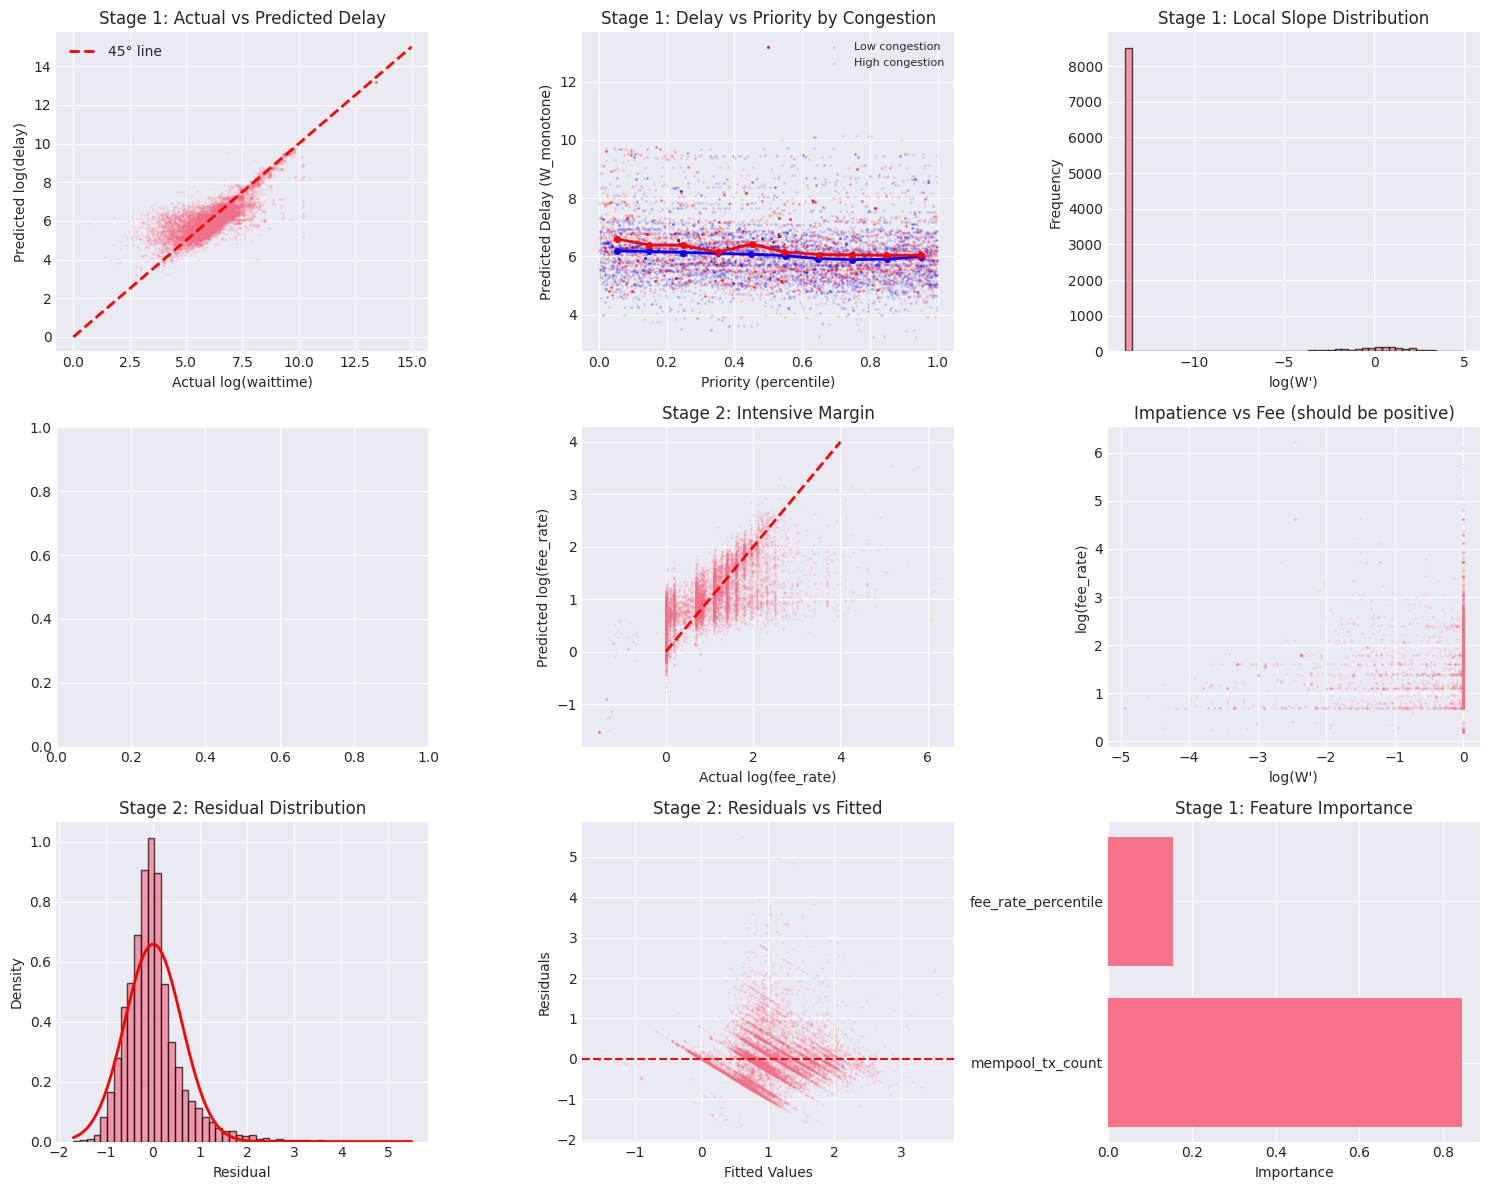


Diagnostic plot saved to: /home/kristian/notebooks/plots/fee_estimation_diagnostics.png


In [ ]:
# =============================================================================
# Section 7.2: Diagnostic Visualizations
# =============================================================================

def plot_diagnostics(df: pd.DataFrame, stage1: DelayTechnologyEstimator, 
                    stage2: HurdleFeeModel, predictions: pd.DataFrame) -> plt.Figure:
    """
    Create a 3x3 diagnostic figure.
    
    Args:
        df: Prepared DataFrame
        stage1: Fitted Stage 1 model
        stage2: Fitted Stage 2 model
        predictions: Predictions DataFrame
        
    Returns:
        matplotlib Figure
    """
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    
    # Sample for visualization (to speed up plotting)
    sample_size = min(10000, len(predictions))
    sample = predictions.sample(sample_size, random_state=42)
    df_sample = df.loc[sample.index] if len(df) > sample_size else df
    
    # Row 1: Stage 1 Diagnostics
    # 1.1 Actual vs Predicted Delay
    ax = axes[0, 0]
    valid_mask = df_sample['W_hat'].notna() & df_sample['log_waittime'].notna()
    if valid_mask.sum() > 0:
        ax.scatter(df_sample.loc[valid_mask, 'log_waittime'], 
                  df_sample.loc[valid_mask, 'W_hat'], alpha=0.1, s=1)
        ax.plot([0, 15], [0, 15], 'r--', lw=2, label='45° line')
        ax.set_xlabel('Actual log(waittime)')
        ax.set_ylabel('Predicted log(delay)')
        ax.set_title('Stage 1: Actual vs Predicted Delay')
        ax.legend()
    
    # 1.2 Delay vs Priority BY CONGESTION LEVEL (should be decreasing, especially in high congestion)
    ax = axes[0, 1]
    # Use W_monotone if available, otherwise W_hat
    delay_col = 'W_monotone' if 'W_monotone' in df_sample.columns else 'W_hat'
    valid_mask = df_sample[delay_col].notna() & df_sample['fee_rate_percentile'].notna() & df_sample['mempool_tx_count'].notna()
    if valid_mask.sum() > 0:
        df_plot = df_sample[valid_mask].copy()
        # Split by congestion (mempool size)
        congestion_median = df_plot['mempool_tx_count'].median()
        high_cong = df_plot['mempool_tx_count'] > congestion_median
        low_cong = ~high_cong
        
        # Plot both groups
        ax.scatter(df_plot.loc[low_cong, 'fee_rate_percentile'], 
                  df_plot.loc[low_cong, delay_col], alpha=0.1, s=1, c='blue', label='Low congestion')
        ax.scatter(df_plot.loc[high_cong, 'fee_rate_percentile'], 
                  df_plot.loc[high_cong, delay_col], alpha=0.1, s=1, c='red', label='High congestion')
        
        # Add trend lines
        for mask, color, label in [(low_cong, 'blue', 'Low'), (high_cong, 'red', 'High')]:
            if mask.sum() > 100:
                bins = pd.cut(df_plot.loc[mask, 'fee_rate_percentile'], bins=10, labels=False)
                bin_means = df_plot.loc[mask].groupby(bins)[delay_col].mean()
                bin_centers = df_plot.loc[mask].groupby(bins)['fee_rate_percentile'].mean()
                ax.plot(bin_centers, bin_means, color=color, linewidth=2, marker='o', markersize=4)
        
        ax.set_xlabel('Priority (percentile)')
        ax.set_ylabel(f'Predicted Delay ({delay_col})')
        ax.set_title('Stage 1: Delay vs Priority by Congestion')
        ax.legend(loc='upper right', fontsize=8)
    
    # 1.3 Local Slope Distribution
    ax = axes[0, 2]
    valid_mask = df_sample['Wprime_hat'].notna()
    if valid_mask.sum() > 0:
        ax.hist(np.log(df_sample.loc[valid_mask, 'Wprime_hat'].clip(lower=1e-10)), 
               bins=50, edgecolor='black', alpha=0.7)
        ax.set_xlabel('log(W\')')
        ax.set_ylabel('Frequency')
        ax.set_title('Stage 1: Local Slope Distribution')
    
    # Row 2: Stage 2 Diagnostics
    # 2.1 Calibration Plot (Extensive Margin)
    ax = axes[1, 0]
    if 'P_fee_gt_eps' in sample.columns:
        # Create bins for calibration
        sample['prob_bin'] = pd.cut(sample['P_fee_gt_eps'], bins=10)
        actual = (sample['actual_fee_rate'] > stage2.config.fee_threshold_sat_vb).astype(int)
        calib = sample.groupby('prob_bin').agg({
            'P_fee_gt_eps': 'mean',
            'actual_fee_rate': lambda x: (x > stage2.config.fee_threshold_sat_vb).mean()
        })
        if len(calib) > 0:
            ax.plot(calib['P_fee_gt_eps'], calib['actual_fee_rate'], 'bo-', markersize=8)
            ax.plot([0, 1], [0, 1], 'r--', lw=2)
            ax.set_xlabel('Predicted Probability')
            ax.set_ylabel('Actual Proportion')
            ax.set_title('Stage 2: Extensive Margin Calibration')
    
    # 2.2 Predicted vs Actual (Intensive Margin)
    ax = axes[1, 1]
    payers = sample[sample['actual_fee_rate'] > stage2.config.fee_threshold_sat_vb]
    if len(payers) > 0:
        ax.scatter(np.log(payers['actual_fee_rate']), 
                  payers['log_fee_hat'], alpha=0.1, s=1)
        ax.plot([0, 4], [0, 4], 'r--', lw=2)
        ax.set_xlabel('Actual log(fee_rate)')
        ax.set_ylabel('Predicted log(fee_rate)')
        ax.set_title('Stage 2: Intensive Margin')
    
    # 2.3 Delay Gradient Effect
    ax = axes[1, 2]
    valid_mask = df_sample['log_Wprime'].notna() & df_sample['log_fee_rate'].notna()
    if valid_mask.sum() > 0:
        ax.scatter(df_sample.loc[valid_mask, 'log_Wprime'], 
                  df_sample.loc[valid_mask, 'log_fee_rate'], alpha=0.1, s=1)
        ax.set_xlabel('log(W\')')
        ax.set_ylabel('log(fee_rate)')
        ax.set_title('Impatience vs Fee (should be positive)')
    
    # Row 3: Residual Diagnostics
    # 3.1 Residual Distribution
    ax = axes[2, 0]
    payers = sample[sample['actual_fee_rate'] > stage2.config.fee_threshold_sat_vb]
    if len(payers) > 0:
        residuals = np.log(payers['actual_fee_rate']) - payers['log_fee_hat']
        ax.hist(residuals, bins=50, edgecolor='black', alpha=0.7, density=True)
        # Add normal overlay
        x = np.linspace(residuals.min(), residuals.max(), 100)
        ax.plot(x, stats.norm.pdf(x, residuals.mean(), residuals.std()), 'r-', lw=2)
        ax.set_xlabel('Residual')
        ax.set_ylabel('Density')
        ax.set_title('Stage 2: Residual Distribution')
    
    # 3.2 Residuals vs Fitted
    ax = axes[2, 1]
    if len(payers) > 0:
        residuals = np.log(payers['actual_fee_rate']) - payers['log_fee_hat']
        ax.scatter(payers['log_fee_hat'], residuals, alpha=0.1, s=1)
        ax.axhline(y=0, color='r', linestyle='--')
        ax.set_xlabel('Fitted Values')
        ax.set_ylabel('Residuals')
        ax.set_title('Stage 2: Residuals vs Fitted')
    
    # 3.3 Feature Importance (from Random Forest)
    ax = axes[2, 2]
    if stage1.model is not None:
        importances = stage1.model.feature_importances_
        feature_names = stage1.FEATURES
        idx = np.argsort(importances)[::-1]
        ax.barh(range(len(importances)), importances[idx])
        ax.set_yticks(range(len(importances)))
        ax.set_yticklabels([stage1.FEATURES[i] for i in idx])
        ax.set_xlabel('Importance')
        ax.set_title('Stage 1: Feature Importance')
    
    plt.tight_layout()
    return fig

# Generate diagnostics
fig = plot_diagnostics(df, stage1, stage2, predictions)
plt.savefig('/home/kristian/notebooks/plots/fee_estimation_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nDiagnostic plot saved to: /home/kristian/notebooks/plots/fee_estimation_diagnostics.png")

---
## Section 8: Testing and Validation

This section includes:
- Synthetic data generator for pipeline validation
- End-to-end tests
- Model export/save functions

In [ ]:
# =============================================================================
# Section 8.1: Synthetic Data Generator
# =============================================================================

def create_synthetic_data(n_transactions: int = 10000, n_epochs: int = 100,
                         seed: int = 42) -> pd.DataFrame:
    """
    Generate realistic synthetic transaction data for pipeline validation.
    
    The data generating process follows the structural model:
    - Priority determines delay (higher priority = lower delay)
    - Fees reflect impatience and delay gradient
    - RBF/CPFP flags affect fees
    
    Args:
        n_transactions: Number of transactions
        n_epochs: Number of epochs
        seed: Random seed
        
    Returns:
        DataFrame with synthetic transaction data
    """
    np.random.seed(seed)
    
    print(f"Generating synthetic data...")
    print(f"  Transactions: {n_transactions:,}")
    print(f"  Epochs: {n_epochs}")
    
    # Generate basic features
    df = pd.DataFrame({
        'tx_id': [f'tx_{i:08d}' for i in range(n_transactions)],
        'conf_block_hash': [f'block_{i % (n_epochs * 2):04d}' for i in range(n_transactions)],
    })
    
    # Assign to epochs
    df['epoch_id'] = np.random.randint(0, n_epochs, n_transactions)
    
    # Generate timestamps (30-min epochs)
    base_time = pd.Timestamp('2025-08-01')
    df['found_at'] = base_time + pd.to_timedelta(
        df['epoch_id'] * 30 + np.random.uniform(0, 30, n_transactions), unit='min'
    )
    df['mined_at'] = df['found_at'] + pd.to_timedelta(
        np.random.exponential(10, n_transactions), unit='min'
    )
    
    # Transaction characteristics
    df['weight'] = np.random.lognormal(6, 0.5, n_transactions).astype(int).clip(250, 100000)
    df['size'] = (df['weight'] / 4).astype(int)
    df['total_output_amount'] = np.random.lognormal(15, 2, n_transactions).astype(int)
    
    # Congestion state (varies by epoch)
    epoch_congestion = np.random.lognormal(10, 0.5, n_epochs)
    df['mempool_tx_count'] = epoch_congestion[df['epoch_id']]
    df['mempool_size'] = df['mempool_tx_count'] * 500
    
    # Impatience (min_respend_blocks)
    # Lower values = more impatient
    df['min_respend_blocks'] = np.random.choice(
        [-1, 0, 1, 2, 3, 5, 10, 50, 100, 144],
        n_transactions,
        p=[0.1, 0.15, 0.15, 0.1, 0.1, 0.1, 0.1, 0.1, 0.05, 0.05]
    )
    
    # RBF/CPFP
    df['rbf_fee_total'] = np.where(np.random.random(n_transactions) < 0.05,
                                   np.random.lognormal(6, 1, n_transactions), np.nan)
    df['child_txid'] = np.where(np.random.random(n_transactions) < 0.25,
                                [f'child_{i}' for i in range(n_transactions)], None)
    
    # Annotation features (synthetic)
    labels = np.random.choice(
        ['normal', 'consolidation', 'coinjoin', 'datacarrying'],
        n_transactions,
        p=[0.70, 0.15, 0.05, 0.10]
    )
    df['label'] = labels
    df['n_in'] = np.where(labels == 'consolidation',
                          np.random.randint(5, 50, n_transactions),
                          np.random.randint(1, 5, n_transactions))
    df['n_out'] = np.where(labels == 'consolidation',
                           np.random.randint(1, 3, n_transactions),
                           np.random.randint(1, 10, n_transactions))
    df['has_op_return'] = np.where(labels == 'datacarrying',
                                   np.random.binomial(1, 0.8, n_transactions), 0)
    df['has_inscription'] = np.where(labels == 'datacarrying',
                                     np.random.binomial(1, 0.3, n_transactions), 0)
    
    # Generate fees based on structural model
    # fee = base + impatience_effect + congestion_effect + rbf_effect + noise
    base_fee = 1.0
    
    # Impatience effect (lower min_respend = higher fee)
    impatience = 1 / (df['min_respend_blocks'].clip(lower=1) + 1)
    impatience_effect = 2 * np.log1p(impatience * 10)
    
    # Congestion effect
    congestion_effect = 0.5 * np.log1p(df['mempool_tx_count'] / 10000)
    
    # RBF effect
    rbf_effect = np.where(df['rbf_fee_total'].notna(), 0.5, 0)
    
    # Weight effect
    weight_effect = 0.1 * np.log1p(df['weight'] / 1000)
    
    # Noise
    noise = np.random.normal(0, 0.5, n_transactions)
    
    # Combined fee rate (sat/vB)
    df['fee_rate'] = np.exp(
        np.log(base_fee) + impatience_effect + congestion_effect + 
        rbf_effect + weight_effect + noise
    ).clip(0.1, 1000)
    
    df['absolute_fee'] = (df['fee_rate'] * df['weight'] / 4).astype(int)
    
    # Wait time (higher fee = lower wait)
    base_wait = 600  # 10 minutes
    df['waittime'] = (
        base_wait * np.exp(-0.5 * np.log(df['fee_rate'])) + 
        np.random.exponential(60, n_transactions)
    ).clip(1, 86400).astype(int)
    
    print(f"✓ Synthetic data generated")
    print(f"  Fee rate range: [{df['fee_rate'].min():.2f}, {df['fee_rate'].max():.2f}]")
    print(f"  Wait time range: [{df['waittime'].min()}, {df['waittime'].max()}] seconds")
    
    return df

# Generate synthetic data
df_synthetic = create_synthetic_data(n_transactions=5000, n_epochs=50)

Generating synthetic data...
  Transactions: 5,000
  Epochs: 50
✓ Synthetic data generated
  Fee rate range: [0.50, 545.42]
  Wait time range: [35, 988] seconds


In [ ]:
# =============================================================================
# Section 8.2: End-to-End Test on Synthetic Data
# =============================================================================

def run_pipeline_tests(df_test: pd.DataFrame, config: EstimationConfig) -> Dict[str, bool]:
    """
    Run end-to-end tests on the pipeline.
    
    Args:
        df_test: Test DataFrame
        config: EstimationConfig
        
    Returns:
        Dictionary of test results
    """
    results = {}
    
    print("\n" + "=" * 60)
    print("RUNNING PIPELINE TESTS")
    print("=" * 60)
    
    # Test 1: Feature Preparation
    print("\n[Test 1] Feature Preparation...")
    try:
        df_prep = prepare_features(df_test.copy(), config)
        assert 'epoch_id' in df_prep.columns
        assert 'fee_rate_percentile' in df_prep.columns
        assert 'impatience' in df_prep.columns
        assert df_prep['fee_rate_percentile'].min() > 0
        assert df_prep['fee_rate_percentile'].max() < 1
        results['feature_preparation'] = True
        print("  ✓ PASSED")
    except Exception as e:
        results['feature_preparation'] = False
        print(f"  ✗ FAILED: {e}")
        return results
    
    # Test 2: Stage 1 Fitting
    print("\n[Test 2] Stage 1 (Delay Technology)...")
    try:
        stage1_test = DelayTechnologyEstimator(config)
        stage1_test.fit(df_prep)
        assert stage1_test.is_fitted
        assert stage1_test.model is not None  # Single model (VCG-style)
        results['stage1_fit'] = True
        print("  ✓ PASSED")
    except Exception as e:
        results['stage1_fit'] = False
        print(f"  ✗ FAILED: {e}")
        return results
    
    # Test 3: Monotonicity Enforcement (per-observation isotonic)
    print("\n[Test 3] Monotonicity Enforcement (Isotonic Regression)...")
    try:
        W_hat = stage1_test.predict_W_hat(df_prep)
        W_monotone = stage1_test.predict_delay_monotone_per_obs(df_prep, W_hat, verbose=False)
        assert len(W_monotone) > 0
        assert not np.any(np.isnan(W_monotone))
        results['monotonicity'] = True
        print("  ✓ PASSED")
    except Exception as e:
        results['monotonicity'] = False
        print(f"  ✗ FAILED: {e}")
    
    # Test 4: Local Slope Computation (finite differences)
    print("\n[Test 4] Local Slope Computation (Finite Differences)...")
    try:
        Wprime_hat = stage1_test.compute_slope_finite_diff_per_obs(df_prep, W_monotone, delta=0.05, verbose=False)
        assert len(Wprime_hat) > 0
        assert np.all(Wprime_hat > 0)  # Slopes should be positive
        results['local_slopes'] = True
        print("  ✓ PASSED")
    except Exception as e:
        results['local_slopes'] = False
        print(f"  ✗ FAILED: {e}")
    
    # Add Stage 1 outputs to df
    df_prep['W_hat'] = np.nan
    df_prep['W_monotone'] = np.nan
    df_prep['Wprime_hat'] = np.nan
    df_prep.loc[stage1_test._valid_indices, 'W_hat'] = W_hat
    df_prep.loc[stage1_test._valid_indices, 'W_monotone'] = W_monotone
    df_prep.loc[stage1_test._valid_indices, 'Wprime_hat'] = Wprime_hat
    df_prep['log_Wprime'] = np.log(df_prep['Wprime_hat'].clip(lower=1e-6))
    
    # Test 5: Stage 2 Fitting
    print("\n[Test 5] Stage 2 (Hurdle Model)...")
    try:
        stage2_test = HurdleFeeModel(config)
        stage2_test.fit(df_prep)
        assert stage2_test._is_fitted
        assert stage2_test.smearing_factor > 0
        results['stage2_fit'] = True
        print("  ✓ PASSED")
    except Exception as e:
        results['stage2_fit'] = False
        print(f"  ✗ FAILED: {e}")
        return results
    
    # Test 7: Predictions
    print("\n[Test 6] Predictions...")
    try:
        # Create estimator from fitted components
        estimator_test = BitcoinFeeEstimator(config)
        estimator_test.stage1 = stage1_test
        estimator_test.stage2 = stage2_test
        estimator_test.df_prepared = df_prep
        estimator_test._is_fitted = True
        
        predictions = estimator_test.predict()
        assert len(predictions) > 0
        assert 'P_fee_gt_eps' in predictions.columns
        assert predictions['P_fee_gt_eps'].min() >= 0
        assert predictions['P_fee_gt_eps'].max() <= 1
        results['predictions'] = True
        print("  ✓ PASSED")
    except Exception as e:
        results['predictions'] = False
        print(f"  ✗ FAILED: {e}")
    
    # Test 8: Clustered SEs
    print("\n[Test 7] Clustered Standard Errors...")
    try:
        se_summary = compute_intensive_margin_se(stage2_test, df_prep)
        assert len(se_summary) > 0
        assert np.all(se_summary['se_clustered'] > 0)
        results['clustered_se'] = True
        print("  ✓ PASSED")
    except Exception as e:
        results['clustered_se'] = False
        print(f"  ✗ FAILED: {e}")
    
    # Summary
    print("\n" + "=" * 60)
    print("TEST SUMMARY")
    print("=" * 60)
    passed = sum(results.values())
    total = len(results)
    print(f"\nPassed: {passed}/{total}")
    
    for test_name, passed in results.items():
        status = "✓" if passed else "✗"
        print(f"  {status} {test_name}")
    
    return results

# Run tests on synthetic data
test_config = EstimationConfig(
    block_limit=None,  # Not used for synthetic
    n_folds=3,  # Fewer folds for faster testing
    rf_n_estimators=50,  # Fewer trees for faster testing
    p_grid_size=21  # Smaller grid for faster testing
)

test_results = run_pipeline_tests(df_synthetic, test_config)


RUNNING PIPELINE TESTS

[Test 1] Feature Preparation...

FEATURE PREPARATION PIPELINE
Assigning epochs...
  Mode: Time-based epochs (30 min each)
✓ Created 50 time-based epochs

  Epoch Statistics:
    Total epochs: 50
    Transactions per Epoch:
      Min:    72
      25%:    93
      Median: 101
      Mean:   100
      75%:    107
      Max:    123

  Fullness filter (min 25% of median = 25 txs):
    ✓ All epochs above threshold
    Kept 50 full epochs (5,000 txs)
Computing tie-aware fee-rate percentiles...
✓ Percentiles computed: range [0.0041, 0.9959]
  Mean: 0.5000, Median: 0.5000
Computing impatience proxy...
✓ Impatience proxy computed
  Valid respend data: 4,517 (90.3%)
  Mean ι: 140000.312617
  Median ι: 0.333333
Computing blockspace utilization...
✓ Blockspace utilization computed
  Mean: 0.003
  Range: [0.000, 0.007]
Creating derived features...
  Temporal features: hour_sin/cos, dow_sin/cos, is_weekend
  Structural features: log_n_in (median=3), log_n_out (median=4)
  Labe


✓ Model trained successfully
  Train R²: 0.7571
  Test R²:  0.7154
  Test RMSE: 0.3139

Feature Importance:
  fee_rate_percentile      : 0.9651
  mempool_tx_count         : 0.0349
  ✓ PASSED

[Test 3] Monotonicity Enforcement (Isotonic Regression)...
  ✓ PASSED

[Test 4] Local Slope Computation (Finite Differences)...
  ✓ PASSED

[Test 5] Stage 2 (Hurdle Model)...

STAGE 2: Fitting Hurdle Fee Model (with Epoch FE)
  ✗ FAILED: Missing columns: ['log_time_since_last_block']


In [ ]:
# =============================================================================
# Section 8.3: Save/Export Functions
# =============================================================================

def export_results(estimator: BitcoinFeeEstimator, predictions: pd.DataFrame,
                  output_dir: str = '/home/kristian/notebooks/model_outputs') -> Dict[str, str]:
    """
    Export fitted model and results.
    
    Args:
        estimator: Fitted BitcoinFeeEstimator
        predictions: Predictions DataFrame
        output_dir: Output directory
        
    Returns:
        Dictionary of output file paths
    """
    import os
    from datetime import datetime
    
    os.makedirs(output_dir, exist_ok=True)
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    paths = {}
    
    # Save model
    model_path = f'{output_dir}/fee_estimator_{timestamp}.pkl'
    estimator.save(model_path)
    paths['model'] = model_path
    
    # Save predictions
    pred_path = f'{output_dir}/predictions_{timestamp}.csv'
    predictions.to_csv(pred_path, index=False)
    paths['predictions'] = pred_path
    print(f"Predictions saved to: {pred_path}")
    
    # Save coefficient summary
    coef_path = f'{output_dir}/coefficients_{timestamp}.csv'
    coef_summary = estimator.stage2.get_coefficient_summary()
    coef_summary.to_csv(coef_path, index=False)
    paths['coefficients'] = coef_path
    print(f"Coefficients saved to: {coef_path}")
    
    # Save summary
    summary_path = f'{output_dir}/summary_{timestamp}.txt'
    with open(summary_path, 'w') as f:
        f.write("Bitcoin Fee Estimation Pipeline - Summary\n")
        f.write("=" * 50 + "\n\n")
        
        summary = estimator.summary()
        for section, values in summary.items():
            f.write(f"{section}:\n")
            if isinstance(values, dict):
                for k, v in values.items():
                    f.write(f"  {k}: {v}\n")
            f.write("\n")
    
    paths['summary'] = summary_path
    print(f"Summary saved to: {summary_path}")
    
    return paths

# Export results (uncomment to run)
# output_paths = export_results(estimator, predictions)
print("\nTo save the model, run: output_paths = export_results(estimator, predictions)")


To save the model, run: output_paths = export_results(estimator, predictions)


---
## Section 9: Temporal Variance Analysis

Does extending the study to cover more calendar time actually improve our structural estimates,
or is within-epoch variation already sufficient for identification?

Two forces are in tension:
- **More calendar time = more epochs = more clusters for clustered SEs**, and potentially more
  diverse market conditions (congestion regimes, halving effects, etc.)
- **But if structural parameters drift over time**, pooling across distant periods introduces
  bias — the "constant preferences" assumption breaks down

This section quantifies both sides to inform whether investing in longer data collection is worthwhile.

In [ ]:
# =============================================================================
# Section 9.1: Variance Decomposition (ICC) and Design Effect
# =============================================================================
# Intraclass Correlation Coefficient: what fraction of each variable's variance
# is *between* epochs vs *within* epochs?
#
# High ICC on log_Wprime → identifying variation is mostly between-epoch
#   → more epochs (= more calendar time) improves identification
# High ICC on the outcome → epoch FE are doing heavy lifting
#   → we need diverse market conditions

eps = config.fee_threshold_sat_vb
valid_mask = (
    df['log_Wprime'].notna() &
    df['fee_rate'].notna() &
    (df['fee_rate'] > eps) &
    df['epoch_id'].notna()
)
df_valid = df[valid_mask].copy()
df_valid['log_fee_rate_pos'] = np.log(df_valid['fee_rate'])

variables_for_icc = {
    'log(fee_rate)': 'log_fee_rate_pos',
    'log_Wprime': 'log_Wprime',
    'has_rbf': 'has_rbf',
    'is_cpfp_package': 'is_cpfp_package',
    'log_total_output': 'log_total_output',
    'log_n_in': 'log_n_in',
    'log_n_out': 'log_n_out',
    'has_op_return': 'has_op_return',
    'has_inscription': 'has_inscription',
    'blockspace_utilization': 'blockspace_utilization',
    'log_time_since_last_block': 'log_time_since_last_block',
    'log_size': 'log_size',
}

def compute_icc(df_in: pd.DataFrame, value_col: str, group_col: str = 'epoch_id') -> dict:
    """One-way random effects ICC(1)."""
    groups = df_in.groupby(group_col)[value_col]
    grand_mean = df_in[value_col].mean()

    n_groups = groups.ngroups
    group_sizes = groups.size()
    n_bar = group_sizes.mean()
    N = len(df_in)

    group_means = groups.mean()
    SSB = np.sum(group_sizes.values * (group_means.values - grand_mean) ** 2)  # between
    SSW = np.sum(groups.apply(lambda g: np.sum((g - g.mean()) ** 2)))            # within

    dfB = n_groups - 1
    dfW = N - n_groups

    MSB = SSB / dfB if dfB > 0 else 0
    MSW = SSW / dfW if dfW > 0 else 1e-12

    # Variance components
    sigma2_within = MSW
    sigma2_between = max((MSB - MSW) / n_bar, 0)
    sigma2_total = sigma2_between + sigma2_within

    icc = sigma2_between / sigma2_total if sigma2_total > 0 else 0

    return {
        'icc': icc,
        'var_between': sigma2_between,
        'var_within': sigma2_within,
        'n_groups': n_groups,
        'n_bar': n_bar,
        'N': N,
    }


icc_results = {}
for label, col in variables_for_icc.items():
    if col in df_valid.columns and df_valid[col].notna().sum() > 0:
        icc_results[label] = compute_icc(df_valid, col)

icc_df = pd.DataFrame({
    'variable': list(icc_results.keys()),
    'ICC': [r['icc'] for r in icc_results.values()],
    'var_between': [r['var_between'] for r in icc_results.values()],
    'var_within': [r['var_within'] for r in icc_results.values()],
}).sort_values('ICC', ascending=False)

# Design Effect and Effective Sample Size
n_obs = icc_results['log(fee_rate)']['N']
n_clusters = icc_results['log(fee_rate)']['n_groups']
n_bar = icc_results['log(fee_rate)']['n_bar']
icc_outcome = icc_results['log(fee_rate)']['icc']

DEFF = 1 + (n_bar - 1) * icc_outcome
N_eff = n_obs / DEFF

print("=" * 70)
print("TEMPORAL VARIANCE ANALYSIS")
print("=" * 70)
print(f"\nData: {n_obs:,} observations in {n_clusters} epoch-clusters")
print(f"Mean cluster size: {n_bar:.1f}")

print("\n" + "-" * 70)
print("A. Intraclass Correlation Coefficients (ICC)")
print("-" * 70)
print(f"  ICC = var_between / (var_between + var_within)")
print(f"  High ICC → most variation is between epochs → more time helps\n")
for _, row in icc_df.iterrows():
    bar = '█' * int(row['ICC'] * 50)
    print(f"  {row['variable']:<30s}  ICC = {row['ICC']:.4f}  {bar}")

print("\n" + "-" * 70)
print("B. Design Effect and Effective Sample Size")
print("-" * 70)
print(f"  ICC(log(fee_rate)):  {icc_outcome:.4f}")
print(f"  Mean cluster size:   {n_bar:.1f}")
print(f"  Design Effect (DEFF): {DEFF:.1f}")
print(f"  Effective N:          {N_eff:,.0f}  (out of {n_obs:,} observations)")
print(f"  Efficiency loss:      {(1 - N_eff/n_obs)*100:.1f}%")
print(f"\n  Interpretation:")
if DEFF > 10:
    print(f"  → DEFF is large ({DEFF:.0f}). Within-epoch observations are highly")
    print(f"    correlated. Adding more txs/epoch barely helps — we need more epochs,")
    print(f"    i.e., more calendar time.")
else:
    print(f"  → DEFF is moderate ({DEFF:.1f}). Within-epoch correlation is limited.")
    print(f"    Both more txs/epoch and more epochs would help.")

icc_wprime = icc_results.get('log_Wprime', {}).get('icc', 0)
print(f"\n  ICC(log_Wprime) = {icc_wprime:.4f}")
if icc_wprime > 0.3:
    print(f"  → High: identifying variation in W' is mostly between-epoch.")
    print(f"    Extending the study horizon directly improves identification.")
elif icc_wprime > 0.1:
    print(f"  → Moderate: identifying variation in W' is mixed.")
    print(f"    More calendar time helps but within-epoch variation also contributes.")
else:
    print(f"  → Low: identifying variation in W' is mostly within-epoch.")
    print(f"    More calendar time has limited benefit for identification.")

TEMPORAL VARIANCE ANALYSIS

Data: 190,902 observations in 221 epoch-clusters
Mean cluster size: 863.8

----------------------------------------------------------------------
A. Intraclass Correlation Coefficients (ICC)
----------------------------------------------------------------------
  ICC = var_between / (var_between + var_within)
  High ICC → most variation is between epochs → more time helps

  log_size                        ICC = 0.9955  █████████████████████████████████████████████████
  log_time_since_last_block       ICC = 0.9640  ████████████████████████████████████████████████
  blockspace_utilization          ICC = 0.5870  █████████████████████████████
  log(fee_rate)                   ICC = 0.3863  ███████████████████
  has_inscription                 ICC = 0.2241  ███████████
  has_op_return                   ICC = 0.1924  █████████
  has_rbf                         ICC = 0.0841  ████
  log_total_output                ICC = 0.0814  ████
  log_Wprime                   

In [ ]:
# =============================================================================
# Section 9.2: Cumulative Precision Curve
# =============================================================================
# Re-estimate the intensive margin on the first k epochs (chronologically ordered)
# and track how the SE of the log_Wprime coefficient shrinks as k grows.
# This shows whether we're on the steep or flat part of the learning curve.

from typing import Optional

def fit_intensive_margin_subset(
    df_subset: pd.DataFrame,
    stage2_template: HurdleFeeModel,
) -> Optional[dict]:
    """Fit the intensive margin on a subset and return coefficient + clustered SE for log_Wprime."""
    eps = stage2_template.config.fee_threshold_sat_vb
    valid_mask = (
        df_subset['log_Wprime'].notna() &
        df_subset['fee_rate'].notna() &
        (df_subset['fee_rate'] > eps) &
        df_subset['epoch_id'].notna()
    )
    df_v = df_subset[valid_mask].copy()

    if len(df_v) < 100 or df_v['epoch_id'].nunique() < 10:
        return None

    model = HurdleFeeModel(
        stage2_template.config,
        use_epoch_fe=True,
        use_ridge=stage2_template.use_ridge,
        ridge_alpha=stage2_template.ridge_alpha,
    )
    import io, contextlib
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        model.fit(df_v)

    X_base, feature_names = model._build_feature_matrix(
        df_v[df_v['fee_rate'] > eps], fit_spline=False
    )
    X = np.hstack([np.ones((X_base.shape[0], 1)), X_base])
    y = np.log(df_v[df_v['fee_rate'] > eps]['fee_rate'].values)
    y_pred = X @ model.int_coefs
    residuals = y - y_pred
    cluster_ids = df_v[df_v['fee_rate'] > eps]['epoch_id'].values

    se_clustered, _ = compute_clustered_se(X, residuals, cluster_ids)

    all_names = ['intercept'] + feature_names
    wprime_idx = all_names.index('log_Wprime') if 'log_Wprime' in all_names else None
    if wprime_idx is None:
        return None

    return {
        'coef_wprime': model.int_coefs[wprime_idx],
        'se_wprime': se_clustered[wprime_idx],
        'n_epochs': df_v['epoch_id'].nunique(),
        'n_obs': len(df_v[df_v['fee_rate'] > eps]),
        'coef_summary': {
            name: {
                'coef': model.int_coefs[i],
                'se': se_clustered[i],
            }
            for i, name in enumerate(all_names)
            if not name.startswith('epoch_') and not np.isnan(se_clustered[i])
        },
    }


sorted_epochs = sorted(df_valid['epoch_id'].unique())
n_total_epochs = len(sorted_epochs)

fractions = [0.15, 0.25, 0.4, 0.55, 0.7, 0.85, 1.0]
cumulative_results = []

print("-" * 70)
print("C. Cumulative Precision Curve")
print("-" * 70)

for frac in fractions:
    k = max(10, int(n_total_epochs * frac))
    k = min(k, n_total_epochs)
    epoch_subset = sorted_epochs[:k]
    df_sub = df_valid[df_valid['epoch_id'].isin(epoch_subset)].copy()

    result = fit_intensive_margin_subset(df_sub, stage2)
    if result is not None:
        cumulative_results.append(result)
        sig = '***' if abs(result['coef_wprime']) / result['se_wprime'] > 3.29 else \
              '**'  if abs(result['coef_wprime']) / result['se_wprime'] > 2.58 else \
              '*'   if abs(result['coef_wprime']) / result['se_wprime'] > 1.96 else ''
        print(f"  Epochs: {result['n_epochs']:>4d}  |  N: {result['n_obs']:>7,d}  |  "
              f"β(log_Wprime) = {result['coef_wprime']:>8.4f}  |  "
              f"SE = {result['se_wprime']:.4f} {sig}")

if cumulative_results:
    base_se = cumulative_results[-1]['se_wprime']
    base_k = cumulative_results[-1]['n_epochs']
    print(f"\n  Full-sample SE(log_Wprime): {base_se:.4f}")
    print(f"  If SE decays as 1/√(epochs), doubling epochs → SE × {1/np.sqrt(2):.3f}")

----------------------------------------------------------------------
C. Cumulative Precision Curve
----------------------------------------------------------------------
  Epochs:   33  |  N:  23,659  |  β(log_Wprime) =   0.0685  |  SE = 0.0468 
  Epochs:   55  |  N:  47,332  |  β(log_Wprime) =   0.0859  |  SE = 0.0287 **
  Epochs:   88  |  N:  75,853  |  β(log_Wprime) =   0.0853  |  SE = 0.0221 ***
  Epochs:  121  |  N:  96,461  |  β(log_Wprime) =   0.1068  |  SE = 0.0196 ***
  Epochs:  154  |  N: 129,383  |  β(log_Wprime) =   0.0888  |  SE = 0.0170 ***
  Epochs:  187  |  N: 151,420  |  β(log_Wprime) =   0.0796  |  SE = 0.0165 ***
  Epochs:  221  |  N: 190,902  |  β(log_Wprime) =   0.0646  |  SE = 0.0167 ***

  Full-sample SE(log_Wprime): 0.0167
  If SE decays as 1/√(epochs), doubling epochs → SE × 0.707


In [ ]:
# =============================================================================
# Section 9.3: Rolling-Window Coefficient Stability
# =============================================================================
# Split the data into ~5 non-overlapping windows and estimate the model
# on each window separately. If coefficients are stable, pooling across
# longer time spans is safe (more time = more precision). If they drift,
# the "constant preferences" assumption is violated.

from scipy import stats as sp_stats

N_WINDOWS = 5
window_size = n_total_epochs // N_WINDOWS

window_results = []

print("-" * 70)
print("D. Rolling-Window Coefficient Stability")
print("-" * 70)

for w in range(N_WINDOWS):
    start_idx = w * window_size
    end_idx = (w + 1) * window_size if w < N_WINDOWS - 1 else n_total_epochs
    window_epochs = sorted_epochs[start_idx:end_idx]

    df_window = df_valid[df_valid['epoch_id'].isin(window_epochs)].copy()
    result = fit_intensive_margin_subset(df_window, stage2)

    if result is not None:
        window_results.append(result)
        print(f"\n  Window {w+1} (epochs {start_idx}-{end_idx-1}, "
              f"N={result['n_obs']:,}):")
        for feat_name, feat_data in result['coef_summary'].items():
            if feat_name in ('intercept',) or feat_name.startswith('blockspace_spl'):
                continue
            print(f"    {feat_name:<30s}  β = {feat_data['coef']:>8.4f}  "
                  f"SE = {feat_data['se']:.4f}")

# Chow-type test: compare pooled residuals vs sum of window residuals
# Under H0 (constant parameters), the pooled model is correct.
if len(window_results) == N_WINDOWS and cumulative_results:
    pooled = cumulative_results[-1]
    key_features = [f for f in ['log_Wprime', 'has_rbf', 'log_total_output',
                                'log_n_in', 'log_n_out', 'log_time_since_last_block',
                                'log_size']
                    if f in pooled['coef_summary']]

    print(f"\n  Coefficient Stability Test (across {N_WINDOWS} windows):")
    print(f"  {'Feature':<30s}  {'Range':>12s}  {'Max/Min':>10s}  {'Stable?':>8s}")
    print(f"  {'-'*30}  {'-'*12}  {'-'*10}  {'-'*8}")

    for feat in key_features:
        coefs = [wr['coef_summary'][feat]['coef']
                 for wr in window_results if feat in wr['coef_summary']]
        ses = [wr['coef_summary'][feat]['se']
               for wr in window_results if feat in wr['coef_summary']]

        if not coefs:
            continue

        coef_range = max(coefs) - min(coefs)
        avg_se = np.mean(ses)

        # Rough stability check: if the range of coefficients across windows
        # exceeds 2× the average SE, there's evidence of instability
        ratio = coef_range / avg_se if avg_se > 0 else float('inf')
        stable = "Yes" if ratio < 2.0 else ("Maybe" if ratio < 3.0 else "No")

        print(f"  {feat:<30s}  [{min(coefs):>5.4f}, {max(coefs):>5.4f}]  "
              f"{ratio:>8.2f}×SE  {stable:>8s}")

----------------------------------------------------------------------
D. Rolling-Window Coefficient Stability
----------------------------------------------------------------------

  Window 1 (epochs 0-43, N=36,649):
    log_Wprime                      β =   0.0640  SE = 0.0273
    has_rbf                         β =   0.8089  SE = 0.1056
    is_cpfp_package                 β =  -0.1478  SE = 0.0421
    log_total_output                β =   0.0433  SE = 0.0059
    log_n_in                        β =  -0.0637  SE = 0.0172
    log_n_out                       β =  -0.1309  SE = 0.0212
    has_op_return                   β =  -0.1281  SE = 0.1130
    has_inscription                 β =  -0.2447  SE = 0.1165
    log_time_since_last_block       β =   0.4579  SE = 0.0424
    log_size                        β =  -0.0179  SE = 0.0804
    impatience_spl_1                β =   0.0009  SE = 0.0233
    impatience_spl_2                β =   0.0015  SE = 0.0337
    impatience_spl_3                β

In [ ]:
# =============================================================================
# Section 9.4: Epoch Fixed Effect Autocorrelation
# =============================================================================
# If epoch FE are strongly autocorrelated, adjacent epochs are partially
# redundant. Spaced-out sampling (e.g., 1 week per month) would be more
# efficient than continuous scraping.

epoch_fe = stage2.get_epoch_effects()
if epoch_fe is not None and len(epoch_fe) > 0:
    epoch_fe = epoch_fe.sort_values('epoch_id').copy()
    fe_values = epoch_fe['intensive_fe'].values

    MAX_LAGS = min(48, len(fe_values) // 4)

    fe_demean = fe_values - fe_values.mean()
    var_fe = np.var(fe_demean)

    acf_values = []
    for lag in range(MAX_LAGS + 1):
        if var_fe > 0:
            autocorr = np.mean(fe_demean[:len(fe_demean) - lag] * fe_demean[lag:]) / var_fe
        else:
            autocorr = 0.0
        acf_values.append(autocorr)

    acf_values = np.array(acf_values)

    print("-" * 70)
    print("E. Epoch Fixed Effect Autocorrelation")
    print("-" * 70)
    print(f"  Number of epoch FE: {len(fe_values)}")
    print(f"  Epoch duration: {config.epoch_duration_minutes} minutes")
    print(f"  Max lag: {MAX_LAGS} epochs ({MAX_LAGS * config.epoch_duration_minutes / 60:.0f} hours)")
    print(f"\n  Lag (epochs)  |  Lag (hours)  |  ACF")
    print(f"  {'-'*14}  |  {'-'*11}  |  {'-'*8}")

    report_lags = [1, 2, 4, 8, 12, 24, 48]
    for lag in report_lags:
        if lag <= MAX_LAGS:
            hours = lag * config.epoch_duration_minutes / 60
            bar = '█' * max(0, int(acf_values[lag] * 40))
            print(f"  {lag:>13d}  |  {hours:>10.1f}  |  {acf_values[lag]:>.4f}  {bar}")

    # First lag where ACF drops below 0.1
    decay_lag = next((l for l in range(1, MAX_LAGS + 1) if acf_values[l] < 0.1), None)
    if decay_lag is not None:
        decay_hours = decay_lag * config.epoch_duration_minutes / 60
        print(f"\n  ACF drops below 0.1 at lag {decay_lag} ({decay_hours:.1f} hours)")
        print(f"  → Epochs separated by ≥{decay_hours:.0f} hours are roughly independent")
    else:
        print(f"\n  ACF remains above 0.1 through all {MAX_LAGS} lags")
        print(f"  → Strong persistence: adjacent epochs are highly redundant")
        print(f"  → Spaced-out sampling would be much more efficient")
else:
    print("No epoch fixed effects available (model may not use epoch FE).")
    acf_values = None

----------------------------------------------------------------------
E. Epoch Fixed Effect Autocorrelation
----------------------------------------------------------------------
  Number of epoch FE: 220
  Epoch duration: 30 minutes
  Max lag: 48 epochs (24 hours)

  Lag (epochs)  |  Lag (hours)  |  ACF
  --------------  |  -----------  |  --------
              1  |         0.5  |  0.4336  █████████████████
              2  |         1.0  |  0.2206  ████████
              4  |         2.0  |  -0.0050  
              8  |         4.0  |  0.0055  
             12  |         6.0  |  0.0287  █
             24  |        12.0  |  -0.0302  
             48  |        24.0  |  0.0192  

  ACF drops below 0.1 at lag 3 (1.5 hours)
  → Epochs separated by ≥2 hours are roughly independent


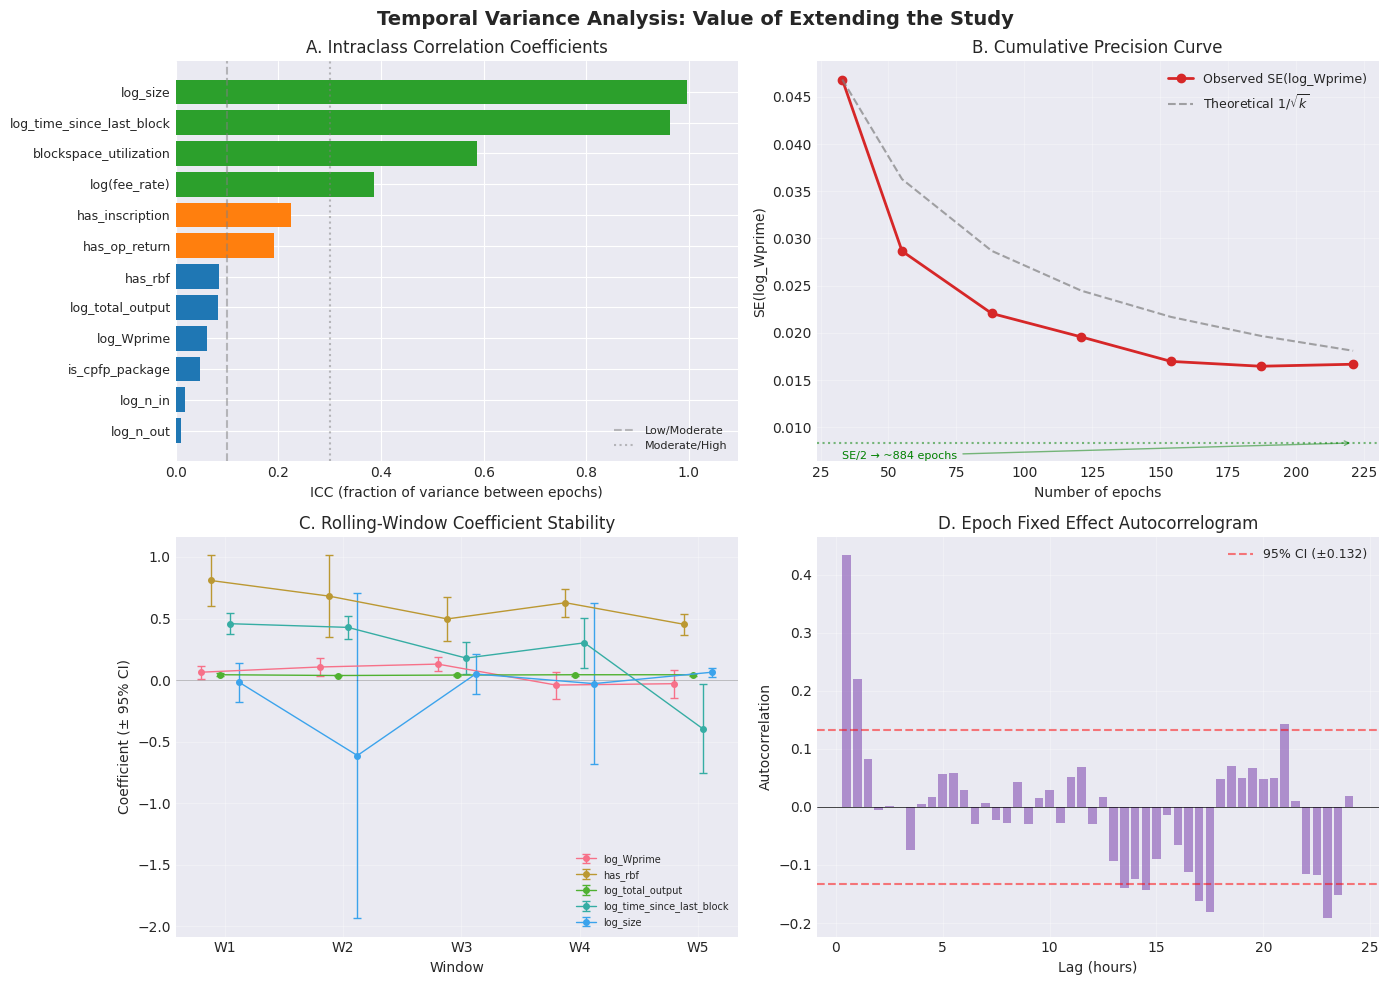


Figure saved to: plots/temporal_variance_analysis.png


In [ ]:
# =============================================================================
# Section 9.5: Summary Visualization — Temporal Variance Analysis
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Temporal Variance Analysis: Value of Extending the Study', fontsize=14, fontweight='bold')

# --- Panel A: ICC Bar Chart ---
ax = axes[0, 0]
icc_sorted = icc_df.sort_values('ICC', ascending=True)
colors = ['#2ca02c' if v > 0.3 else '#ff7f0e' if v > 0.1 else '#1f77b4'
          for v in icc_sorted['ICC']]
bars = ax.barh(range(len(icc_sorted)), icc_sorted['ICC'], color=colors)
ax.set_yticks(range(len(icc_sorted)))
ax.set_yticklabels(icc_sorted['variable'], fontsize=9)
ax.set_xlabel('ICC (fraction of variance between epochs)')
ax.set_title('A. Intraclass Correlation Coefficients')
ax.axvline(x=0.1, color='gray', linestyle='--', alpha=0.5, label='Low/Moderate')
ax.axvline(x=0.3, color='gray', linestyle=':', alpha=0.5, label='Moderate/High')
ax.legend(fontsize=8)
ax.set_xlim(0, max(icc_sorted['ICC'].max() * 1.1, 0.5))

# --- Panel B: Cumulative SE Curve ---
ax = axes[0, 1]
if cumulative_results:
    epochs_arr = np.array([r['n_epochs'] for r in cumulative_results])
    se_arr = np.array([r['se_wprime'] for r in cumulative_results])
    coef_arr = np.array([r['coef_wprime'] for r in cumulative_results])

    ax.plot(epochs_arr, se_arr, 'o-', color='#d62728', linewidth=2, markersize=6,
            label='Observed SE(log_Wprime)')

    # Theoretical 1/sqrt(k) decay, anchored at the first point
    theoretical = se_arr[0] * np.sqrt(epochs_arr[0]) / np.sqrt(epochs_arr)
    ax.plot(epochs_arr, theoretical, '--', color='gray', alpha=0.7,
            label=r'Theoretical $1/\sqrt{k}$')

    ax.set_xlabel('Number of epochs')
    ax.set_ylabel('SE(log_Wprime)')
    ax.set_title('B. Cumulative Precision Curve')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Extrapolate: how many epochs to halve the current SE?
    current_se = se_arr[-1]
    current_k = epochs_arr[-1]
    target_se = current_se / 2
    needed_k = int(current_k * (current_se / target_se) ** 2)
    ax.axhline(y=target_se, color='green', linestyle=':', alpha=0.5)
    ax.annotate(f'SE/2 → ~{needed_k} epochs',
                xy=(epochs_arr[-1], target_se),
                xytext=(epochs_arr[0], target_se * 0.8),
                fontsize=8, color='green',
                arrowprops=dict(arrowstyle='->', color='green', alpha=0.5))

# --- Panel C: Rolling-Window Stability ---
ax = axes[1, 0]
if window_results:
    key_features_plot = [f for f in ['log_Wprime', 'has_rbf', 'log_total_output',
                                     'log_time_since_last_block', 'log_size']
                         if all(f in wr.get('coef_summary', {}) for wr in window_results)]

    x_positions = np.arange(1, len(window_results) + 1)

    for i, feat in enumerate(key_features_plot):
        coefs = [wr['coef_summary'][feat]['coef'] for wr in window_results]
        ses = [wr['coef_summary'][feat]['se'] for wr in window_results]

        offset = (i - len(key_features_plot) / 2) * 0.08
        ax.errorbar(x_positions + offset, coefs,
                    yerr=[1.96 * s for s in ses],
                    fmt='o-', capsize=3, markersize=4, label=feat, linewidth=1)

    ax.set_xlabel('Window')
    ax.set_ylabel('Coefficient (± 95% CI)')
    ax.set_title('C. Rolling-Window Coefficient Stability')
    ax.set_xticks(x_positions)
    ax.set_xticklabels([f'W{i}' for i in x_positions])
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='black', linewidth=0.5, alpha=0.3)

# --- Panel D: Epoch FE Autocorrelation ---
ax = axes[1, 1]
if acf_values is not None:
    lags_to_plot = np.arange(1, len(acf_values))
    acf_to_plot = acf_values[1:]
    lag_hours = lags_to_plot * config.epoch_duration_minutes / 60

    ax.bar(lag_hours, acf_to_plot, width=config.epoch_duration_minutes / 60 * 0.8,
           color='#9467bd', alpha=0.7)

    # Bartlett 95% CI
    ci_95 = 1.96 / np.sqrt(len(fe_values))
    ax.axhline(y=ci_95, color='red', linestyle='--', alpha=0.5, label=f'95% CI (±{ci_95:.3f})')
    ax.axhline(y=-ci_95, color='red', linestyle='--', alpha=0.5)
    ax.axhline(y=0, color='black', linewidth=0.5)

    ax.set_xlabel('Lag (hours)')
    ax.set_ylabel('Autocorrelation')
    ax.set_title('D. Epoch Fixed Effect Autocorrelogram')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/temporal_variance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nFigure saved to: plots/temporal_variance_analysis.png")

In [ ]:
# =============================================================================
# Section 9.6: Summary and Recommendation
# =============================================================================

print("=" * 70)
print("TEMPORAL VARIANCE ANALYSIS — SUMMARY")
print("=" * 70)

# Assess each dimension
icc_assessment = "high" if icc_wprime > 0.3 else ("moderate" if icc_wprime > 0.1 else "low")
deff_assessment = "large" if DEFF > 10 else ("moderate" if DEFF > 3 else "small")

# Coefficient stability assessment
if window_results:
    key_feat = 'log_Wprime'
    if all(key_feat in wr.get('coef_summary', {}) for wr in window_results):
        wprime_coefs = [wr['coef_summary'][key_feat]['coef'] for wr in window_results]
        wprime_ses = [wr['coef_summary'][key_feat]['se'] for wr in window_results]
        coef_range = max(wprime_coefs) - min(wprime_coefs)
        avg_se = np.mean(wprime_ses)
        stability_ratio = coef_range / avg_se if avg_se > 0 else float('inf')
        stability_assessment = "stable" if stability_ratio < 2.0 else \
                               ("borderline" if stability_ratio < 3.0 else "unstable")
    else:
        stability_assessment = "unknown"
        stability_ratio = None
else:
    stability_assessment = "unknown"
    stability_ratio = None

# ACF decay assessment
if acf_values is not None:
    acf_at_12 = acf_values[12] if len(acf_values) > 12 else 0
    acf_at_24 = acf_values[24] if len(acf_values) > 24 else 0
    persistence = "high" if acf_at_12 > 0.3 else ("moderate" if acf_at_12 > 0.1 else "low")
else:
    persistence = "unknown"

print(f"""
  1. ICC(log_Wprime) = {icc_wprime:.4f} → {icc_assessment}
     Between-epoch variation as share of identifying variable.

  2. Design Effect = {DEFF:.1f} → {deff_assessment}
     Effective N = {N_eff:,.0f} out of {n_obs:,} observations.

  3. Coefficient stability across windows → {stability_assessment}
     {"Range/SE ratio: " + f"{stability_ratio:.2f}" if stability_ratio else "Could not assess"}

  4. Epoch FE persistence → {persistence}
     {"ACF at 12 epochs (6h): " + f"{acf_at_12:.4f}" if acf_values is not None else "N/A"}
""")

# Final recommendation
if stability_assessment == "unstable":
    print("  RECOMMENDATION: More time may HURT")
    print("  Structural parameters appear to drift across the study period.")
    print("  Either keep the study window short, or model time-varying parameters")
    print("  (e.g., interact coefficients with a time trend or regime indicator).")
elif icc_assessment == "high" and deff_assessment == "large":
    print("  RECOMMENDATION: More time helps SUBSTANTIALLY")
    print("  The identifying variation is mostly between-epoch, and the design effect")
    print("  is large. Extending the study to cover more diverse market conditions")
    print("  would meaningfully tighten inference.")
elif icc_assessment in ("moderate", "high") or deff_assessment in ("moderate", "large"):
    print("  RECOMMENDATION: More time helps MODESTLY")
    print("  Within-epoch variation already provides some identification, but more")
    print("  epochs would still tighten clustered standard errors.")
else:
    print("  RECOMMENDATION: More time has LIMITED benefit")
    print("  Within-epoch variation already drives identification. Additional calendar")
    print("  time adds little new information for the structural estimates.")

if persistence == "high" and stability_assessment != "unstable":
    print(f"\n  SAMPLING DESIGN: Strong autocorrelation in epoch FE suggests that")
    print(f"  spaced-out data collection (e.g., 1 week per month over 6 months)")
    print(f"  would be more efficient than continuous scraping.")

TEMPORAL VARIANCE ANALYSIS — SUMMARY

  1. ICC(log_Wprime) = 0.0617 → low
     Between-epoch variation as share of identifying variable.

  2. Design Effect = 334.3 → large
     Effective N = 571 out of 190,902 observations.

  3. Coefficient stability across windows → unstable
     Range/SE ratio: 4.04

  4. Epoch FE persistence → low
     ACF at 12 epochs (6h): 0.0287

  RECOMMENDATION: More time may HURT
  Structural parameters appear to drift across the study period.
  Either keep the study window short, or model time-varying parameters
  (e.g., interact coefficients with a time trend or regime indicator).


---
## Summary

This notebook implements the complete two-stage fee estimation pipeline:

### Stage 1: Delay Technology Estimation
- **Model**: Random Forest with epoch-level cross-fitting
- **Output**: Predicted delay W(p, s) and local slope W'(p, s)
- **Key Feature**: Monotonicity enforcement via IsotonicRegression

### Stage 2: Hurdle Fee Model  
- **Extensive Margin** h(ι): Logistic regression for P(fee > ε) with monotonicity constraints
- **Intensive Margin** s(ι): OLS for E[log(fee) | fee > ε] with monotonicity constraints
- **Key Feature**: I-spline basis (Ramsay 1988) with nonneg coefficients δ_ℓ ≥ 0 → weakly increasing h(·) and s(·)

### Key Results
- Priority enters only through the delay gradient (VCG-consistent)
- Clustered standard errors account for within-epoch correlation
- Smearing correction for level predictions

### Usage
```python
# Full pipeline
estimator = BitcoinFeeEstimator(config)
estimator.fit(df)
predictions = estimator.predict()

# Save model
estimator.save('model.pkl')

# Load model
estimator = BitcoinFeeEstimator.load('model.pkl')
```